In [3]:
# import the data
import pandas as pd

#iMentor Data Complete Represents this: 
path = '/Users/_Preston_/Documents/MSBA/MIS-690-CAPSTONE/Student Mentor Proejct/iMentor_Data_Complete.csv'

# place the data in a Pandas DataFrame
df = pd.read_csv(path)

# look at the first five rows of data
df.head()

,user_id,cohort,Member,school,gender,race/ethnicity,LOM (control matches),matched_sixmonths,# of Mentors,online_pair_completion_sr_yr,...,Mentor User ID,Mentor_Comm_Yes,Mentor_Comm_No,Meet_Yes,Meet_No,Text,Email,Phone,None,Unknown
0,123456,2019.0,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1244.0,1.0,1.0,57.0,...,353712.0,6.0,3.0,0.0,9.0,6.0,0.0,0.0,3.0,0.0
1,123457,2019.0,iMentor NYC,Rushmore Academy,Female,Hispanic (May be of any race),1500.0,1.0,2.0,68.0,...,326298.0,6.0,0.0,6.0,0.0,3.0,0.0,3.0,0.0,0.0
2,123458,2019.0,iMentor NYC,Rushmore Academy,Male,Black / African American,1529.0,1.0,2.0,84.0,...,315563.0,4.0,1.0,0.0,5.0,4.0,0.0,0.0,1.0,0.0
3,123459,2019.0,iMentor NYC,Rushmore Academy,Male,Hispanic (May be of any race),1552.0,1.0,3.0,92.0,...,351993.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0
4,123460,2019.0,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1580.0,1.0,2.0,95.0,...,344348.0,3.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0


In [4]:
# let's look at the dimensions of the dataset.
df.shape

(2320, 43)

In [5]:
# looking at all the unique values in each column of the dataset.
uniques_df = pd.DataFrame(df.nunique(), columns=['Unique Values'])
uniques_df

,Unique Values
user_id,2320
cohort,4
Member,3
school,23
gender,2
race/ethnicity,8
LOM (control matches),759
matched_sixmonths,2
# of Mentors,4
online_pair_completion_sr_yr,95


Looking at the Data Types to Ensure they are correct

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2320 entries, 0 to 2319
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       2320 non-null   int64  
 1   cohort                        2296 non-null   float64
 2   Member                        2296 non-null   object 
 3   school                        2296 non-null   object 
 4   gender                        2296 non-null   object 
 5   race/ethnicity                2296 non-null   object 
 6   LOM (control matches)         2296 non-null   float64
 7   matched_sixmonths             2296 non-null   float64
 8   # of Mentors                  2296 non-null   float64
 9   online_pair_completion_sr_yr  2296 non-null   float64
 10  pair_mtgs_sr_yr               2296 non-null   float64
 11  sem1_enr                      2296 non-null   float64
 12  SEL.GM_1                      2296 non-null   float64
 13  SEL

Data type issues with: cohort (year, object) & Pair ID (object, string)

In [7]:
df['cohort'] = df['cohort'].astype(str)
df['cohort'] = df['cohort'].astype('object')
df['cohort'].dtype

dtype('O')

In [8]:
def unistats(df, 
             sort_by=None, 
             ascending=True, 
             transpose=False, 
             metrics=None):

    import pandas as pd

    output_df = pd.DataFrame(columns=['Count', 'Unique', 'Missing_%', 'Type', 'Min', 'Max', '25%', '50%', '75%', 'Mean', 'Median', 'Mode', 'Std', 'Skew', 'Kurt'])

    for col in df.columns:
        # Basic stats applicable to all columns
        count = df[col].count()
        unique = df[col].nunique()
        percentage = round((1 - (count / len(df))) * 100, 2)
        dtype = df[col].dtype  # Keep this as dtype, not str

        # Numeric columns (excluding booleans)
        if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
            min_val = round(df[col].min(), 2)
            max_val = round(df[col].max(), 2)
            quar_1 = round(df[col].quantile(0.25), 2)
            quar_2 = round(df[col].quantile(0.50), 2)
            quar_3 = round(df[col].quantile(0.75), 2)
            mean = round(df[col].mean(), 2)
            median = round(df[col].median(), 2)
            mode = round(df[col].mode().values[0], 2) if not df[col].mode().empty else 'NA'
            std = round(df[col].std(), 2)
            skew = round(df[col].skew(), 2)
            kurt = round(df[col].kurt(), 2)

            output_df.loc[col] = (count, unique, percentage, dtype, min_val, max_val, quar_1, quar_2, quar_3, mean, median, mode, std, skew, kurt)

        # Boolean columns
        elif pd.api.types.is_bool_dtype(df[col]):
            mean = round(df[col].mean(), 2)  # Proportion of True values
            median = round(df[col].median(), 2)
            mode = df[col].mode().values[0] if not df[col].mode().empty else 'NA'
            
            output_df.loc[col] = (count, unique, percentage, dtype, 'NA', 'NA', 'NA', 'NA', 'NA', mean, median, mode, 'NA', 'NA', 'NA')

        # Non-numeric columns (e.g., categorical, strings)
        else:
            output_df.loc[col] = (count, unique, percentage, dtype, 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA')

    # Filter by metrics if provided
    if metrics:
        output_df = output_df.loc[output_df.index.isin(metrics)]

    # Sort by the specified column if applicable
    if sort_by and sort_by in output_df.columns:
        output_df = output_df.sort_values(by=sort_by, ascending=ascending)

    # Transpose if requested
    if transpose:
        output_df = output_df.transpose()

    return output_df


In [9]:
df2 = df.copy()
df2 = unistats(df2, ascending = True)
df2

,Count,Unique,Missing_%,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
user_id,2320,2320,0.00,int64,123456,126738,124159.5,125033.5,125767.25,125009.68,125033.5,123456,939.65,-0.02,-1.19
cohort,2320,5,0.00,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Member,2296,3,1.03,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
school,2296,23,1.03,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
gender,2296,2,1.03,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
race/ethnicity,2296,8,1.03,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
LOM (control matches),2296,759,1.03,float64,14.0,2310.0,726.0,782.0,1416.0,983.57,782.0,782.0,392.32,0.06,-1.2
matched_sixmonths,2296,2,1.03,float64,0.0,1.0,1.0,1.0,1.0,0.99,1.0,1.0,0.1,-9.63,90.88
# of Mentors,2296,4,1.03,float64,1.0,4.0,1.0,1.0,1.0,1.28,1.0,1.0,0.55,1.98,3.81
online_pair_completion_sr_yr,2296,95,1.03,float64,0.0,100.0,27.0,59.0,81.0,52.94,59.0,0.0,32.51,-0.39,-1.14


In [10]:
def univariate_charts(df, box=True, hist=True, save=False, save_path='', stats=True):
  import pandas as pd
  import seaborn as sns
  import matplotlib.pyplot as plt

  sns.set(style="ticks")

  for col in df.columns:
    plt.figure(figsize=(8, 5))

    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
      if box and hist:
        fig, (ax_box, ax_hist) = plt.subplots(
            2, sharex=True, gridspec_kw={"height_ratios": (0.2, 0.8)}, figsize=(8, 5)
        )
        sns.boxplot(x=df[col], ax=ax_box, fliersize=4, width=0.5, linewidth=1)
        sns.histplot(df[col], kde=True, ax=ax_hist)
        ax_box.set(yticks=[], xlabel='')
        sns.despine(ax=ax_box, left=True)
        sns.despine(ax=ax_hist)
      elif box:
        sns.boxplot(x=df[col], fliersize=4, width=0.5, linewidth=1)
        sns.despine()
      elif hist:
        sns.histplot(df[col], kde=True, rug=True)
        sns.despine()

      if stats:
        stats_text = (
          f"Unique: {df[col].nunique()}\n"
          f"Missing: {df[col].isnull().sum()}\n"
          f"Mode: {df[col].mode().iloc[0]}\n"
          f"Min: {df[col].min():.2f}\n"
          f"25%: {df[col].quantile(0.25):.2f}\n"
          f"Median: {df[col].median():.2f}\n"
          f"75%: {df[col].quantile(0.75):.2f}\n"
          f"Max: {df[col].max():.2f}\n"
          f"Std dev: {df[col].std():.2f}\n"
          f"Mean: {df[col].mean():.2f}\n"
          f"Skew: {df[col].skew():.2f}\n"
          f"Kurt: {df[col].kurt():.2f}"
        )
        plt.gcf().text(0.95, 0.5, stats_text, fontsize=10, va='center', transform=plt.gcf().transFigure)
    elif pd.api.types.is_bool_dtype(df[col]):
      sns.histplot(x=df[col], data = df, bins=2, binwidth=0.5, element='bars')
      if stats:
        stats_text = (
          f"Mean: {df[col].mean():.2f}\n"
          f"Missing: {df[col].isnull().sum()}\n"
          f"Mode: {df[col].mode().iloc[0]}"
        )
        plt.gcf().text(0.95, 0.5, stats_text, fontsize=10, va='center', transform=plt.gcf().transFigure)
    else:
      sns.countplot(x=col, data=df, order=df[col].value_counts().index, hue=col, dodge=False, legend=False, palette="RdBu_r", stat='count')
      sns.despine()
      if stats:
        stats_text = (
          f"Unique: {df[col].nunique()}\n"
          f"Missing: {df[col].isnull().sum()}\n"
          f"Mode: {df[col].mode().iloc[0]}"
        )
        plt.gcf().text(0.95, 0.5, stats_text, fontsize=10, va='center', transform=plt.gcf().transFigure)

    plt.title(col, fontsize=14)
    if save:
      plt.savefig(f"{save_path}{col}.png", dpi=100, bbox_inches='tight')
    plt.show()

<Figure size 800x500 with 0 Axes>

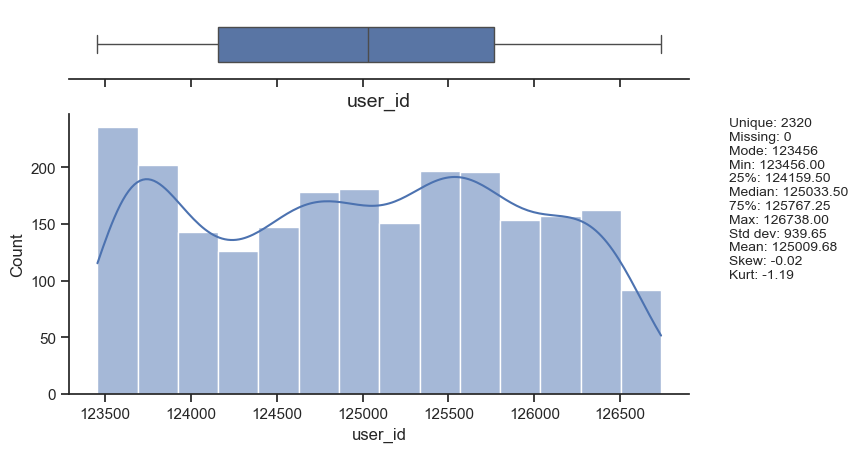

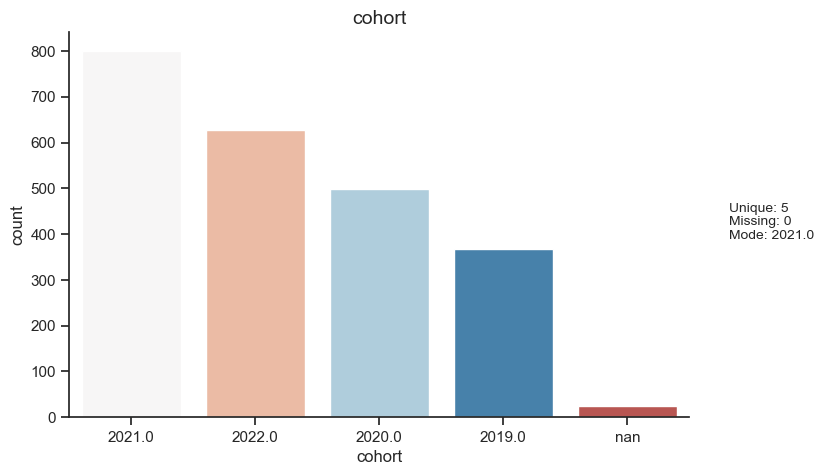

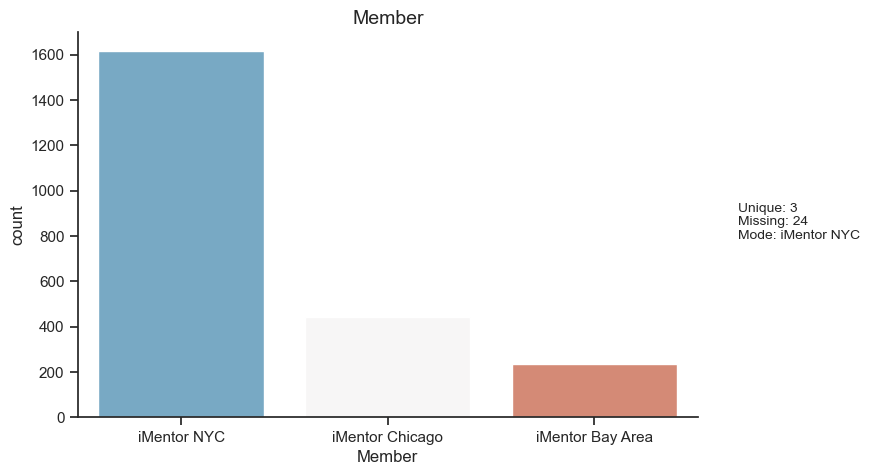

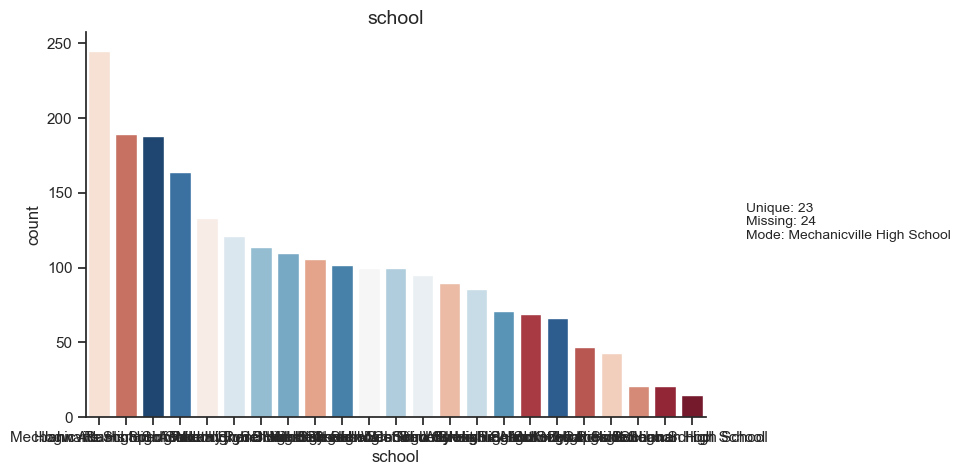

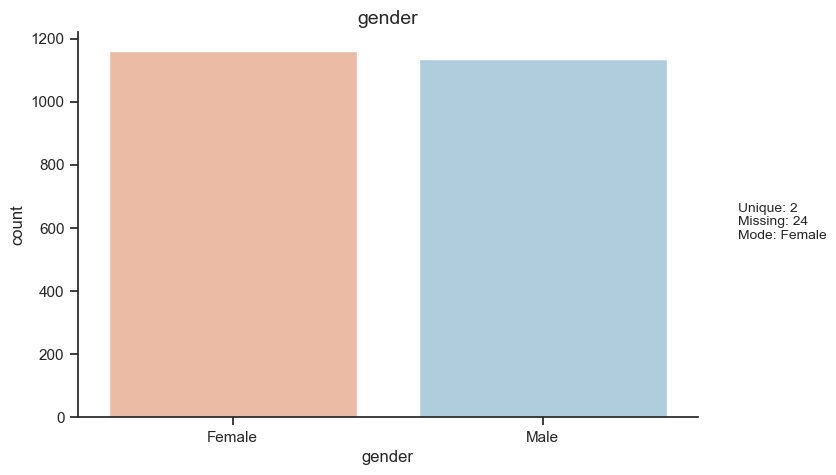

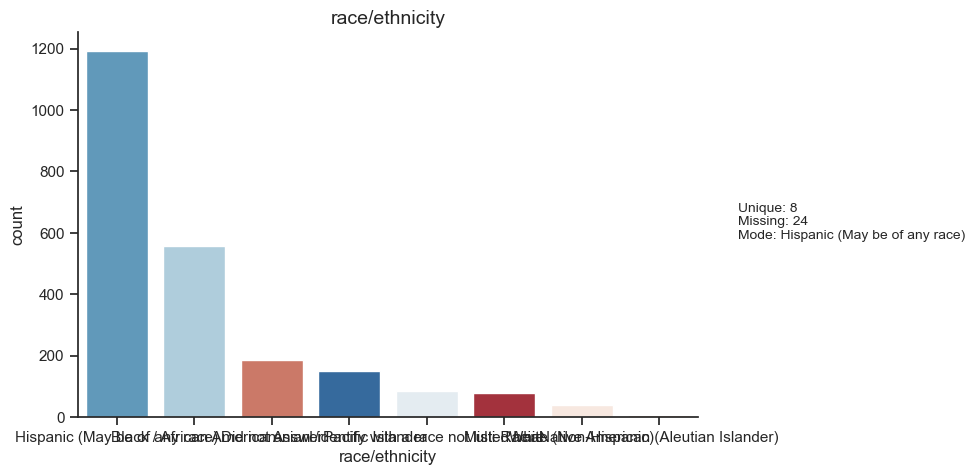

<Figure size 800x500 with 0 Axes>

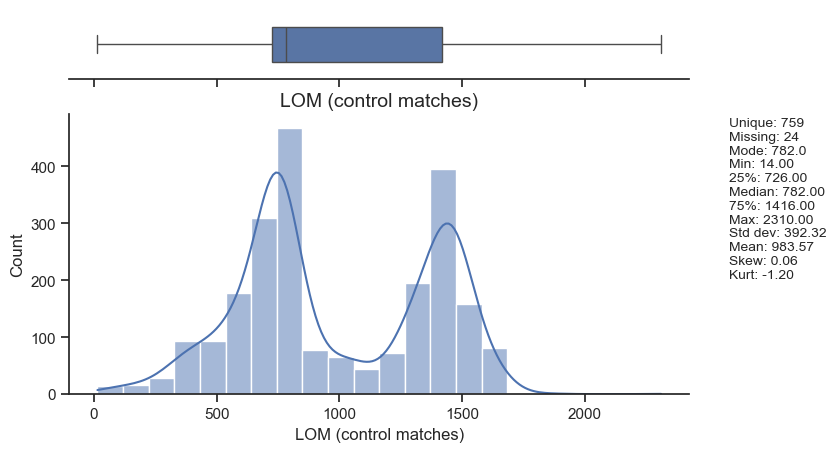

<Figure size 800x500 with 0 Axes>

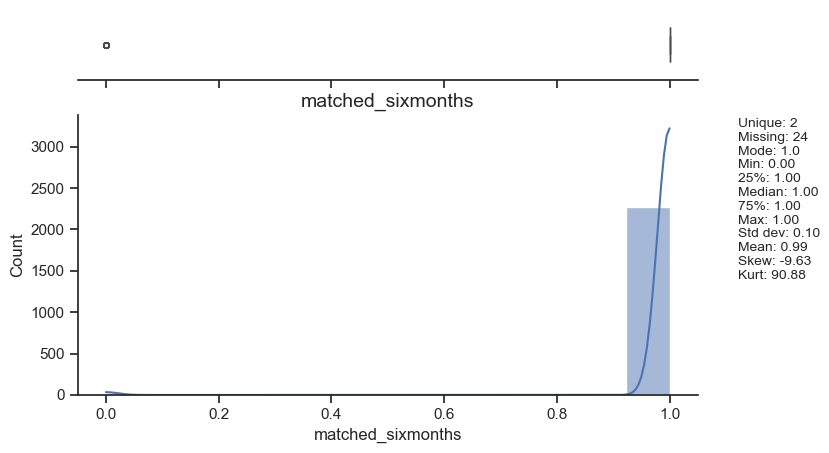

<Figure size 800x500 with 0 Axes>

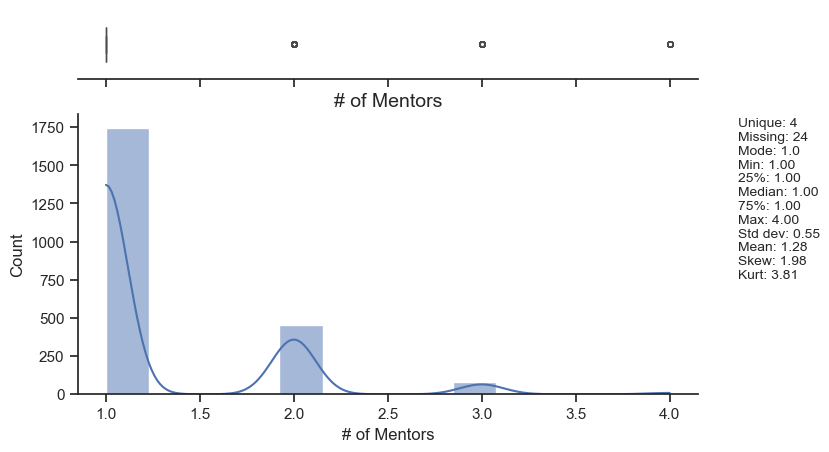

<Figure size 800x500 with 0 Axes>

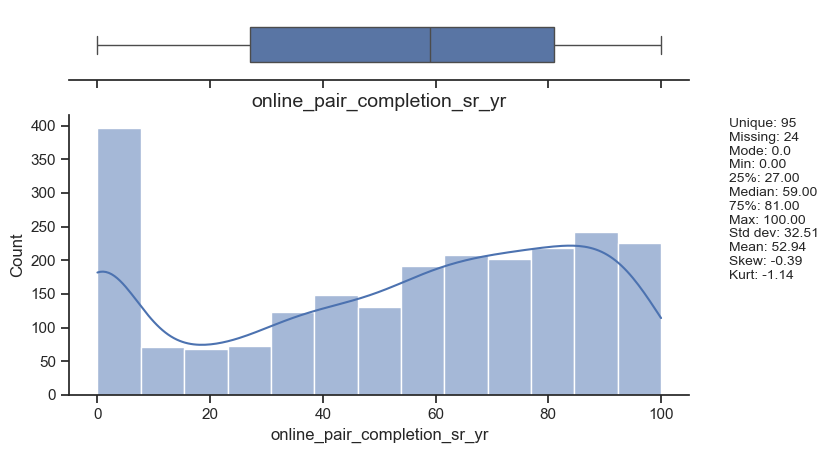

<Figure size 800x500 with 0 Axes>

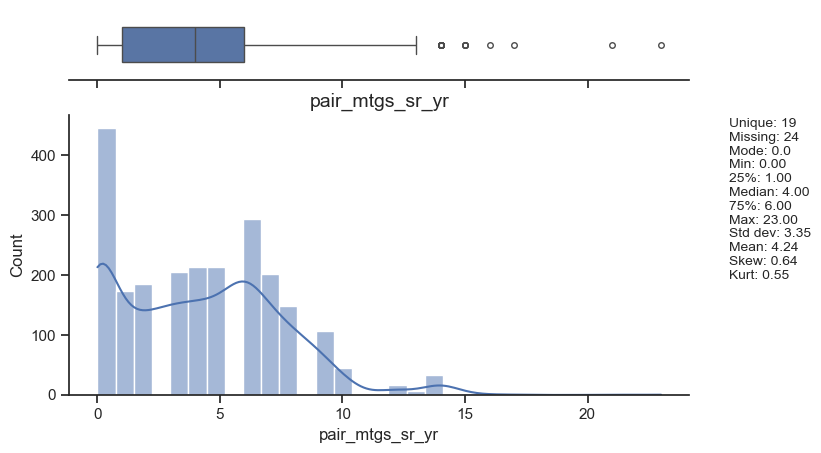

<Figure size 800x500 with 0 Axes>

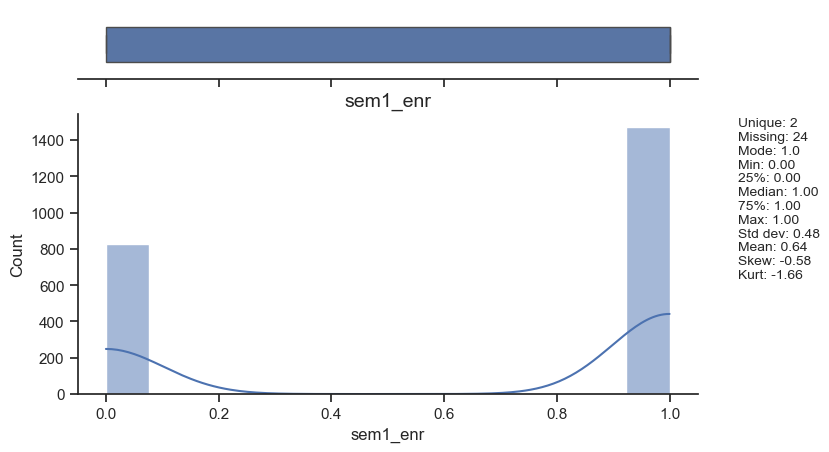

<Figure size 800x500 with 0 Axes>

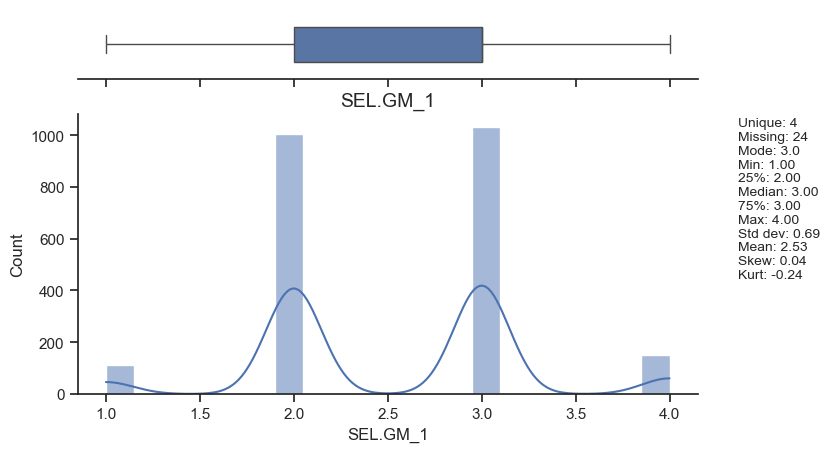

<Figure size 800x500 with 0 Axes>

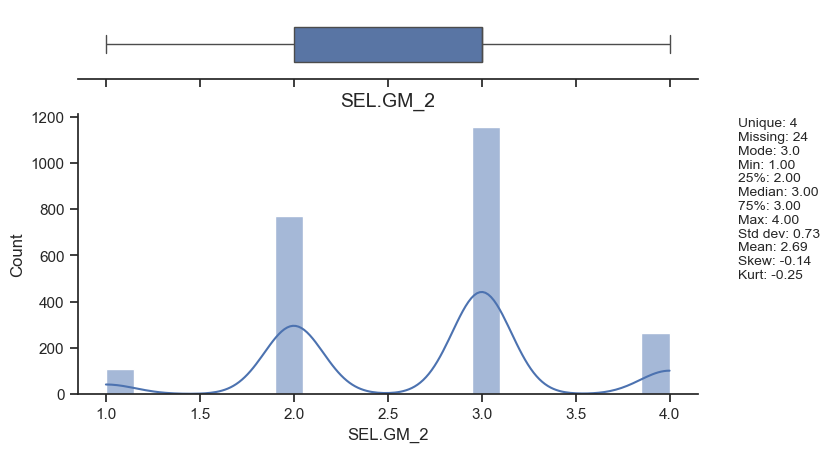

<Figure size 800x500 with 0 Axes>

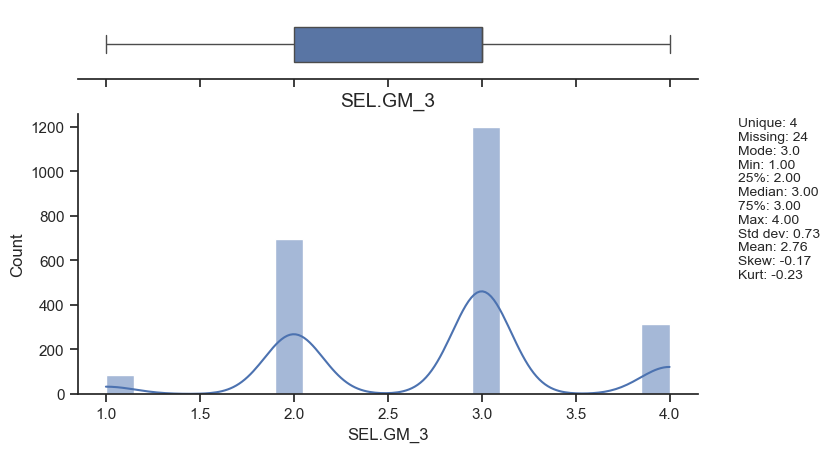

<Figure size 800x500 with 0 Axes>

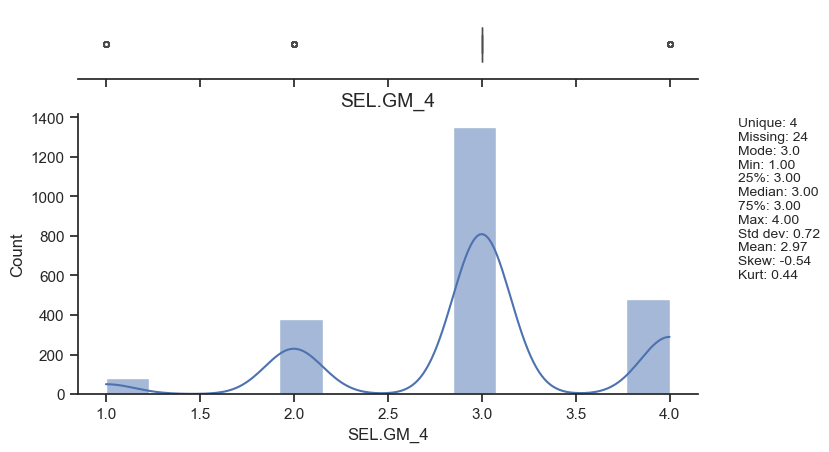

<Figure size 800x500 with 0 Axes>

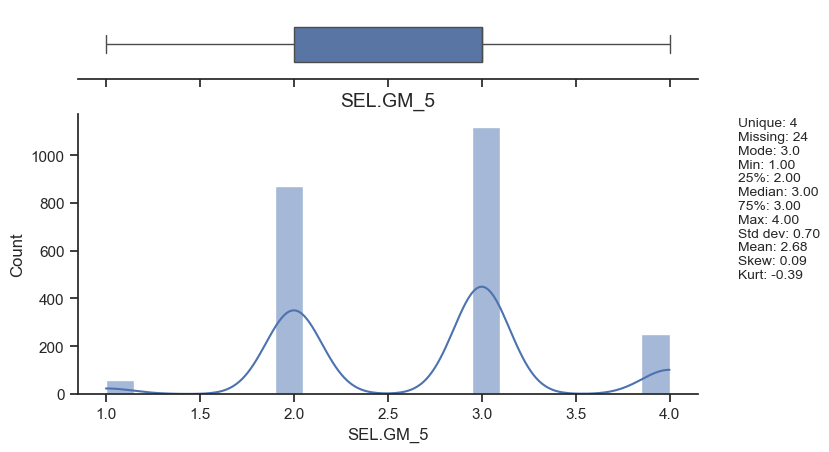

<Figure size 800x500 with 0 Axes>

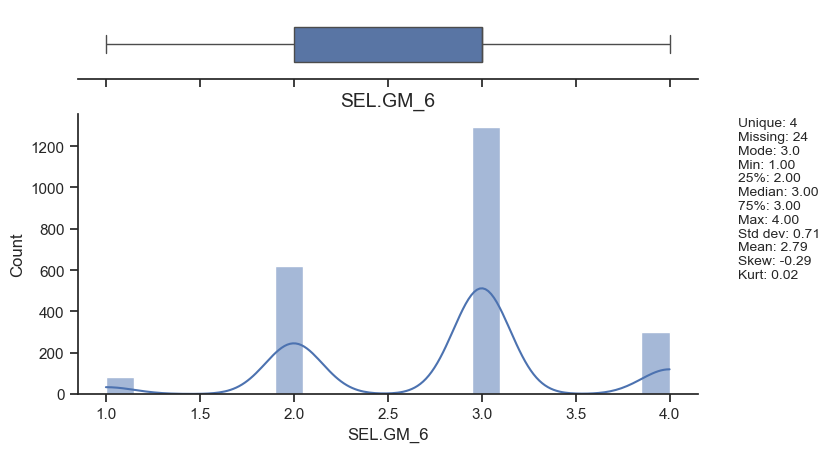

<Figure size 800x500 with 0 Axes>

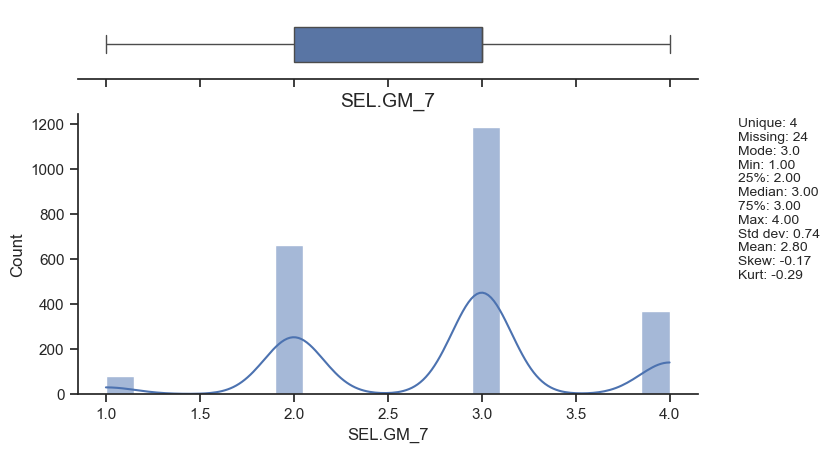

<Figure size 800x500 with 0 Axes>

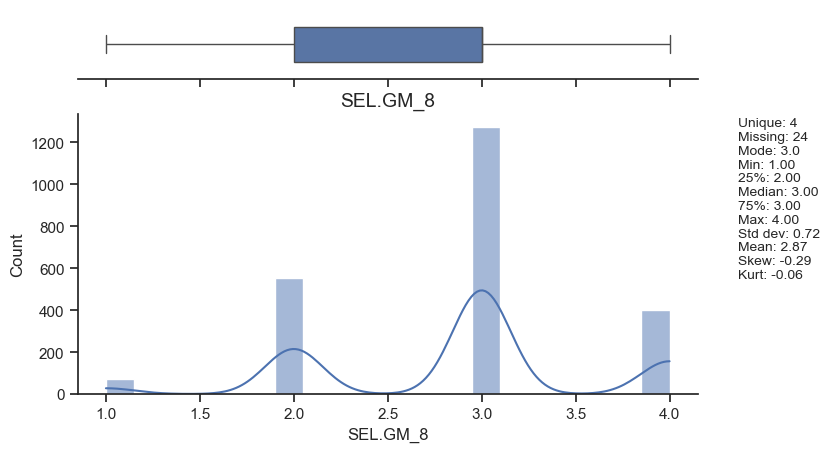

<Figure size 800x500 with 0 Axes>

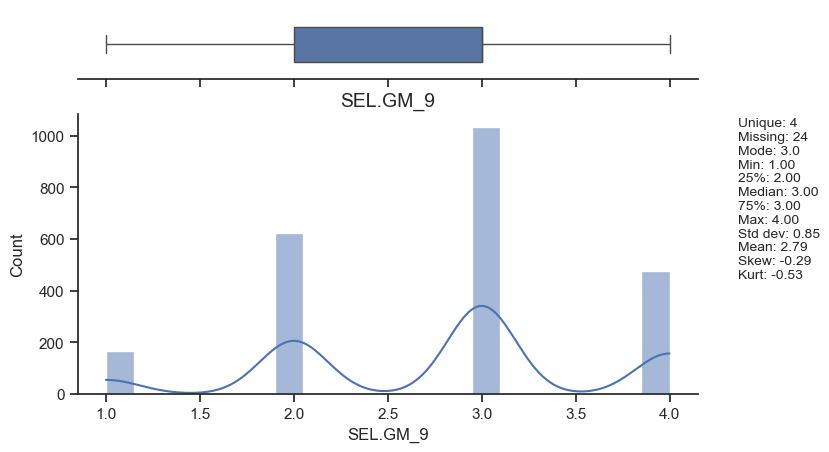

<Figure size 800x500 with 0 Axes>

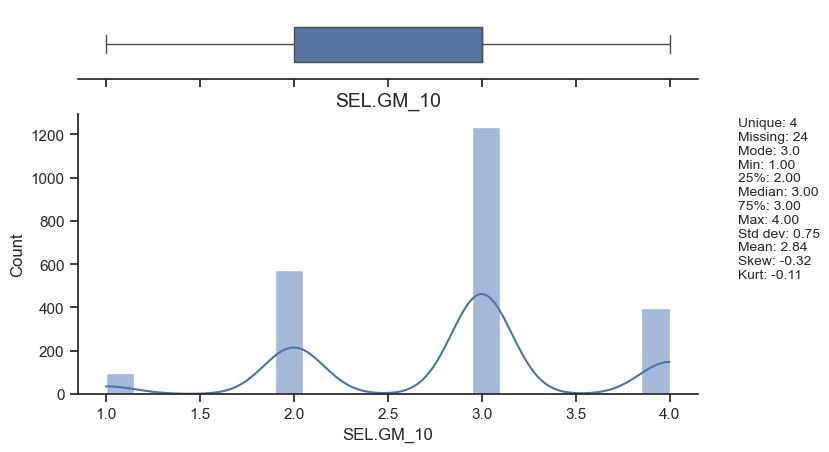

<Figure size 800x500 with 0 Axes>

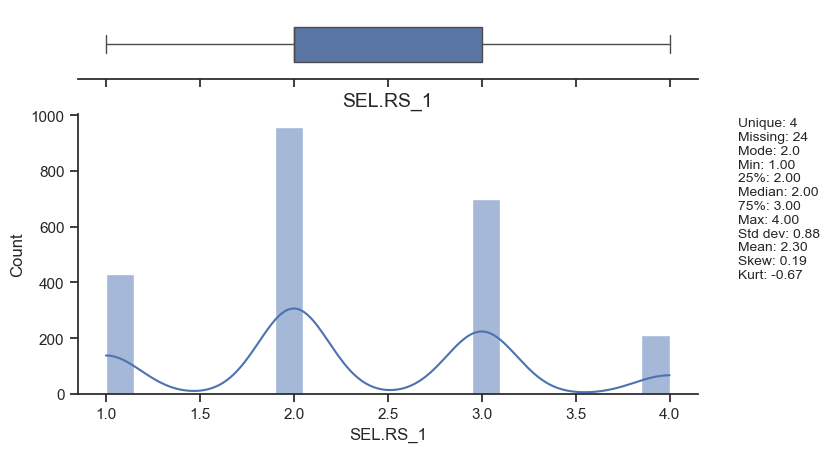

<Figure size 800x500 with 0 Axes>

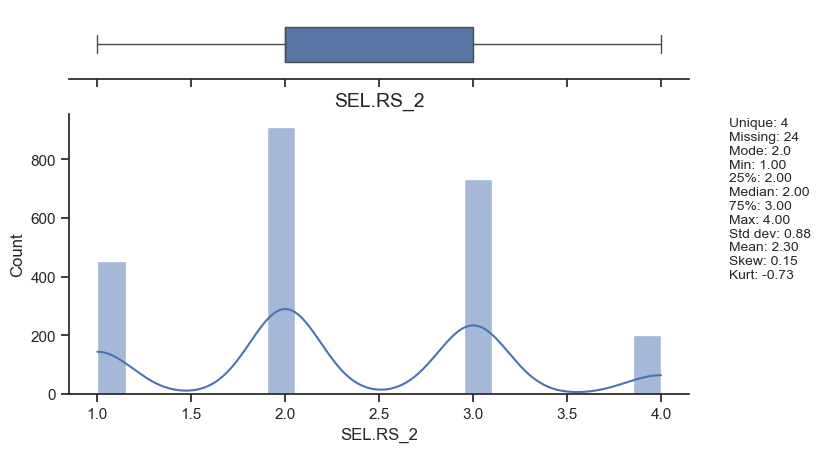

<Figure size 800x500 with 0 Axes>

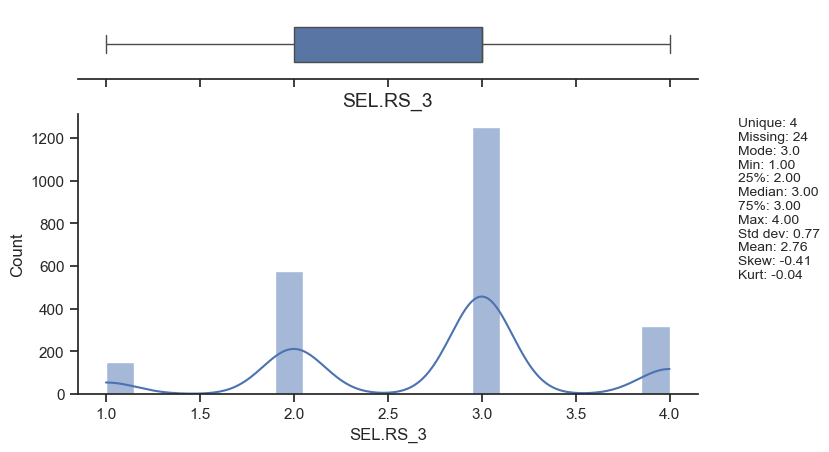

<Figure size 800x500 with 0 Axes>

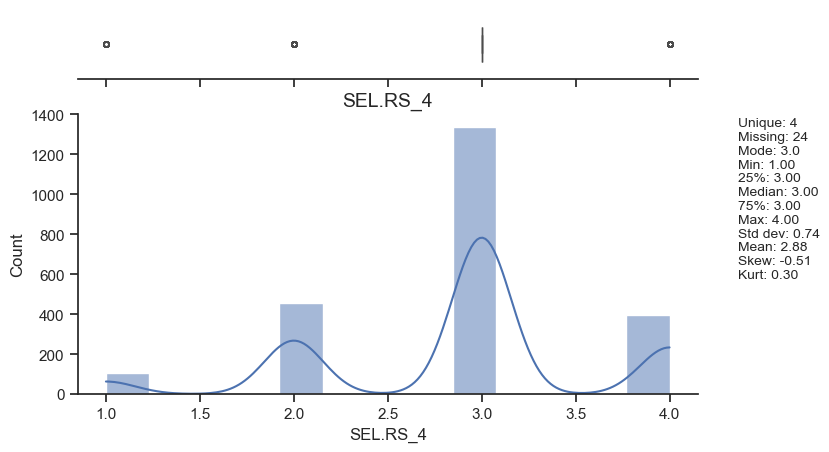

<Figure size 800x500 with 0 Axes>

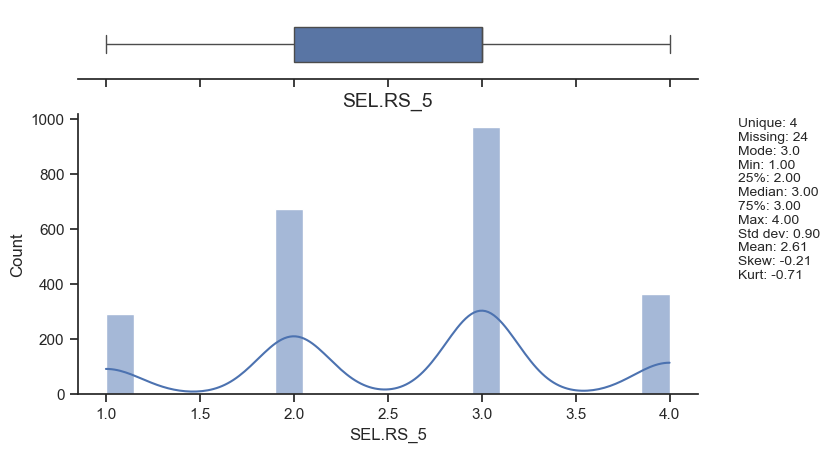

<Figure size 800x500 with 0 Axes>

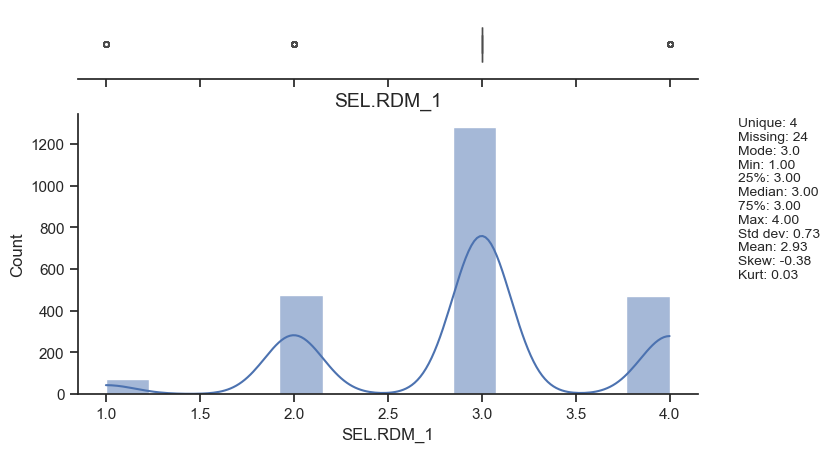

<Figure size 800x500 with 0 Axes>

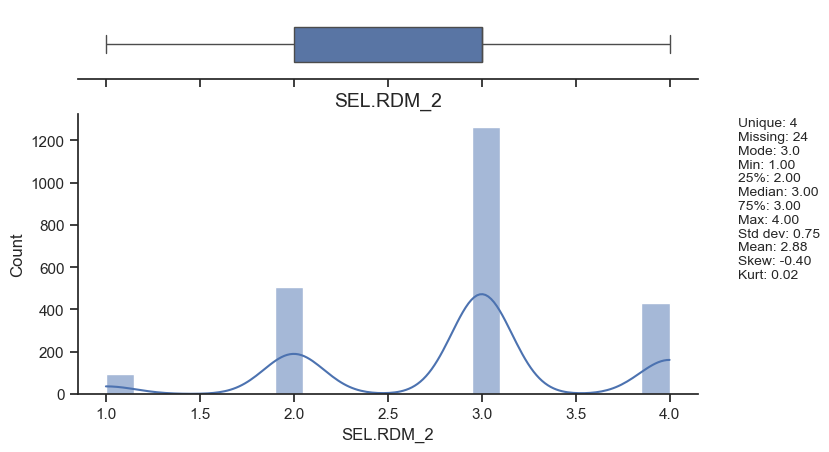

<Figure size 800x500 with 0 Axes>

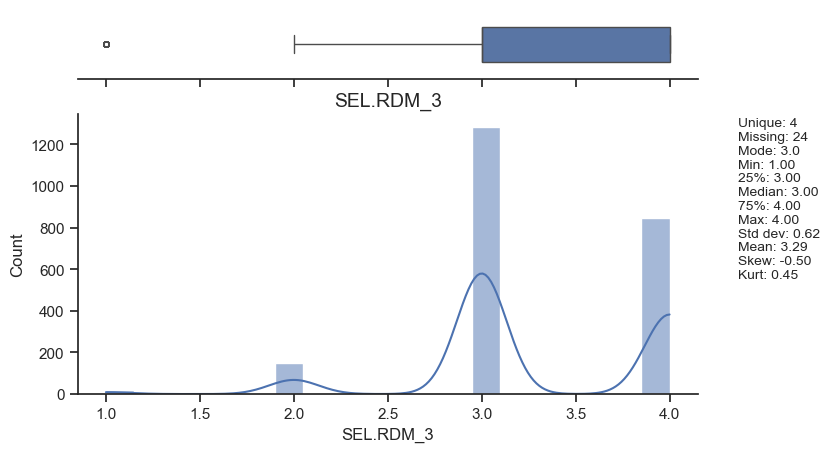

<Figure size 800x500 with 0 Axes>

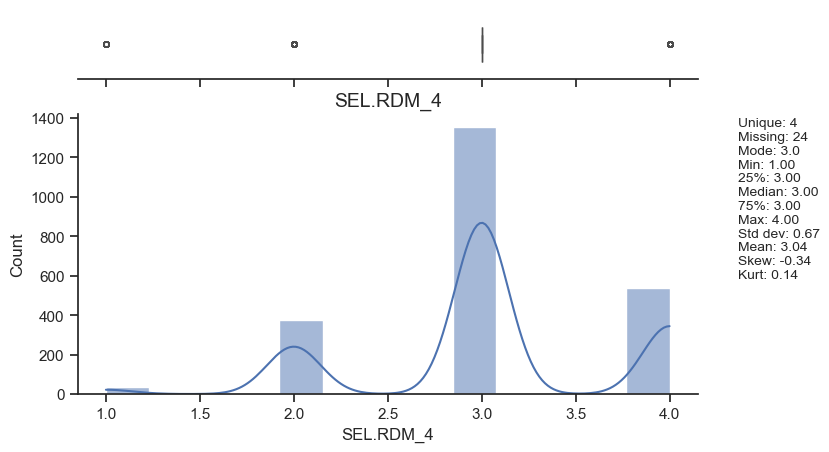

<Figure size 800x500 with 0 Axes>

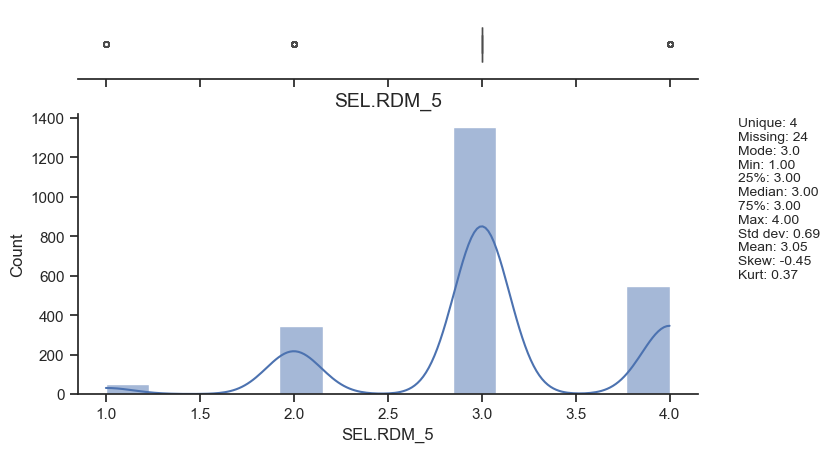

<Figure size 800x500 with 0 Axes>

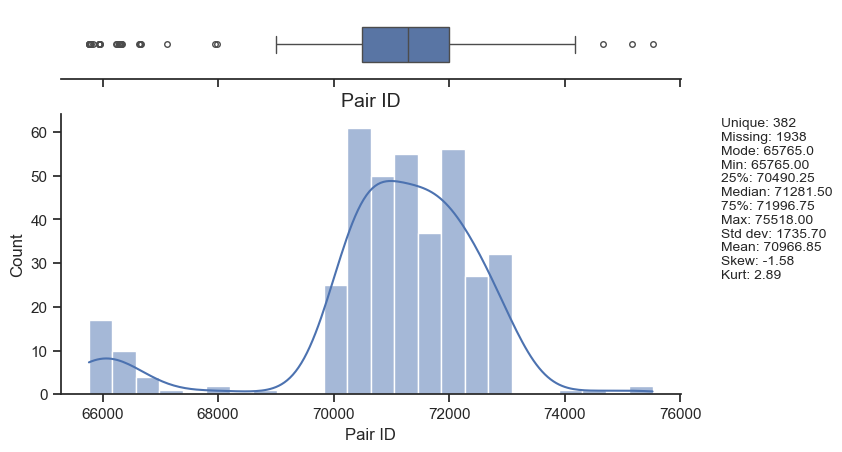

<Figure size 800x500 with 0 Axes>

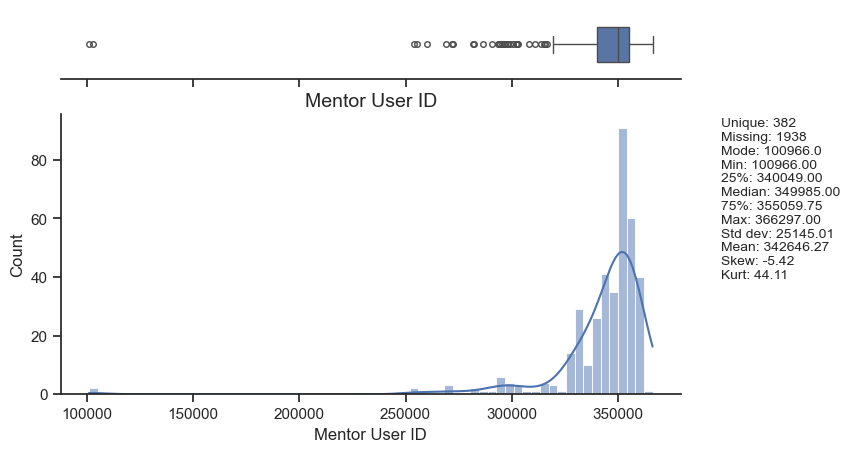

<Figure size 800x500 with 0 Axes>

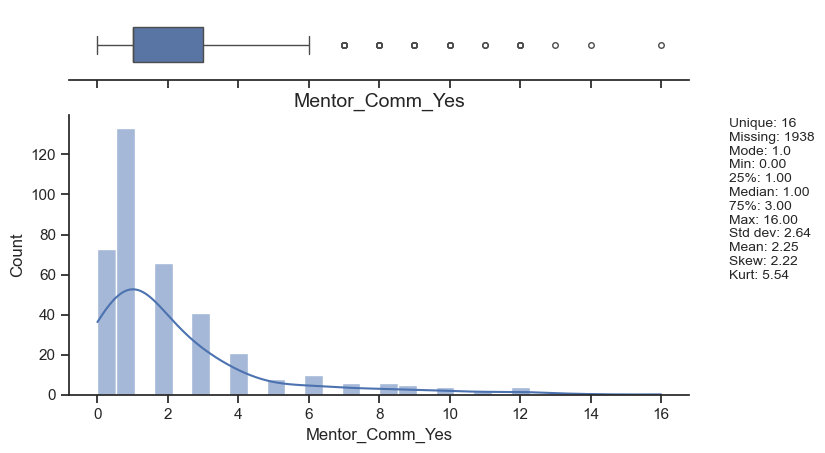

<Figure size 800x500 with 0 Axes>

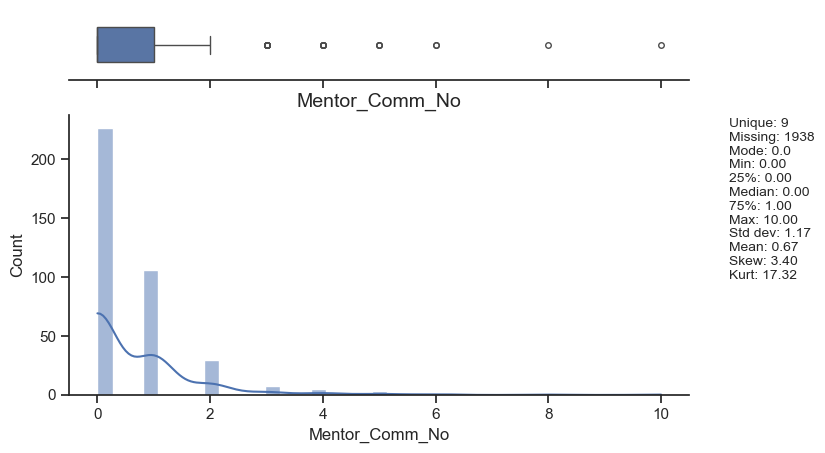

<Figure size 800x500 with 0 Axes>

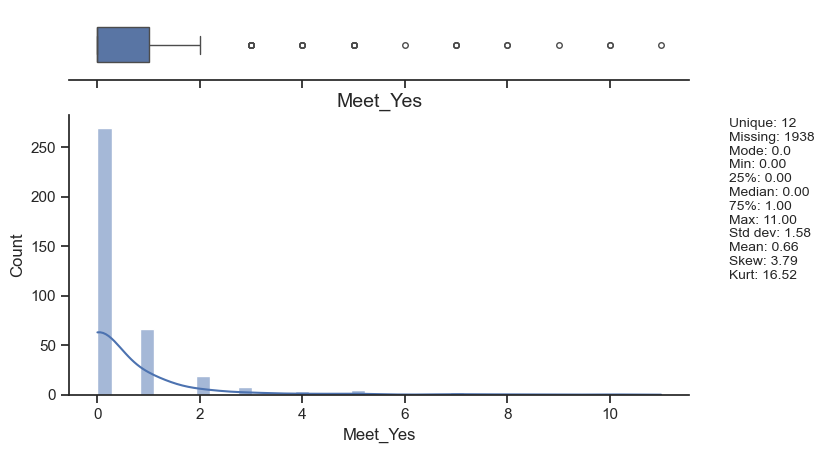

<Figure size 800x500 with 0 Axes>

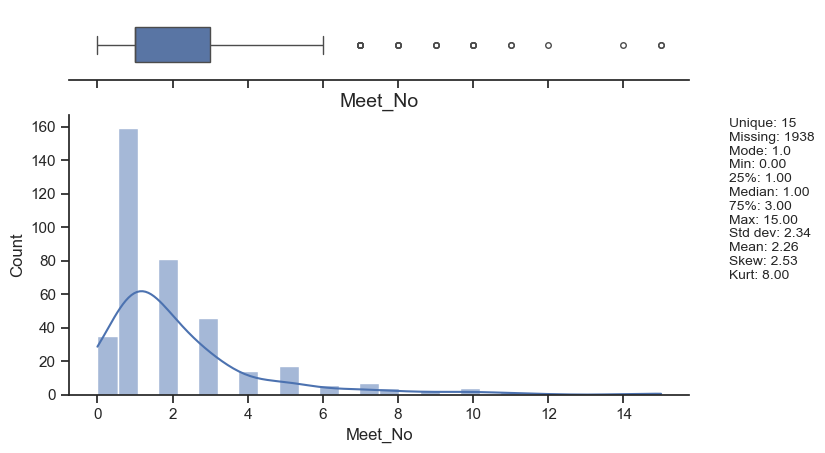

<Figure size 800x500 with 0 Axes>

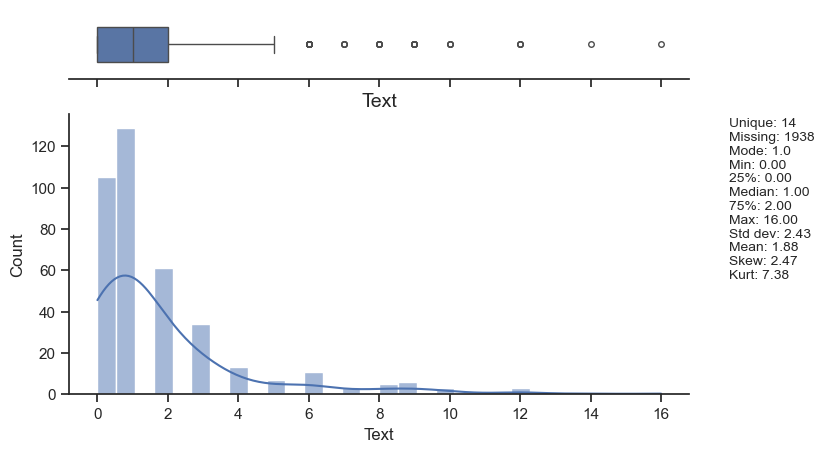

<Figure size 800x500 with 0 Axes>

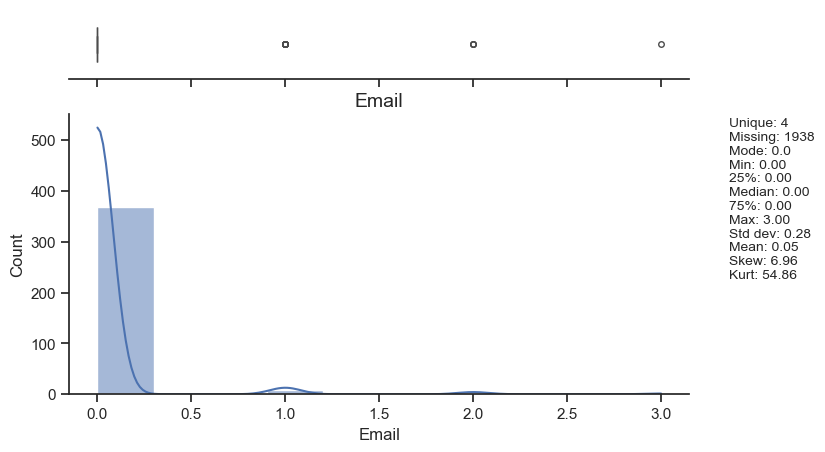

<Figure size 800x500 with 0 Axes>

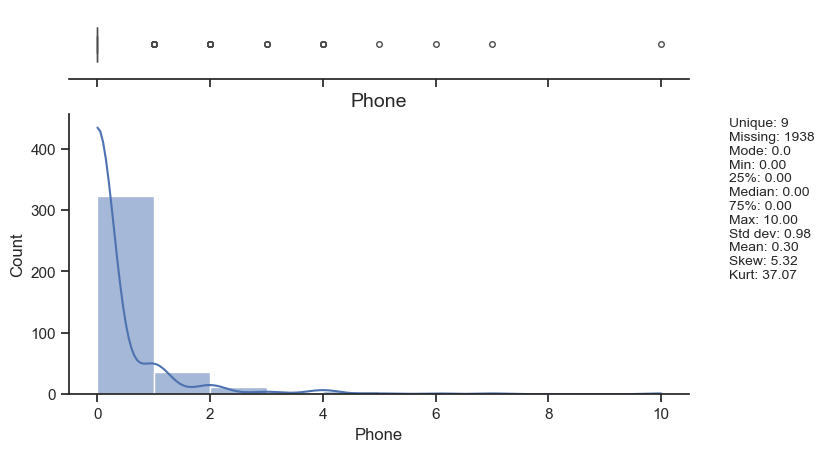

<Figure size 800x500 with 0 Axes>

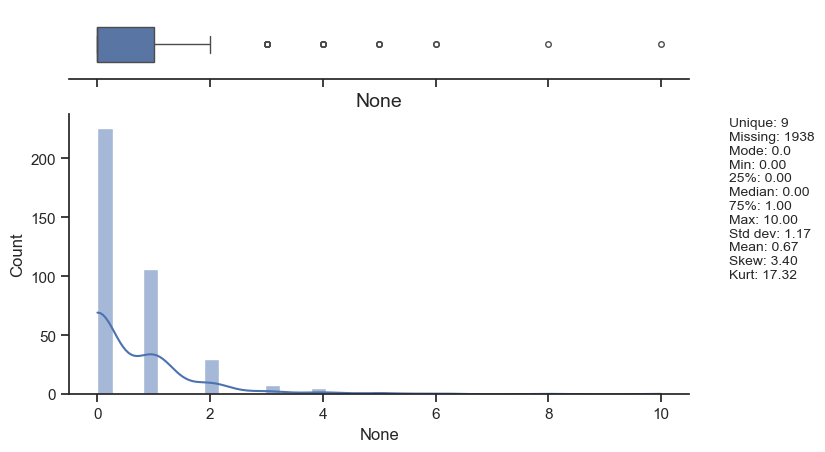

<Figure size 800x500 with 0 Axes>

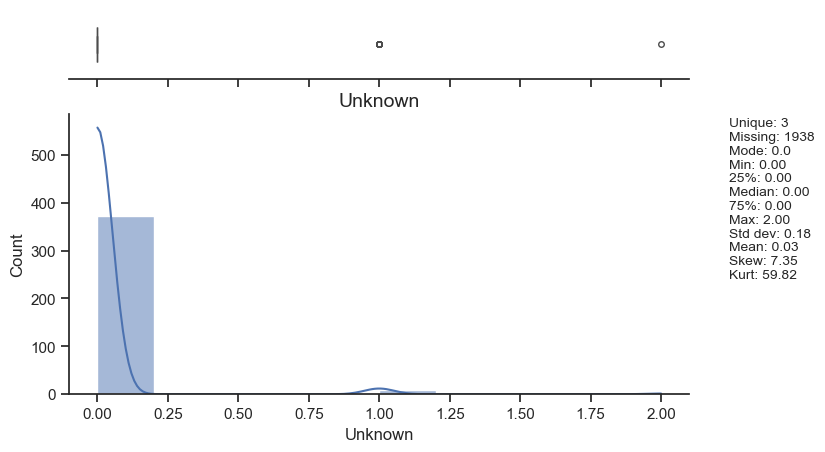

In [11]:
# call the univariate visualizations function
univariate_charts(df)

In [12]:
import matplotlib.pyplot as plt

sem1_enr_counts = df['sem1_enr'].value_counts()
sem1_enr_counts

sem1_enr
1.0    1469
0.0     827
Name: count, dtype: int64

There are a larger amount of 1.0 = yes they enrolled vs. 0.0 no they did not enroll. This means that 0.0 needs to be upsampled or 1.0 needs to be downsampled. I will adjust class weights using balanced sampling during the Logistic Regression Modeling phase.

In [13]:
def bivariate_stats(df, label, roundto=4):
  import pandas as pd
  from scipy import stats

  output_df = pd.DataFrame(columns=['missing', 'p', 'r', 'y = m(x) + b', 'F', 'X2'])

  for feature in df.columns:
    if feature != label:
      df_temp = df[[feature, label]]
      df_temp = df_temp.dropna()
      missing = (df.shape[0] - df_temp.shape[0]) / df.shape[0]

      if pd.api.types.is_numeric_dtype(df_temp[feature]) and pd.api.types.is_numeric_dtype(df_temp[label]):
        m, b, r, p, err = stats.linregress(df_temp[feature], df_temp[label])
        output_df.loc[feature] = [f'{missing:.2%}', round(r, roundto), round(p, roundto), f'y = {round(m, roundto)}(x) + {round(b, roundto)}', '-', '-']

      elif not pd.api.types.is_numeric_dtype(df_temp[feature]) and not pd.api.types.is_numeric_dtype(df_temp[label]):
        contingency_table = pd.crosstab(df_temp[feature], df_temp[label]) # Calculate the crosstab
        X2, p, dof, expected = stats.chi2_contingency(contingency_table)  # Calculate the Chi-square based on the crosstab
        output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), '-', '-', '-', round(X2, roundto)]

      else:
        if pd.api.types.is_numeric_dtype(df_temp[feature]):
          num = feature
          cat = label
        else:
          num = label
          cat = feature

        groups = df_temp[cat].unique()
        group_lists = []
        for g in groups:
          g_list = df_temp[df_temp[cat] == g][num]
          group_lists.append(g_list)

        results = stats.f_oneway(*group_lists)
        F = results[0]
        p = results[1]
        output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), '-', '-', round(F, roundto), '-']
  return output_df.sort_values(by=['p'])

In [14]:
bivariate_stats(df = df, label = 'sem1_enr')

,missing,p,r,y = m(x) + b,F,X2
Email,84.57%,-0.0875,0.0983,y = -0.1674(x) + 0.4791,-,-
Pair ID,84.57%,-0.0872,0.0993,y = -0.0(x) + 2.2636,-,-
Phone,84.57%,-0.0739,0.1631,y = -0.0426(x) + 0.483,-,-
Meet_Yes,84.57%,-0.0657,0.2147,y = -0.0216(x) + 0.4853,-,-
None,84.57%,-0.0561,0.2901,y = -0.0262(x) + 0.4886,-,-
Mentor_Comm_No,84.57%,-0.0561,0.2901,y = -0.0262(x) + 0.4886,-,-
SEL.RS_2,1.03%,-0.0243,0.2444,y = -0.0132(x) + 0.6702,-,-
Unknown,84.57%,-0.0223,0.6743,y = -0.0615(x) + 0.4738,-,-
Mentor User ID,84.57%,-0.0221,0.6771,y = -0.0(x) + 0.6203,-,-
SEL.RS_4,1.03%,-0.0012,0.9543,y = -0.0008(x) + 0.642,-,-


### Step 3: Data Preparation

I want to begin understanding the data, since the data is merged and clean in R - instead of using the complete iMentor_Data_Complete, which has the Mentor Survey Data as well, the focus here will be just using the Dataset "DP_complete_cases" for the goal of the project, which is looking at SEL Outcomes and demographic data to predict sem1_enr.

In [15]:
# import the data
import pandas as pd

path = '/Users/_Preston_/Documents/MSBA/MIS-690-CAPSTONE/Student Mentor Proejct/DP_complete_cases.csv'

# place the data in a Pandas DataFrame
df = pd.read_csv(path)

# look at the first five rows of data
df.head()

,user_id,cohort,Member,school,gender,race/ethnicity,LOM (control matches),matched_sixmonths,# of Mentors,online_pair_completion_sr_yr,...,SEL.RS_1,SEL.RS_2,SEL.RS_3,SEL.RS_4,SEL.RS_5,SEL.RDM_1,SEL.RDM_2,SEL.RDM_3,SEL.RDM_4,SEL.RDM_5
0,123456,2019,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1244,1,1,57,...,2,2,3,3,3,3,2,3,3,3
1,123457,2019,iMentor NYC,Rushmore Academy,Female,Hispanic (May be of any race),1500,1,2,68,...,3,2,3,3,2,2,3,3,3,3
2,123458,2019,iMentor NYC,Rushmore Academy,Male,Black / African American,1529,1,2,84,...,2,2,2,2,2,4,4,4,4,4
3,123459,2019,iMentor NYC,Rushmore Academy,Male,Hispanic (May be of any race),1552,1,3,92,...,4,3,4,3,2,3,3,3,3,3
4,123460,2019,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1580,1,2,95,...,2,2,3,2,1,3,3,3,3,3


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296 entries, 0 to 2295
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   user_id                       2296 non-null   int64 
 1   cohort                        2296 non-null   int64 
 2   Member                        2296 non-null   object
 3   school                        2296 non-null   object
 4   gender                        2296 non-null   object
 5   race/ethnicity                2296 non-null   object
 6   LOM (control matches)         2296 non-null   int64 
 7   matched_sixmonths             2296 non-null   int64 
 8   # of Mentors                  2296 non-null   int64 
 9   online_pair_completion_sr_yr  2296 non-null   int64 
 10  pair_mtgs_sr_yr               2296 non-null   int64 
 11  sem1_enr                      2296 non-null   int64 
 12  SEL.GM_1                      2296 non-null   int64 
 13  SEL.GM_2          

Now I will change the data type for cohort and user_id into strings

In [17]:
df['cohort'] = df['cohort'].astype(str)
df['user_id'] = df['user_id'].astype(str)

In [18]:
df['cohort'] = pd.to_datetime(df['cohort'], format='%Y').dt.year
df['cohort'].dtype

dtype('int32')

In [19]:
df['matched_sixmonths'].unique()

array([1, 0])

In [20]:
unistats(df)

,Count,Unique,Missing_%,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
user_id,2296,2296,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cohort,2296,4,0.0,int32,2019,2022,2020.0,2021.0,2022.0,2020.74,2021.0,2021,1.03,-0.33,-1.03
Member,2296,3,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
school,2296,23,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
gender,2296,2,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
race/ethnicity,2296,8,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
LOM (control matches),2296,759,0.0,int64,14,2310,726.0,782.0,1416.0,983.57,782.0,782,392.32,0.06,-1.2
matched_sixmonths,2296,2,0.0,int64,0,1,1.0,1.0,1.0,0.99,1.0,1,0.1,-9.63,90.88
# of Mentors,2296,4,0.0,int64,1,4,1.0,1.0,1.0,1.28,1.0,1,0.55,1.98,3.81
online_pair_completion_sr_yr,2296,95,0.0,int64,0,100,27.0,59.0,81.0,52.94,59.0,0,32.51,-0.39,-1.14


#### DP Complete Cases, which is the dataframe "df" Can now be used as a CSV For Tableau - SEL_Clean

I exported the dataset DP_complete_cases as SEL_clean.csv into the same folder, which is what I utilized for the Tableau EDA.

So...

DP_Complete_cases = SEL_Clean

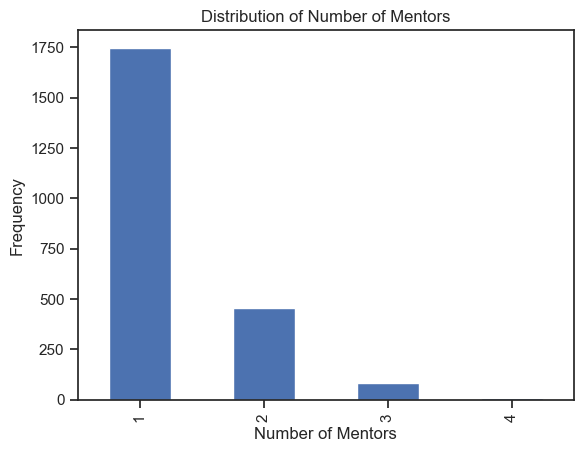

In [21]:
import matplotlib.pyplot as plt

# Assuming the data is in a DataFrame called df and the column is 'Number_of_Mentors'
df['# of Mentors'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Number of Mentors')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Mentors')
plt.show()

In [22]:
unistats(df)

,Count,Unique,Missing_%,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
user_id,2296,2296,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cohort,2296,4,0.0,int32,2019,2022,2020.0,2021.0,2022.0,2020.74,2021.0,2021,1.03,-0.33,-1.03
Member,2296,3,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
school,2296,23,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
gender,2296,2,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
race/ethnicity,2296,8,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
LOM (control matches),2296,759,0.0,int64,14,2310,726.0,782.0,1416.0,983.57,782.0,782,392.32,0.06,-1.2
matched_sixmonths,2296,2,0.0,int64,0,1,1.0,1.0,1.0,0.99,1.0,1,0.1,-9.63,90.88
# of Mentors,2296,4,0.0,int64,1,4,1.0,1.0,1.0,1.28,1.0,1,0.55,1.98,3.81
online_pair_completion_sr_yr,2296,95,0.0,int64,0,100,27.0,59.0,81.0,52.94,59.0,0,32.51,-0.39,-1.14


All variables are now normally distributed (as closely as possible) or are a categorical variable. matched_sixmonths is a binary 0/1 variable and will not be used numerically, but as a categorical variable.

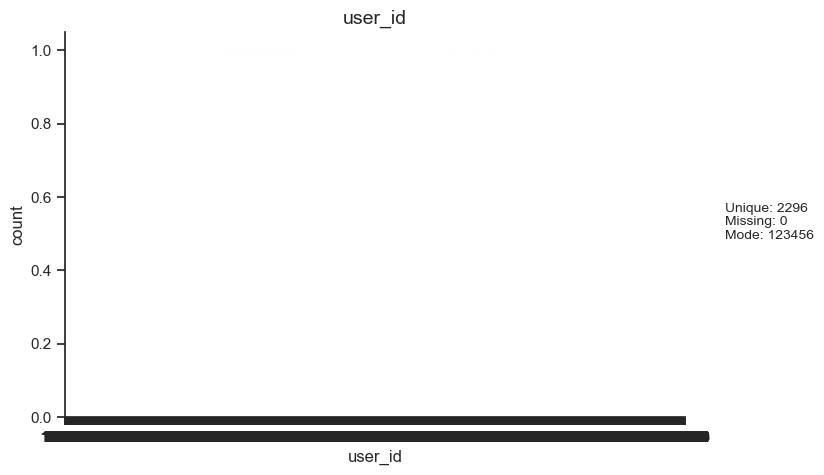

<Figure size 800x500 with 0 Axes>

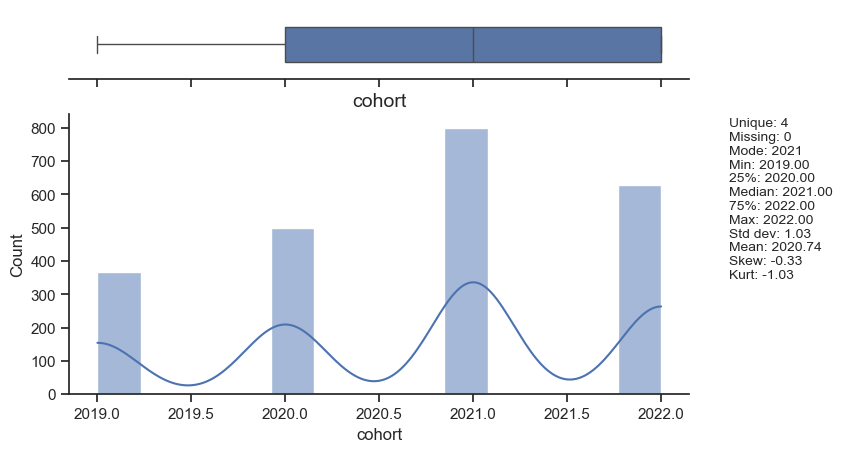

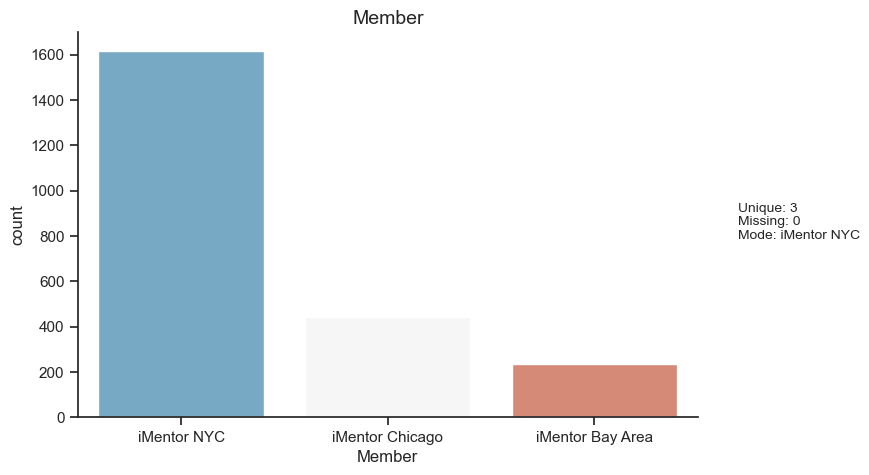

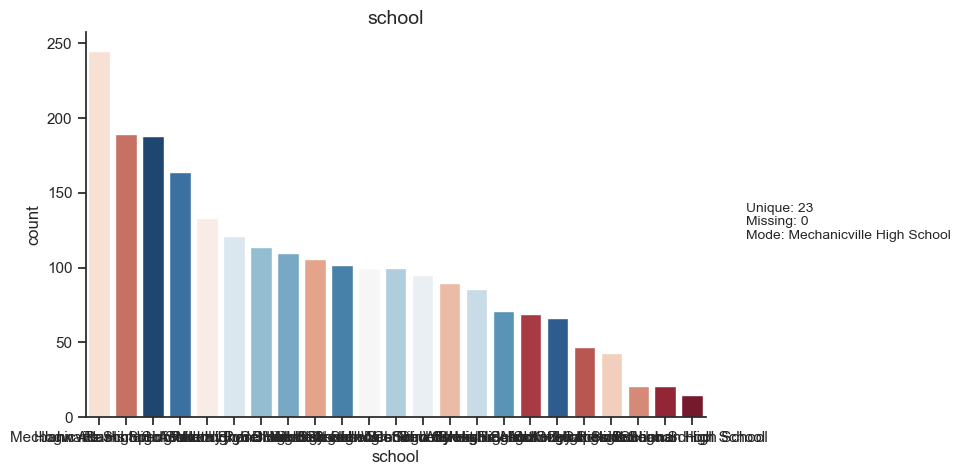

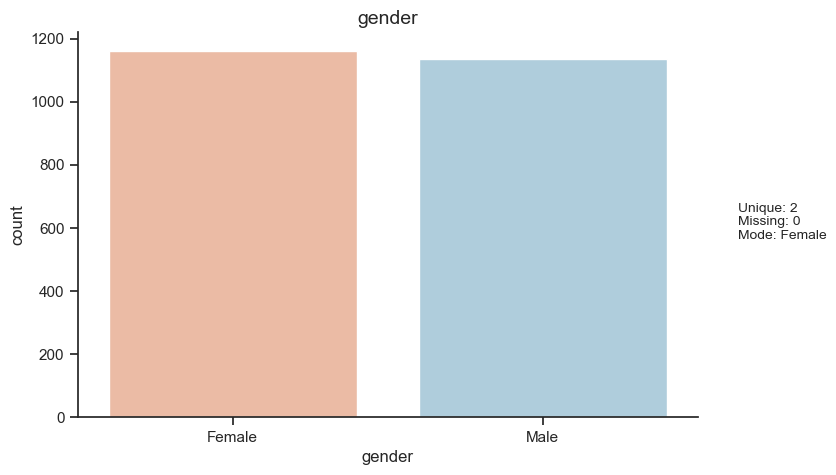

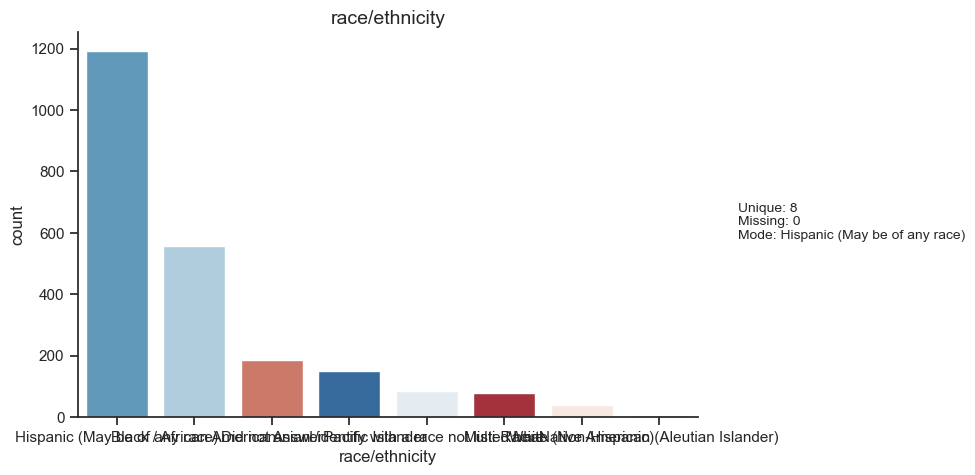

<Figure size 800x500 with 0 Axes>

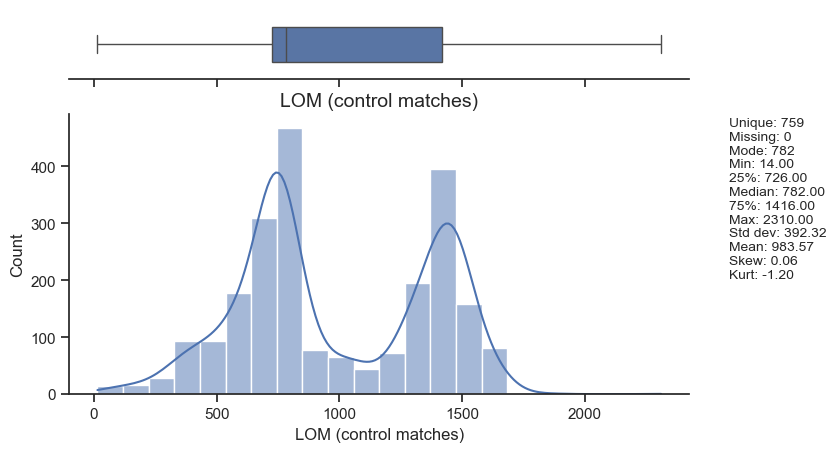

<Figure size 800x500 with 0 Axes>

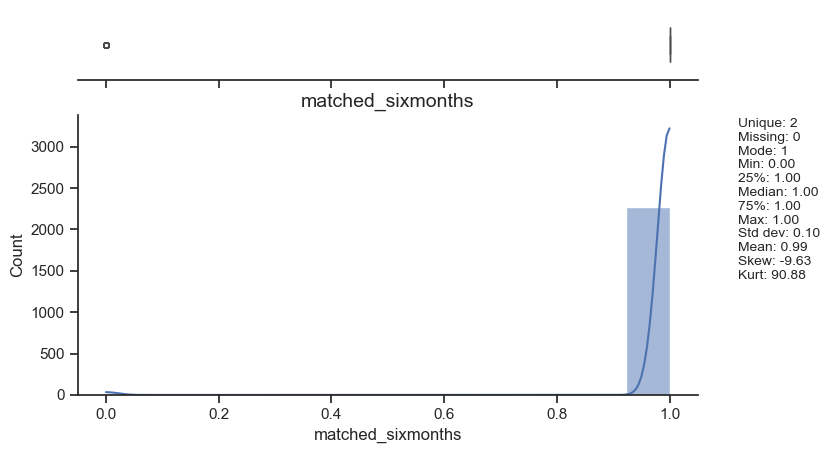

<Figure size 800x500 with 0 Axes>

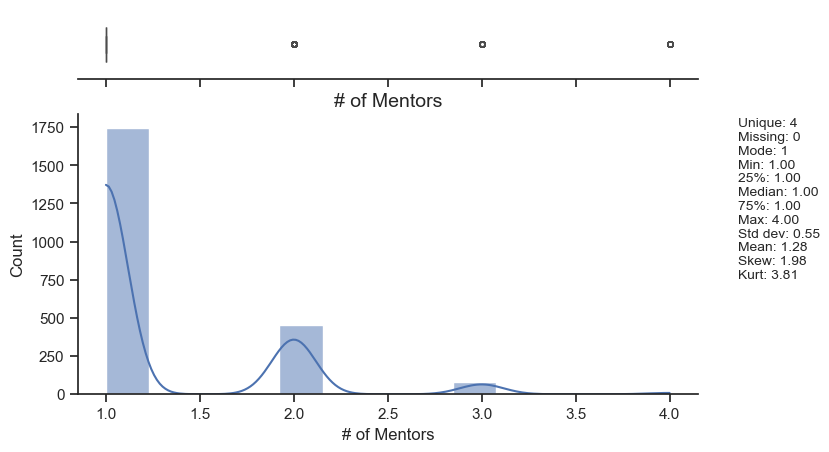

<Figure size 800x500 with 0 Axes>

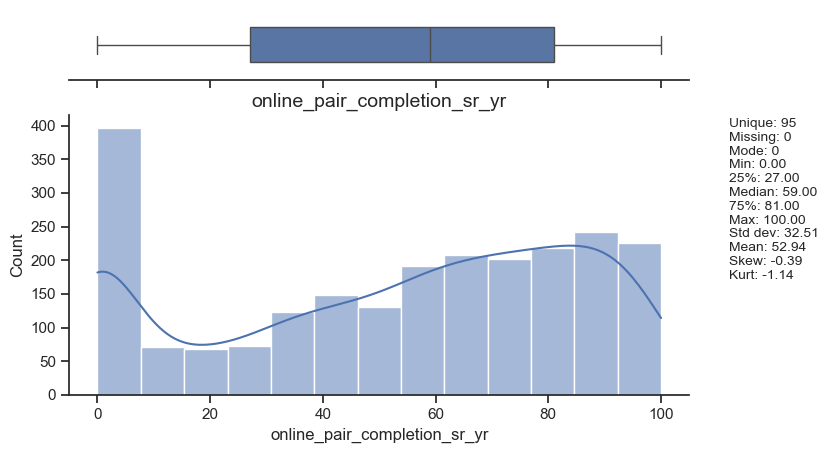

<Figure size 800x500 with 0 Axes>

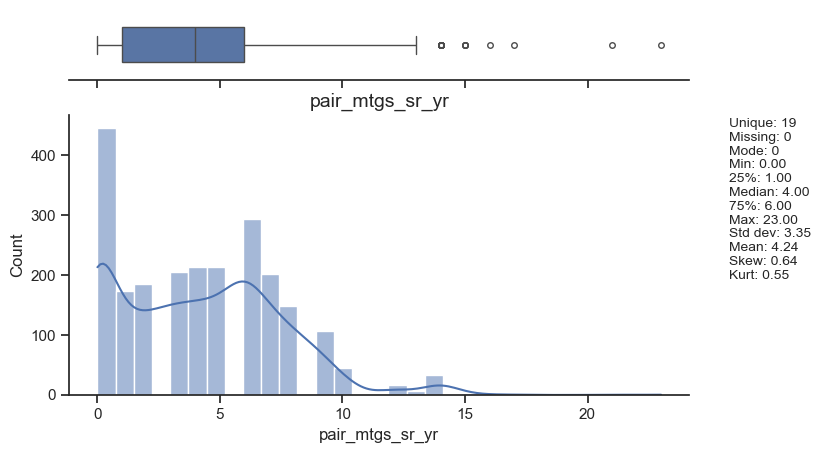

<Figure size 800x500 with 0 Axes>

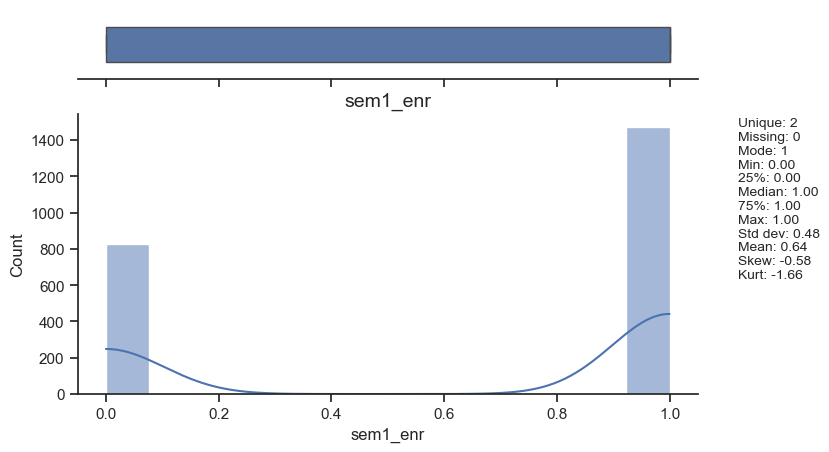

<Figure size 800x500 with 0 Axes>

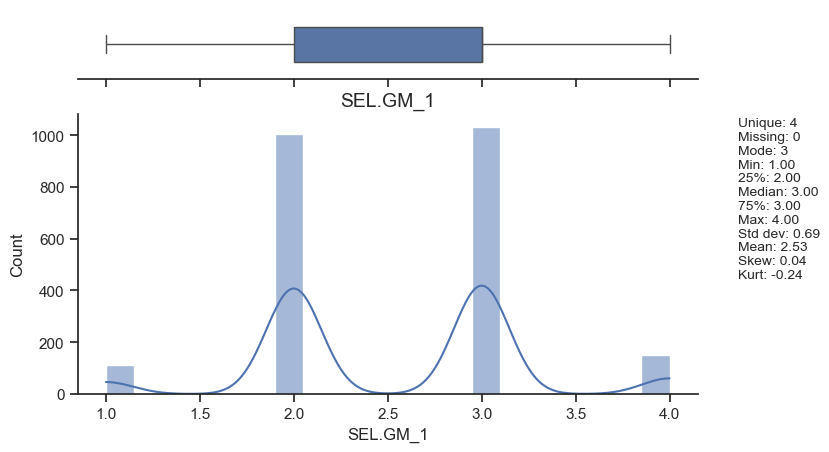

<Figure size 800x500 with 0 Axes>

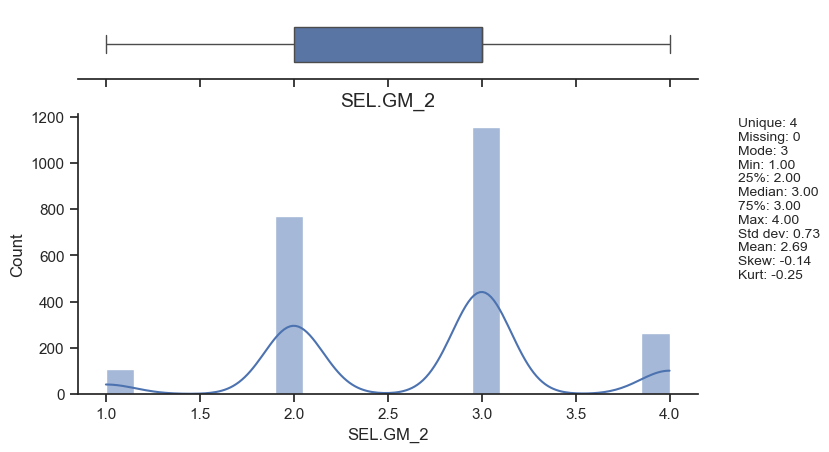

<Figure size 800x500 with 0 Axes>

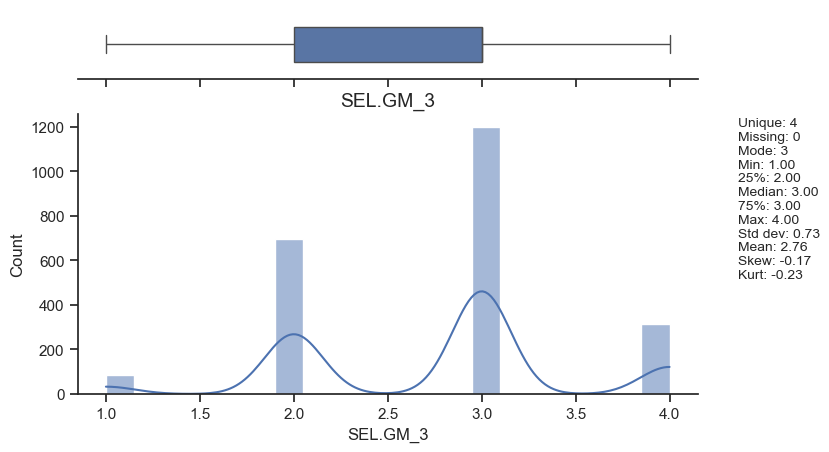

<Figure size 800x500 with 0 Axes>

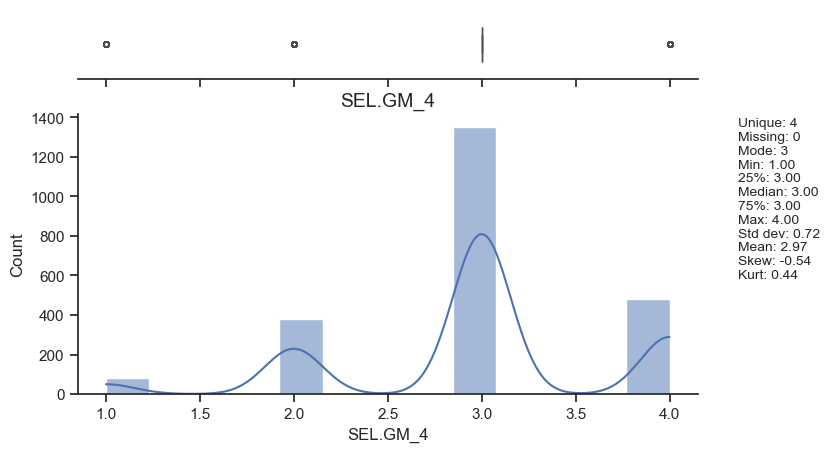

<Figure size 800x500 with 0 Axes>

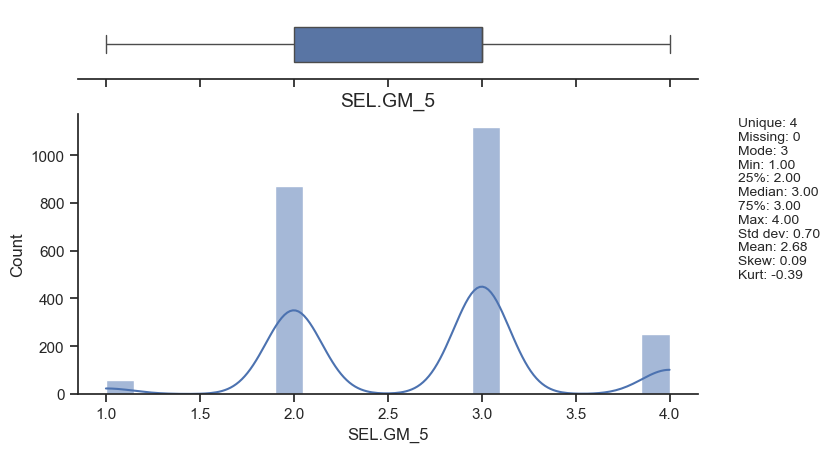

<Figure size 800x500 with 0 Axes>

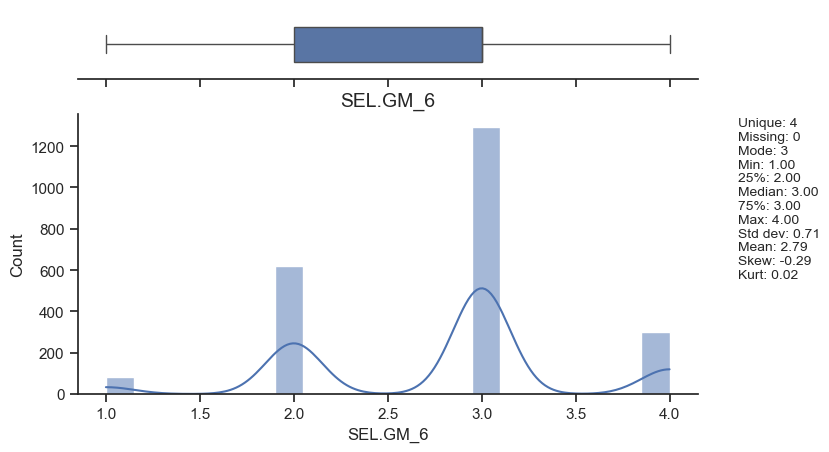

<Figure size 800x500 with 0 Axes>

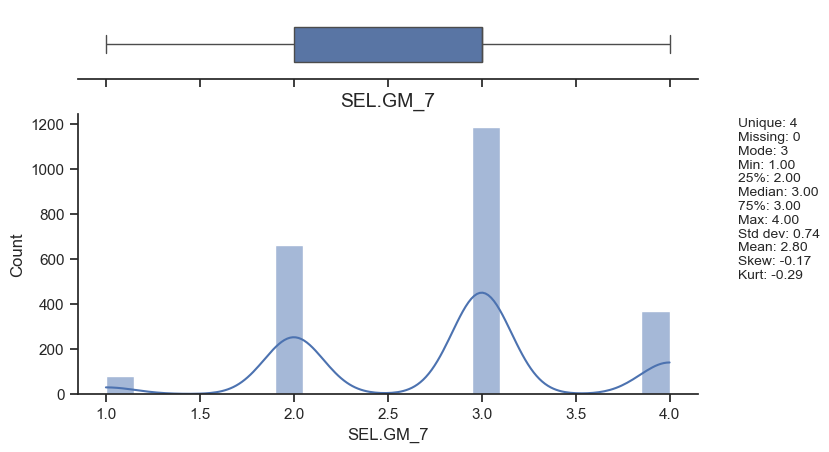

<Figure size 800x500 with 0 Axes>

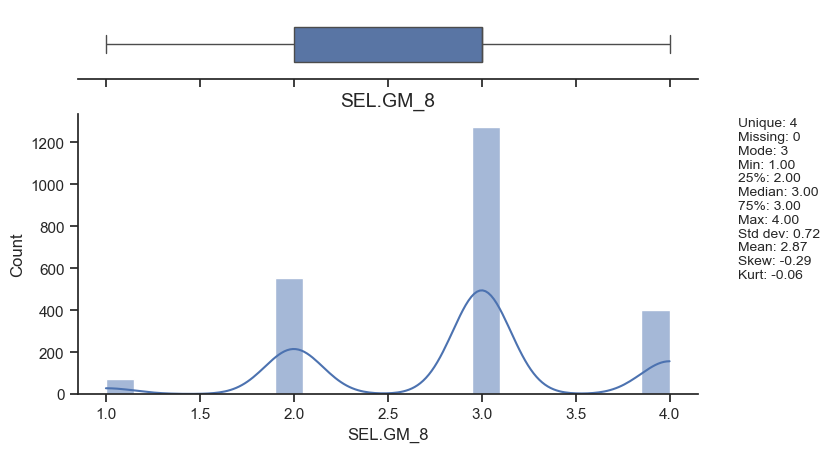

<Figure size 800x500 with 0 Axes>

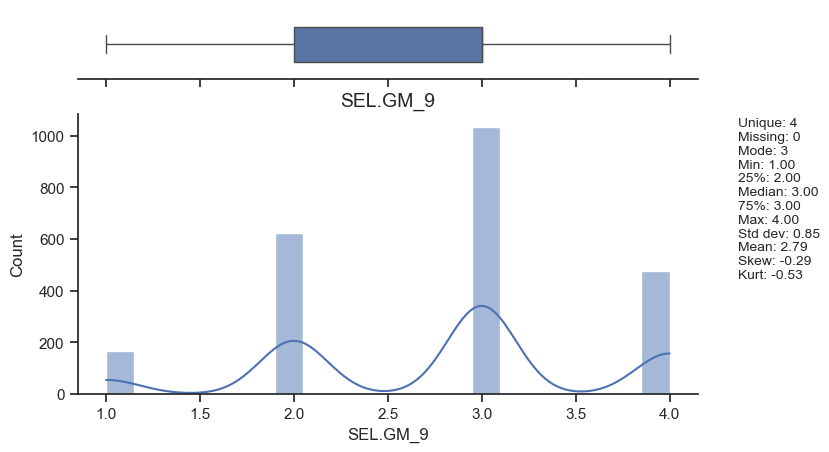

<Figure size 800x500 with 0 Axes>

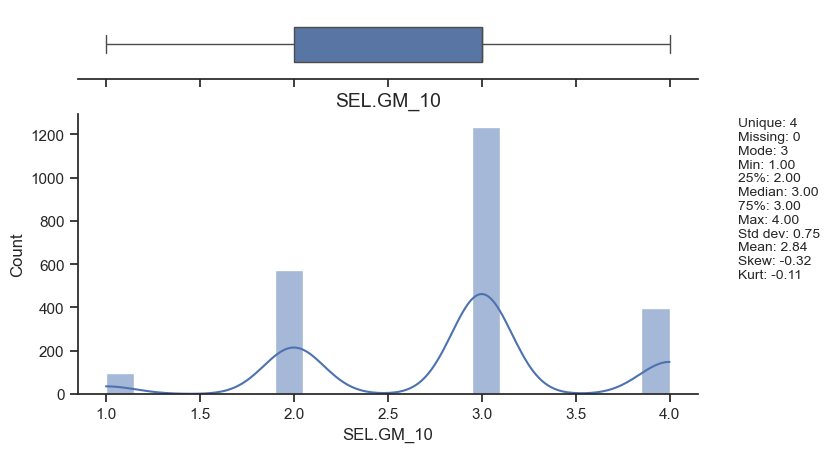

<Figure size 800x500 with 0 Axes>

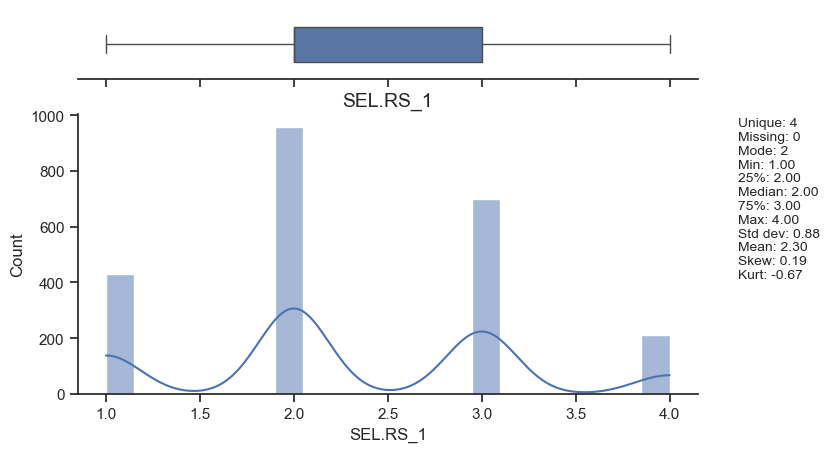

<Figure size 800x500 with 0 Axes>

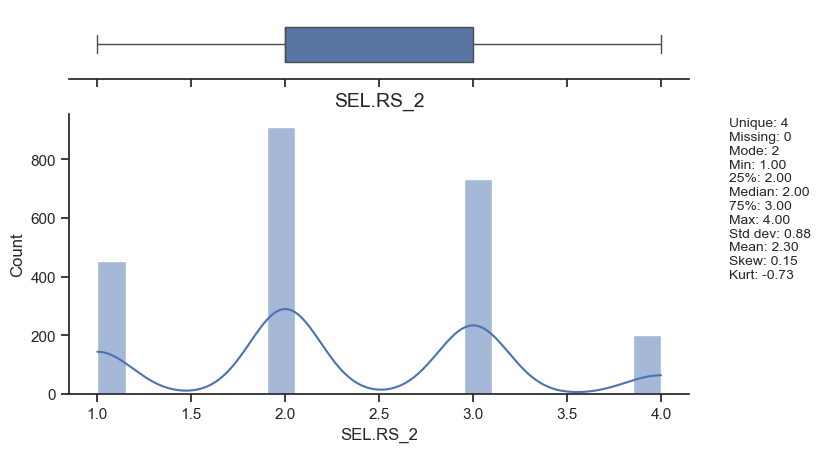

<Figure size 800x500 with 0 Axes>

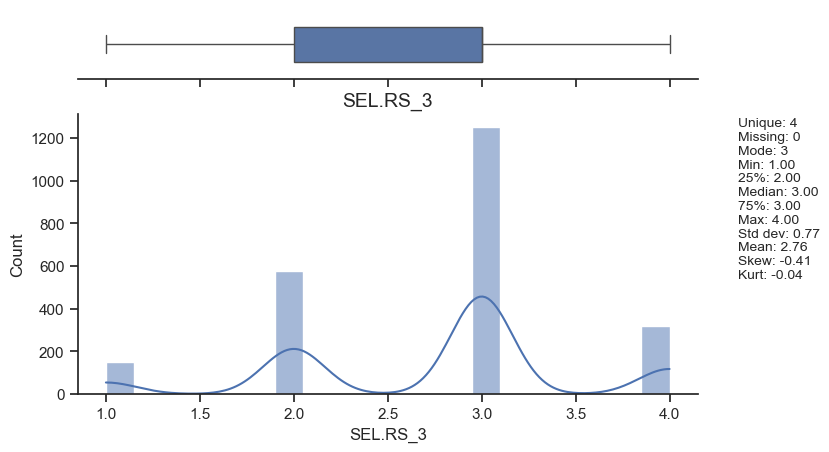

<Figure size 800x500 with 0 Axes>

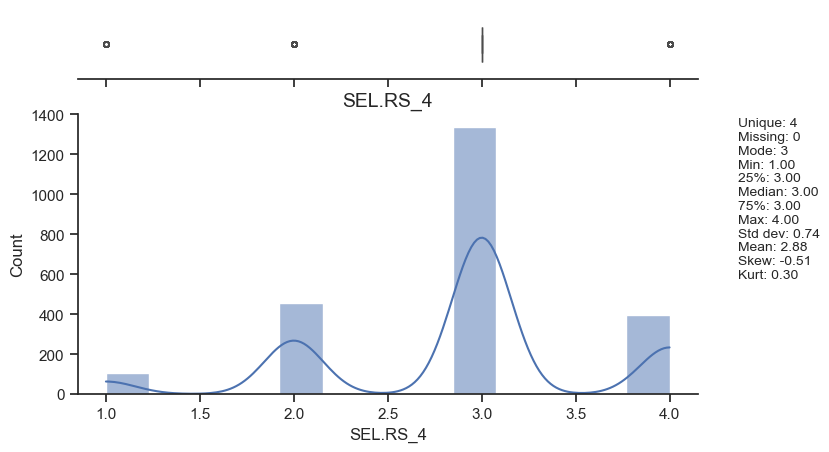

<Figure size 800x500 with 0 Axes>

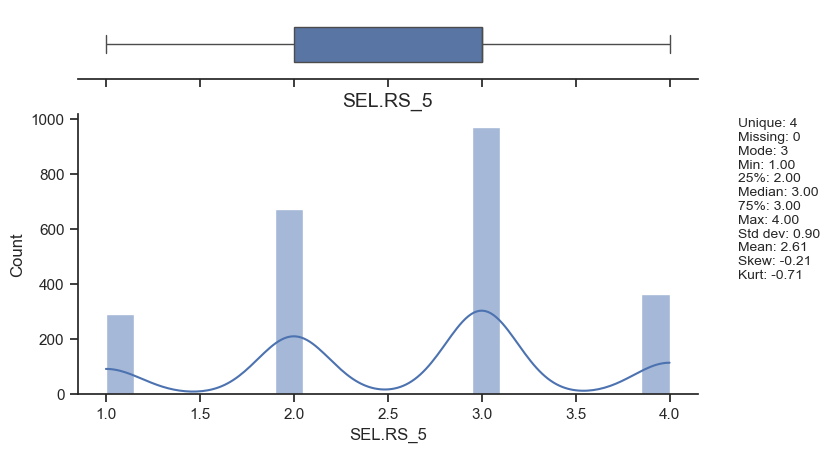

<Figure size 800x500 with 0 Axes>

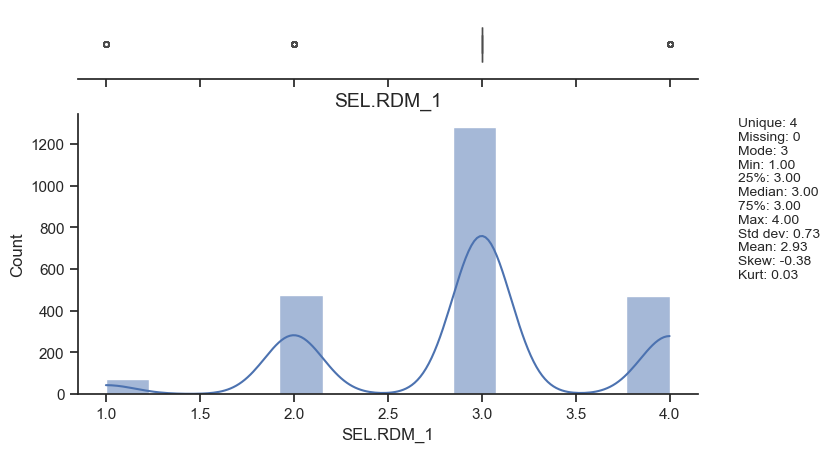

<Figure size 800x500 with 0 Axes>

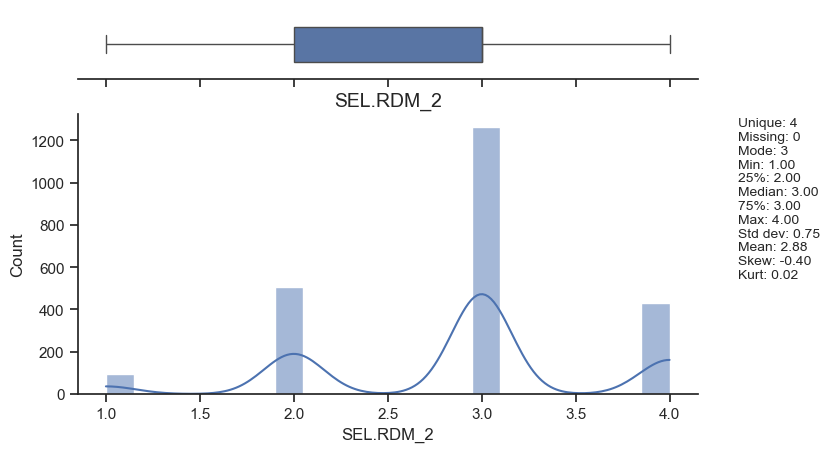

<Figure size 800x500 with 0 Axes>

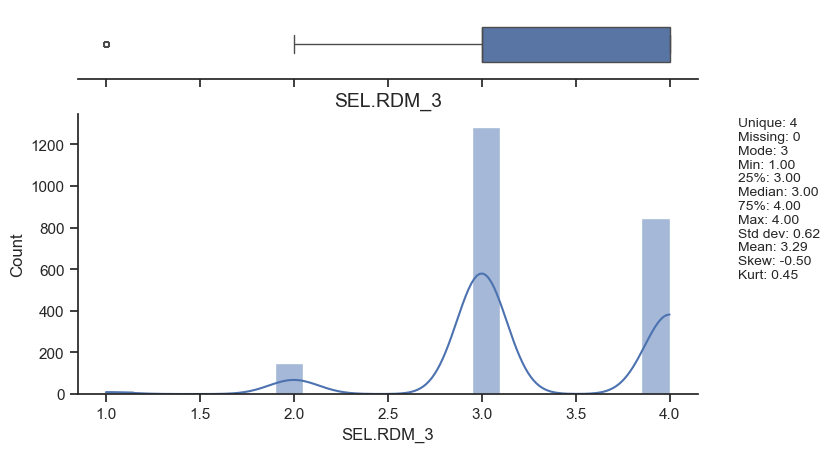

<Figure size 800x500 with 0 Axes>

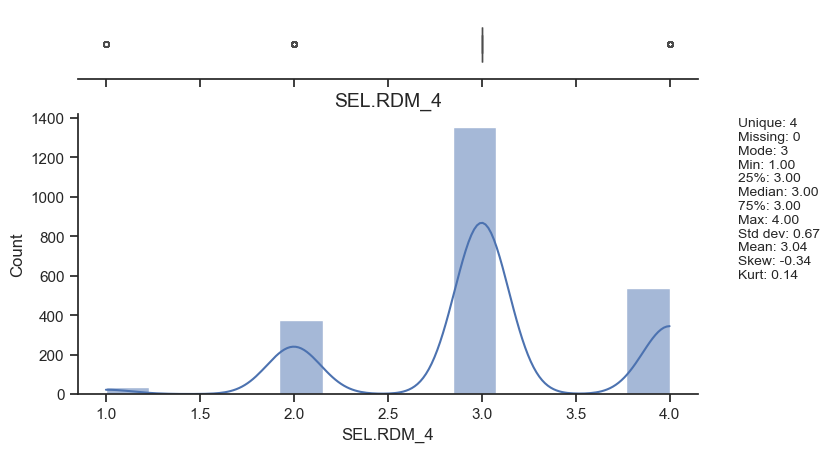

<Figure size 800x500 with 0 Axes>

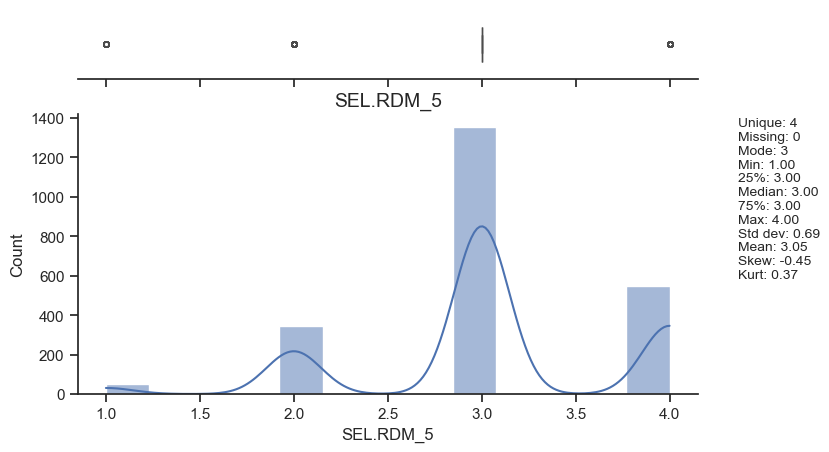

In [23]:
univariate_charts(df)

In [24]:
bivariate_stats(df = df, label = 'sem1_enr')

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_stats_py.py:4102: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if _f_oneway_is_too_small(samples):


,missing,p,r,y = m(x) + b,F,X2
SEL.RS_2,0.00%,-0.0243,0.2444,y = -0.0132(x) + 0.6702,-,-
SEL.RS_4,0.00%,-0.0012,0.9543,y = -0.0008(x) + 0.642,-,-
SEL.RS_1,0.00%,-0.0002,0.9926,y = -0.0001(x) + 0.6401,-,-
school,0.00%,0.0000,-,-,4.8587,-
gender,0.00%,0.0000,-,-,22.6955,-
# of Mentors,0.00%,0.0036,0.862,y = 0.0032(x) + 0.6357,-,-
SEL.GM_7,0.00%,0.0080,0.7003,y = 0.0052(x) + 0.6252,-,-
SEL.RDM_2,0.00%,0.0118,0.5726,y = 0.0075(x) + 0.6181,-,-
SEL.RDM_1,0.00%,0.0119,0.5672,y = 0.0079(x) + 0.6168,-,-
SEL.RDM_4,0.00%,0.0187,0.3714,y = 0.0133(x) + 0.5994,-,-


In [25]:
import pandas as pd
from scipy import stats

def bivariate_stats_logistic(df, label, roundto=4):
    import statsmodels.api as sm

    output_df = pd.DataFrame(columns=['missing', 'p', 'coef', 'std_err', 'z', 'X2'])

    for feature in df.columns:
        if feature != label:
            df_temp = df[[feature, label]].dropna()
            missing = (df.shape[0] - df_temp.shape[0]) / df.shape[0]

            if pd.api.types.is_numeric_dtype(df_temp[feature]) and pd.api.types.is_numeric_dtype(df_temp[label]):
                X = sm.add_constant(df_temp[feature])
                y = df_temp[label]
                model = sm.Logit(y, X).fit(disp=0)
                coef = model.params[1]
                std_err = model.bse[1]
                z = model.tvalues[1]
                p = model.pvalues[1]
                output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), round(coef, roundto), round(std_err, roundto), round(z, roundto), '-']

            elif not pd.api.types.is_numeric_dtype(df_temp[feature]) and not pd.api.types.is_numeric_dtype(df_temp[label]):
                contingency_table = pd.crosstab(df_temp[feature], df_temp[label])
                X2, p, dof, expected = stats.chi2_contingency(contingency_table)
                output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), '-', '-', '-', round(X2, roundto)]

            else:
                if pd.api.types.is_numeric_dtype(df_temp[feature]):
                    num = feature
                    cat = label
                else:
                    num = label
                    cat = feature

                groups = df_temp[cat].unique()
                group_lists = [df_temp[df_temp[cat] == g][num] for g in groups]
                results = stats.f_oneway(*group_lists)
                F = results[0]
                p = results[1]
                output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), '-', '-', '-', round(F, roundto)]

    return output_df.sort_values(by=['p'])

In [26]:
import warnings
warnings.filterwarnings('ignore')

bivariate_stats_logistic(df = df, label = 'sem1_enr')


,missing,p,coef,std_err,z,X2
school,0.00%,0.0000,-,-,-,4.8587
gender,0.00%,0.0000,-,-,-,22.6955
LOM (control matches),0.00%,0.0000,0.0009,0.0001,7.9979,-
pair_mtgs_sr_yr,0.00%,0.0000,0.1541,0.0146,10.5578,-
online_pair_completion_sr_yr,0.00%,0.0000,0.0134,0.0014,9.8356,-
matched_sixmonths,0.00%,0.0004,1.6911,0.4734,3.5719,-
cohort,0.00%,0.0052,0.1177,0.0421,2.796,-
SEL.GM_9,0.00%,0.0067,0.1384,0.0511,2.7102,-
SEL.GM_4,0.00%,0.0131,0.1491,0.0601,2.4814,-
SEL.GM_5,0.00%,0.0313,0.1346,0.0625,2.1535,-


Interpretation: the linear relationship between the explanatory variables (C2C, N2C, and N2N) are explored with the log odds (logit) of the outcome variable, label, which is sem1_enr. It is discovered here that school, gender, LOM (control matches), pair_mtgs_sr_yr, online_pair_completion_sr_yr, matched_sixmonths, cohort, SEL.GM_9, SEL.GM_4, SEL.GM_5, and SEL.RDM_5 all have p-values < 0.005, meaning that they were statistically significant predictors of the outcome variable. 

In [27]:
import pandas as pd
from scipy import stats
import statsmodels.api as sm

def bivariate_stats_logistic_option_2(df, label, roundto=4):
    output_df = pd.DataFrame(columns=['missing', 'p', 'coef', 'std_err', 'z', 'X2'])

    for feature in df.columns:
        if feature != label:
            df_temp = df[[feature, label]].dropna()
            missing = (df.shape[0] - df_temp.shape[0]) / df.shape[0]

            # Ensure outcome is binary before applying logistic regression
            if pd.api.types.is_numeric_dtype(df_temp[feature]) and pd.api.types.is_numeric_dtype(df_temp[label]) and df_temp[label].nunique() == 2:
                X = sm.add_constant(df_temp[feature])
                y = df_temp[label]
                model = sm.Logit(y, X).fit(disp=0)
                coef = model.params[1]
                std_err = model.bse[1]
                z = model.tvalues[1]
                p = model.pvalues[1]
                output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), round(coef, roundto), round(std_err, roundto), round(z, roundto), '-']

            # Chi-square test for categorical-to-categorical (C2C)
            elif not pd.api.types.is_numeric_dtype(df_temp[feature]) and not pd.api.types.is_numeric_dtype(df_temp[label]):
                contingency_table = pd.crosstab(df_temp[feature], df_temp[label])
                X2, p, dof, expected = stats.chi2_contingency(contingency_table)

                # Check for small sample issues
                if (expected < 5).sum() > 0:
                    X2, p = stats.fisher_exact(contingency_table)

                output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), '-', '-', '-', round(X2, roundto)]

            # ANOVA (C2N) but fallback to Kruskal-Wallis if normality assumption fails
            else:
                if pd.api.types.is_numeric_dtype(df_temp[feature]):
                    num = feature
                    cat = label
                else:
                    num = label
                    cat = feature

                groups = df_temp[cat].unique()
                group_lists = [df_temp[df_temp[cat] == g][num] for g in groups]

                # Check normality assumption for ANOVA
                if all(stats.shapiro(group)[1] > 0.05 for group in group_lists if len(group) > 3): 
                    results = stats.f_oneway(*group_lists)  # Use ANOVA if normality holds
                else:
                    results = stats.kruskal(*group_lists)  # Use Kruskal-Wallis if normality fails
                
                F = results[0]
                p = results[1]
                output_df.loc[feature] = [f'{missing:.2%}', round(p, roundto), '-', '-', '-', round(F, roundto)]

    return output_df.sort_values(by=['p'])



In [28]:
import warnings
warnings.filterwarnings("ignore")
bivariate_stats_logistic_option_2(df=df, label='sem1_enr')

,missing,p,coef,std_err,z,X2
school,0.00%,0.0000,-,-,-,103.0791
gender,0.00%,0.0000,-,-,-,22.4829
LOM (control matches),0.00%,0.0000,0.0009,0.0001,7.9979,-
pair_mtgs_sr_yr,0.00%,0.0000,0.1541,0.0146,10.5578,-
online_pair_completion_sr_yr,0.00%,0.0000,0.0134,0.0014,9.8356,-
matched_sixmonths,0.00%,0.0004,1.6911,0.4734,3.5719,-
cohort,0.00%,0.0052,0.1177,0.0421,2.796,-
SEL.GM_9,0.00%,0.0067,0.1384,0.0511,2.7102,-
SEL.GM_4,0.00%,0.0131,0.1491,0.0601,2.4814,-
SEL.GM_5,0.00%,0.0313,0.1346,0.0625,2.1535,-


So now this code is more robust because it checks to see if the outcome variable is truly binary, accounts for normality assumptions for each data distribution, and Fisher's test if the contingency table has to few values for exact counts. However, the results are the same, except for that variable of school we already knew the X2 value was significant. The impact now just shows how much more of an effect size school has on sem1_enr.

The next way to enhance the model here would be looking at transformations of the variables that are not statistically significant, to determine if they would be able to be transformed for statistical signifiance, such as polynominal transformations and feature engineering since the variables are already meeting the assumption of normality.

Because the # of Mentors is not normally distributed it should actually be treated as a categorical variable (ordinal level) because technically we could categorize by number of members as discrete integer values. Categoically, this may be more useful than using it as an integer value. Then I will use either min-max normalization or Z-Score Standardization to prepare the data for correct modeling.

Since # of Mentors only has three values (1, 2, 3, or 4) I am going to treat this instead as a categorical variable with an ordinal value set which is similar to cohort, and transform it into type object.

In [29]:
df['# of Mentors'] = df['# of Mentors'].astype('object')

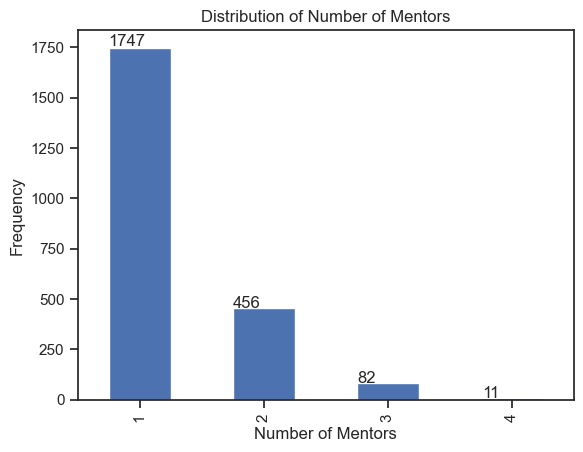

In [30]:
import matplotlib.pyplot as plt

# Plot the distribution of '# of Mentors'
ax = df['# of Mentors'].value_counts().sort_index().plot(kind='bar')

# Add count above each bar
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Number of Mentors')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Mentors')
plt.show()

In [31]:
unistats(df)

,Count,Unique,Missing_%,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
user_id,2296,2296,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cohort,2296,4,0.0,int32,2019,2022,2020.0,2021.0,2022.0,2020.74,2021.0,2021,1.03,-0.33,-1.03
Member,2296,3,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
school,2296,23,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
gender,2296,2,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
race/ethnicity,2296,8,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
LOM (control matches),2296,759,0.0,int64,14,2310,726.0,782.0,1416.0,983.57,782.0,782,392.32,0.06,-1.2
matched_sixmonths,2296,2,0.0,int64,0,1,1.0,1.0,1.0,0.99,1.0,1,0.1,-9.63,90.88
# of Mentors,2296,4,0.0,object,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
online_pair_completion_sr_yr,2296,95,0.0,int64,0,100,27.0,59.0,81.0,52.94,59.0,0,32.51,-0.39,-1.14


In [32]:
import warnings

warnings.filterwarnings('ignore')
bivariate_stats_logistic_option_2(df=df, label='sem1_enr')

,missing,p,coef,std_err,z,X2
school,0.00%,0.0000,-,-,-,103.0791
gender,0.00%,0.0000,-,-,-,22.4829
LOM (control matches),0.00%,0.0000,0.0009,0.0001,7.9979,-
pair_mtgs_sr_yr,0.00%,0.0000,0.1541,0.0146,10.5578,-
online_pair_completion_sr_yr,0.00%,0.0000,0.0134,0.0014,9.8356,-
matched_sixmonths,0.00%,0.0004,1.6911,0.4734,3.5719,-
cohort,0.00%,0.0052,0.1177,0.0421,2.796,-
SEL.GM_9,0.00%,0.0067,0.1384,0.0511,2.7102,-
SEL.GM_4,0.00%,0.0131,0.1491,0.0601,2.4814,-
SEL.GM_5,0.00%,0.0313,0.1346,0.0625,2.1535,-


The # of Mentors is not currently statistically significant, but when feature engineering, this may change.

Creates a Heatmap/Crosstab automated visualization

In [33]:
def crosstab(df, feature, label, roundto=4):
  import pandas as pd
  import matplotlib.pyplot as plt
  import seaborn as sns
  from scipy import stats
  import numpy as np

  # Generate the crosstab
  crosstab = pd.crosstab(df[feature], df[label])

  # Calculate the statistics
  X, p, dof, contingency_table = stats.chi2_contingency(crosstab)

  textstr = f'X2: {X}\n'
  textstr += f'p: {p}'
  plt.text(.95, 0.2, textstr, fontsize=12, transform=plt.gcf().transFigure)

  ct_df = pd.DataFrame(np.rint(contingency_table).astype('int64'), columns=crosstab.columns, index=crosstab.index)
  sns.heatmap(ct_df, annot=True, fmt='d', cmap='coolwarm')
  plt.show()

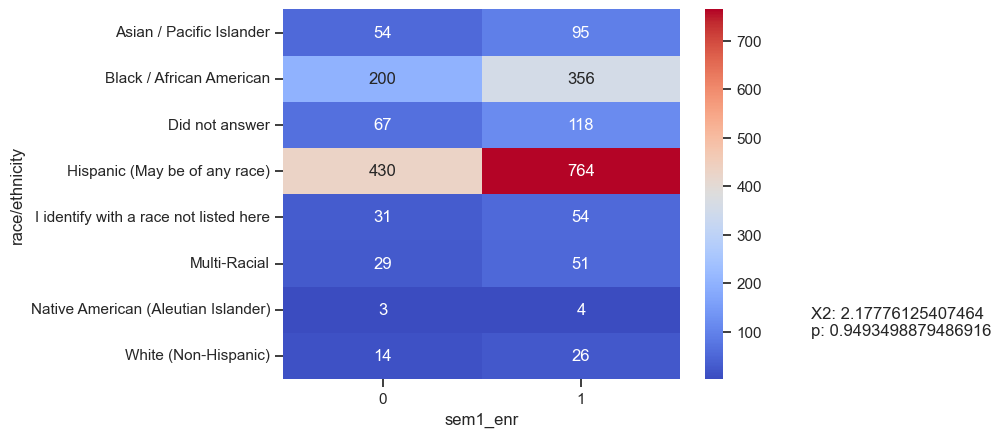

In [34]:
crosstab(df, 'race/ethnicity', 'sem1_enr')

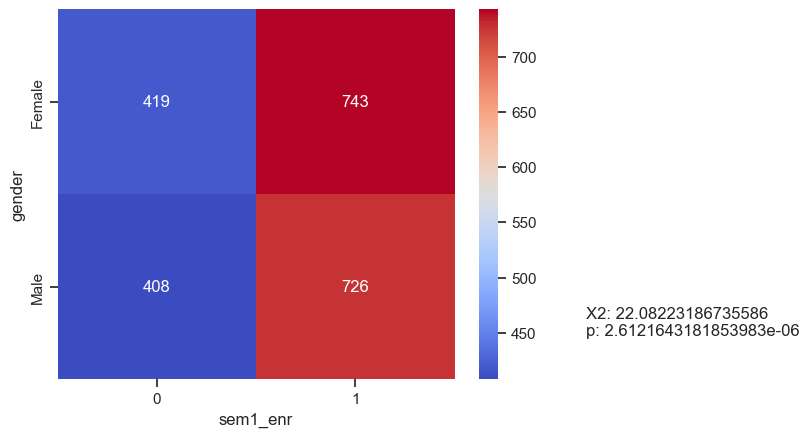

In [35]:
crosstab(df, 'gender', 'sem1_enr')

## Exploratory Data Analysis

In [36]:
def scatterplot(df, feature, label, roundto=3, linecolor='darkorange'):
  import pandas as pd
  from matplotlib import pyplot as plt
  import seaborn as sns
  from scipy import stats

  # Create the plot
  sns.regplot(x=df[feature], y=df[label], line_kws={"color": linecolor})

  # Calculate the regression line so that we can print the text
  m, b, r, p, err = stats.linregress(df[feature], df[label])

  # Add all descriptive statistics to the diagram
  textstr  = 'Regression line:' + '\n'
  textstr += 'y  = ' + str(round(m, roundto)) + 'x + ' + str(round(b, roundto)) + '\n'
  textstr += 'r   = ' + str(round(r, roundto)) + '\n'
  textstr += 'r2 = ' + str(round(r**2, roundto)) + '\n'
  textstr += 'p  = ' + str(round(p, roundto)) + '\n\n'

  plt.text(1, 0.1, textstr, fontsize=12, transform=plt.gcf().transFigure)
  plt.show()

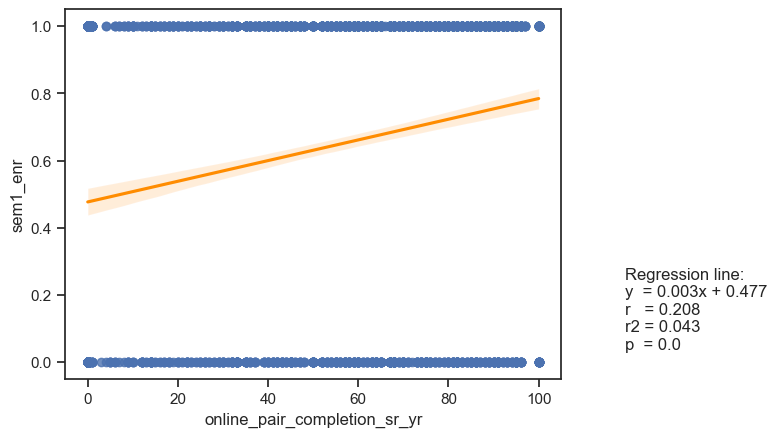

In [37]:
scatterplot(df, feature = 'online_pair_completion_sr_yr', label = 'sem1_enr', linecolor = 'darkorange')

In [38]:
def scatterplot_logistic(df, feature, label, roundto=3, linecolor='darkorange'):
    import pandas as pd
    from matplotlib import pyplot as plt
    import seaborn as sns
    import statsmodels.api as sm
    import numpy as np

    # Create the scatter plot
    sns.scatterplot(x=df[feature], y=df[label])

    # Fit the logistic regression model
    X = sm.add_constant(df[feature])
    y = df[label]
    model = sm.Logit(y, X).fit(disp=0)

    # Generate predicted probabilities
    x_vals = np.linspace(df[feature].min(), df[feature].max(), 100)
    X_vals = sm.add_constant(x_vals)
    y_vals = model.predict(X_vals)

    # Plot the logistic regression line
    plt.plot(x_vals, y_vals, color=linecolor)

    # Add all descriptive statistics to the diagram
    coef = model.params[1]
    intercept = model.params[0]
    p_value = model.pvalues[1]
    textstr  = 'Logistic Regression:' + '\n'
    textstr += 'logit(p) = ' + str(round(coef, roundto)) + 'x + ' + str(round(intercept, roundto)) + '\n'
    textstr += 'p-value = ' + str(round(p_value, roundto)) + '\n'

    plt.text(1, 0.1, textstr, fontsize=12, transform=plt.gcf().transFigure)
    plt.show()

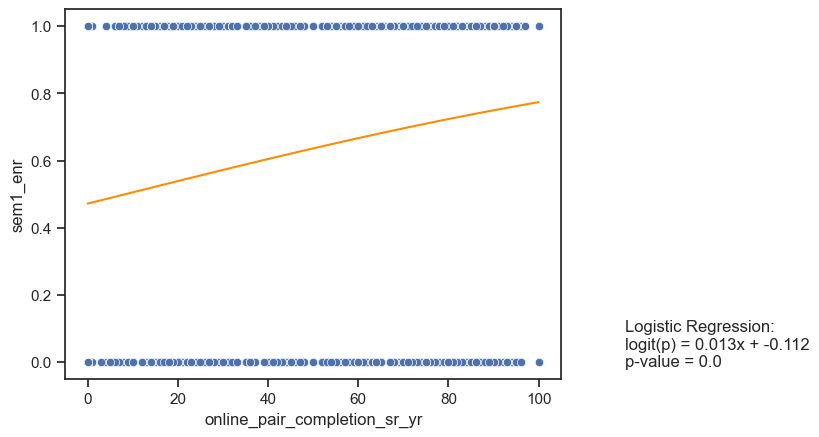

In [39]:
scatterplot_logistic(df, feature = 'online_pair_completion_sr_yr', label = 'sem1_enr')

In [40]:
def bar_chart(df, feature, label, roundto=3):
        import pandas as pd
        from scipy import stats
        from matplotlib import pyplot as plt
        import seaborn as sns
        
        sns.barplot(df, x=feature, y=label)
        
        # Create the label lists needed to calculate oneway-ANOVA F  
        groups = df[feature].unique()
        group_lists = []
        for g in groups:
          g_list = df[df[feature] == g][label]
          group_lists.append(g_list)
      
        results = stats.f_oneway(*group_lists)
        F = results[0]
        p = results[1]
      
        # Next, calculate t-tests with Bonferroni correction for p-value threshold
        ttests = []
        for i1, g1 in enumerate(groups): # Use the enumerate() function to add an index for counting to a list of values
          # For each item, loop through a second list of each item to compare each pair
          for i2, g2 in enumerate(groups):
            if i2 > i1: # If the inner_index is greater that the outer_index, then go ahead and run a t-test
              type_1 = df[df[feature] == g1]
              type_2 = df[df[feature] == g2]
              t, p = stats.ttest_ind(type_1[label], type_2[label])
            
              # Add each t-test result to a list of t, p pairs
              ttests.append([str(g1) + ' - ' + str(g2), round(t, roundto), round(p, roundto)])
      
        p_threshold = 0.05 / len(ttests) # Bonferroni-corrected p-value determined
      
        # Add all descriptive statistics to the diagram
        textstr  = '   ANOVA' + '\n'
        textstr += 'F: ' + str(round(F, roundto)) + '\n'
        textstr += 'p: ' + str(round(p, roundto)) + '\n\n'
      
        # Only include the significant t-tests in the printed results for brevity
        for ttest in ttests:
          if ttest[2] <= p_threshold:
            if 'Sig. comparisons (Bonferroni-corrected)' not in textstr: # Only include the header if there is at least one significant result
              textstr += 'Sig. comparisons (Bonferroni-corrected)' + '\n'
            textstr += str(ttest[0]) + ": t=" + str(ttest[1]) + ", p=" + str(ttest[2]) + '\n'
      
        plt.text(1, 0.1, textstr, fontsize=12, transform=plt.gcf().transFigure)
        plt.xticks(rotation=90)
        plt.show()

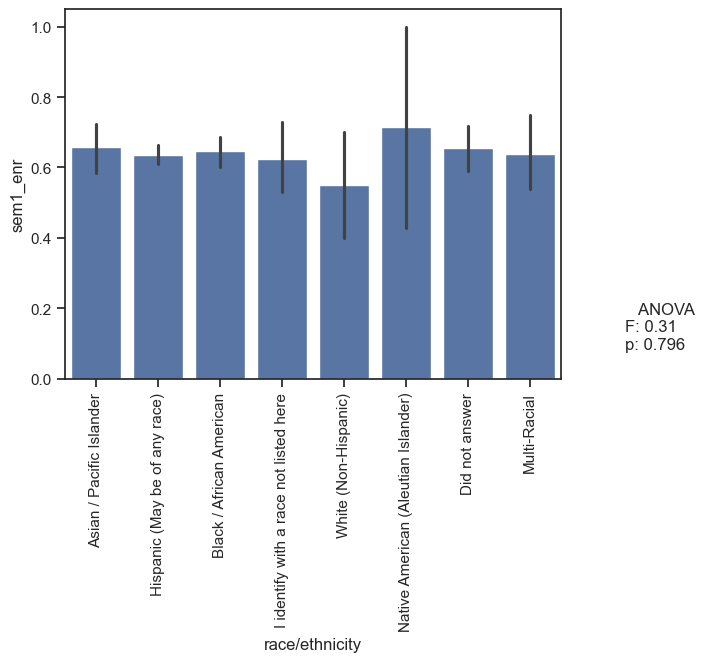

In [41]:
bar_chart(df, feature = 'race/ethnicity', label = 'sem1_enr')

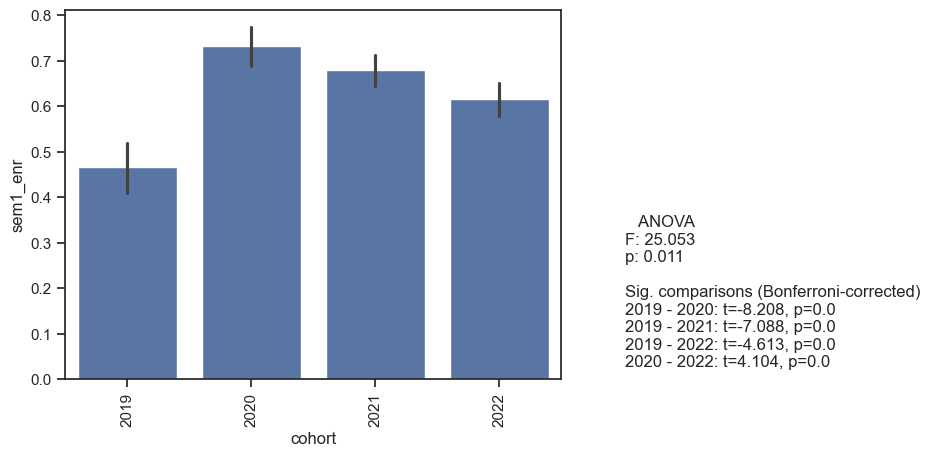

In [42]:
bar_chart(df, feature = 'cohort', label = 'sem1_enr')

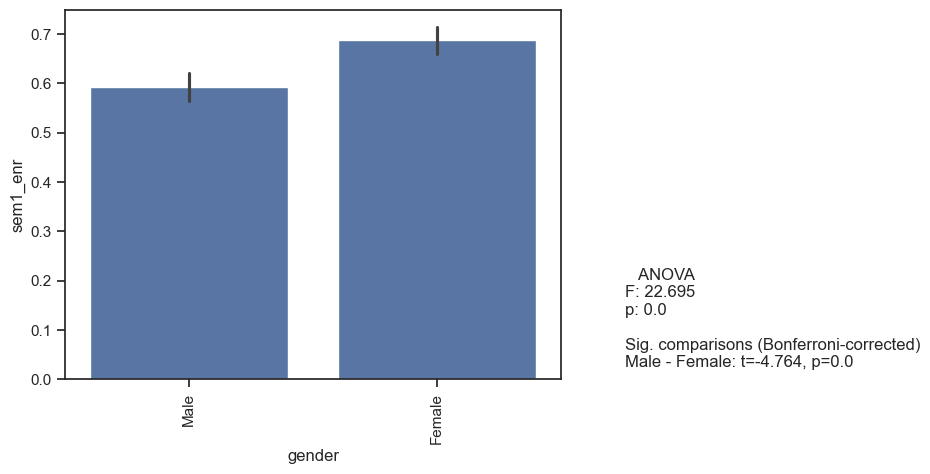

In [43]:
bar_chart(df, feature = 'gender', label = 'sem1_enr')

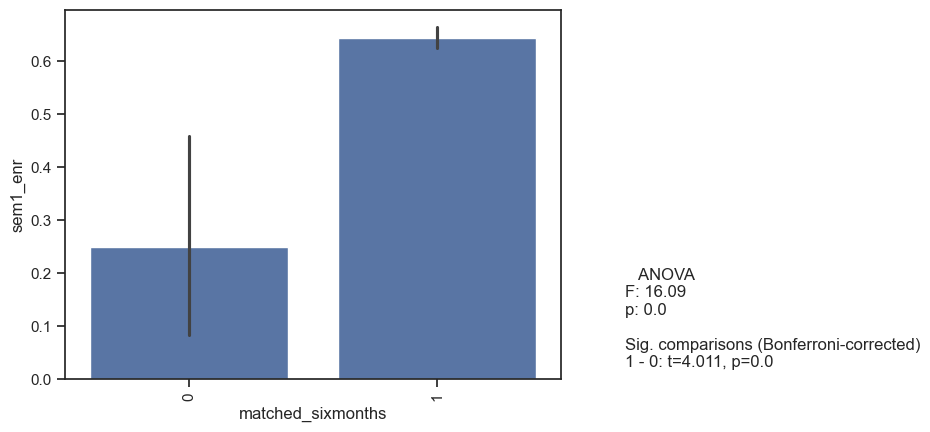

In [44]:
bar_chart(df, feature = 'matched_sixmonths', label = 'sem1_enr')

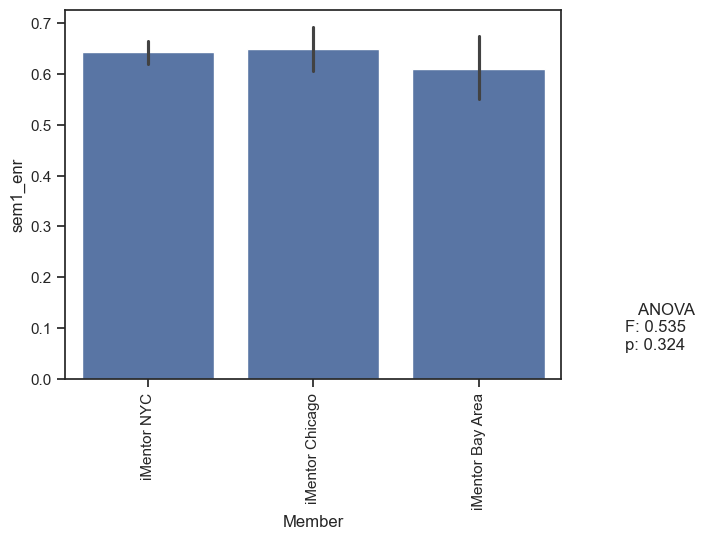

In [45]:
bar_chart(df, feature = 'Member', label = 'sem1_enr')

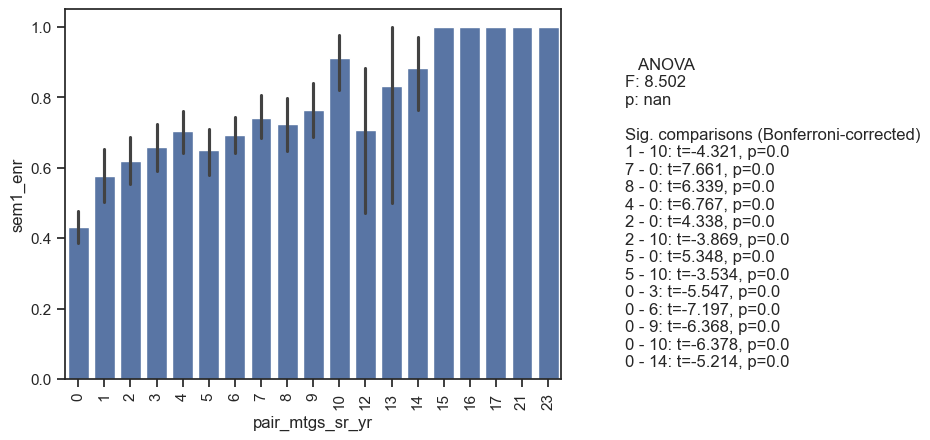

In [46]:
bar_chart(df, feature = 'pair_mtgs_sr_yr', label = 'sem1_enr')

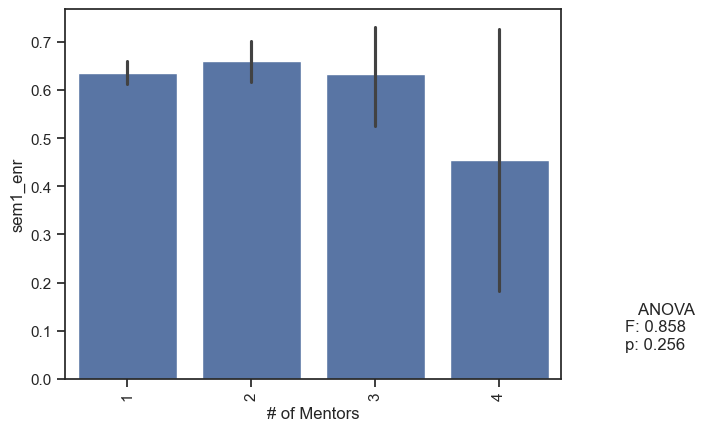

In [47]:
bar_chart(df, feature = '# of Mentors', label='sem1_enr')

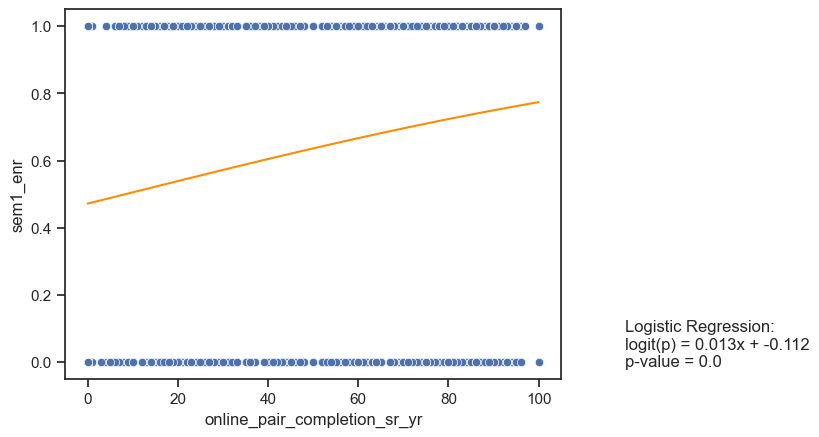

In [48]:
scatterplot_logistic(df, feature = 'online_pair_completion_sr_yr', label = 'sem1_enr')

In [49]:
import pandas as pd
from scipy.stats import ttest_ind

# Assuming df is your DataFrame
# Separate the two populations
group1 = df[df['sem1_enr'] == 1]['online_pair_completion_sr_yr']
group2 = df[df['sem1_enr'] == 0]['online_pair_completion_sr_yr']

# Perform the t-test
t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')

# Print the results
print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

T-statistic: 10.199974105665012
P-value: 6.372178863132945e-24


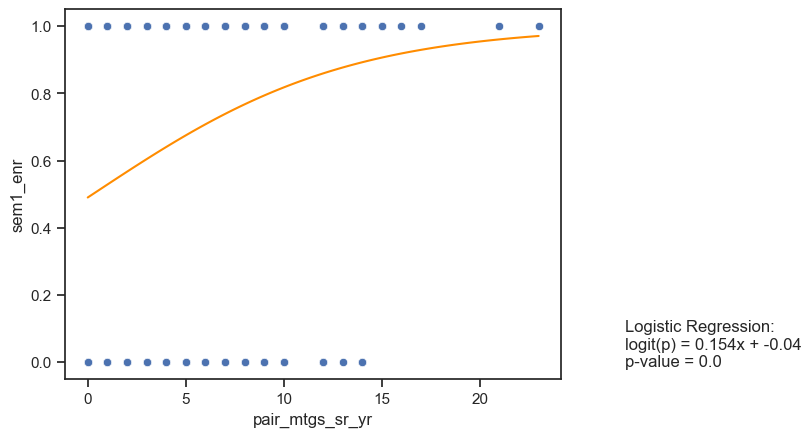

In [50]:
scatterplot_logistic(df, feature = 'pair_mtgs_sr_yr', label = 'sem1_enr')

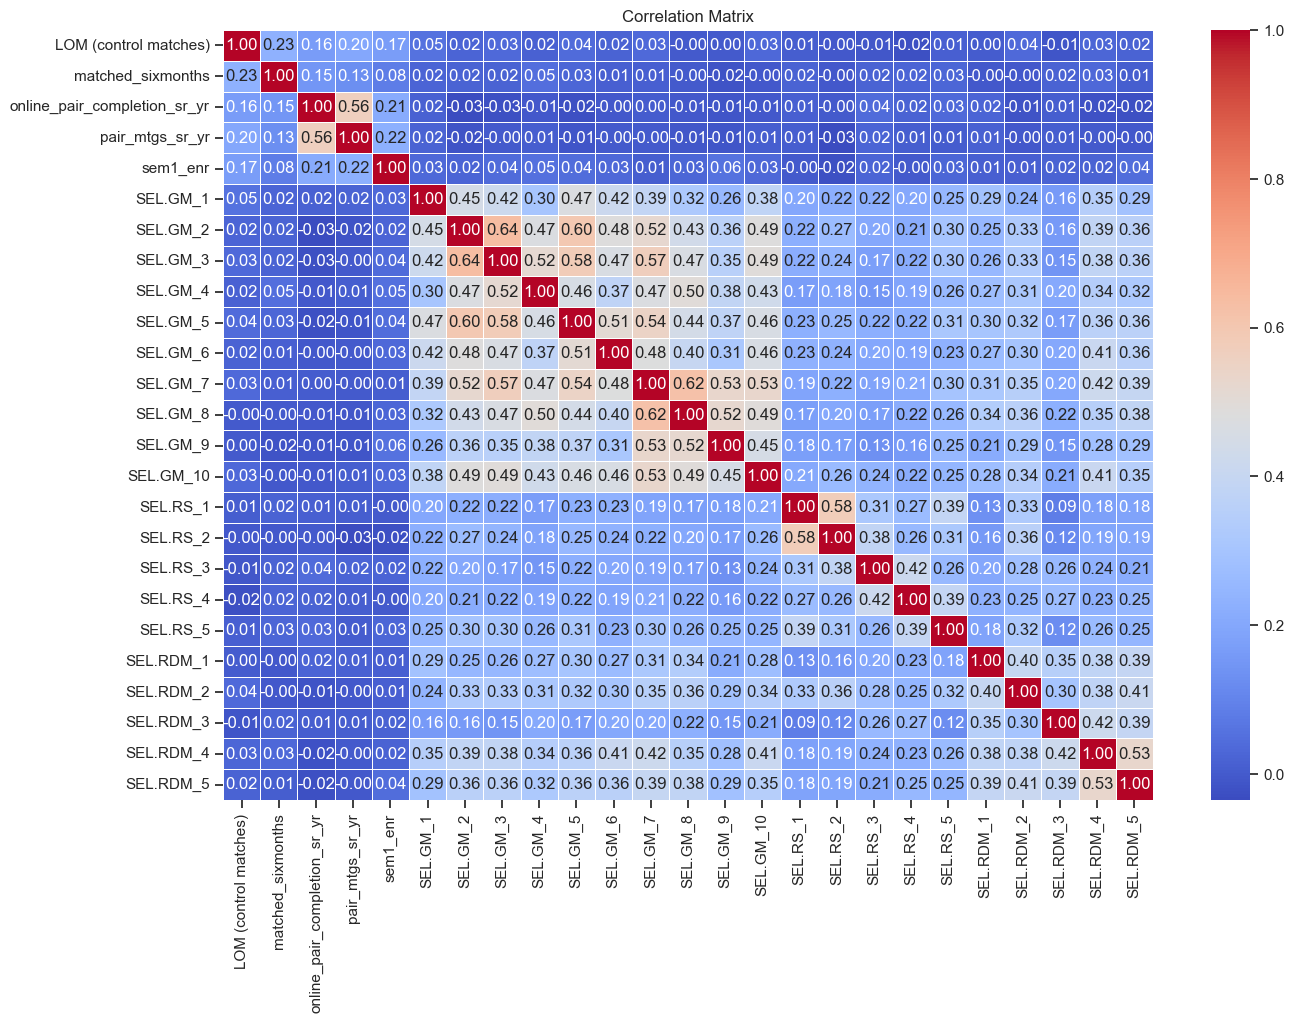

In [51]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

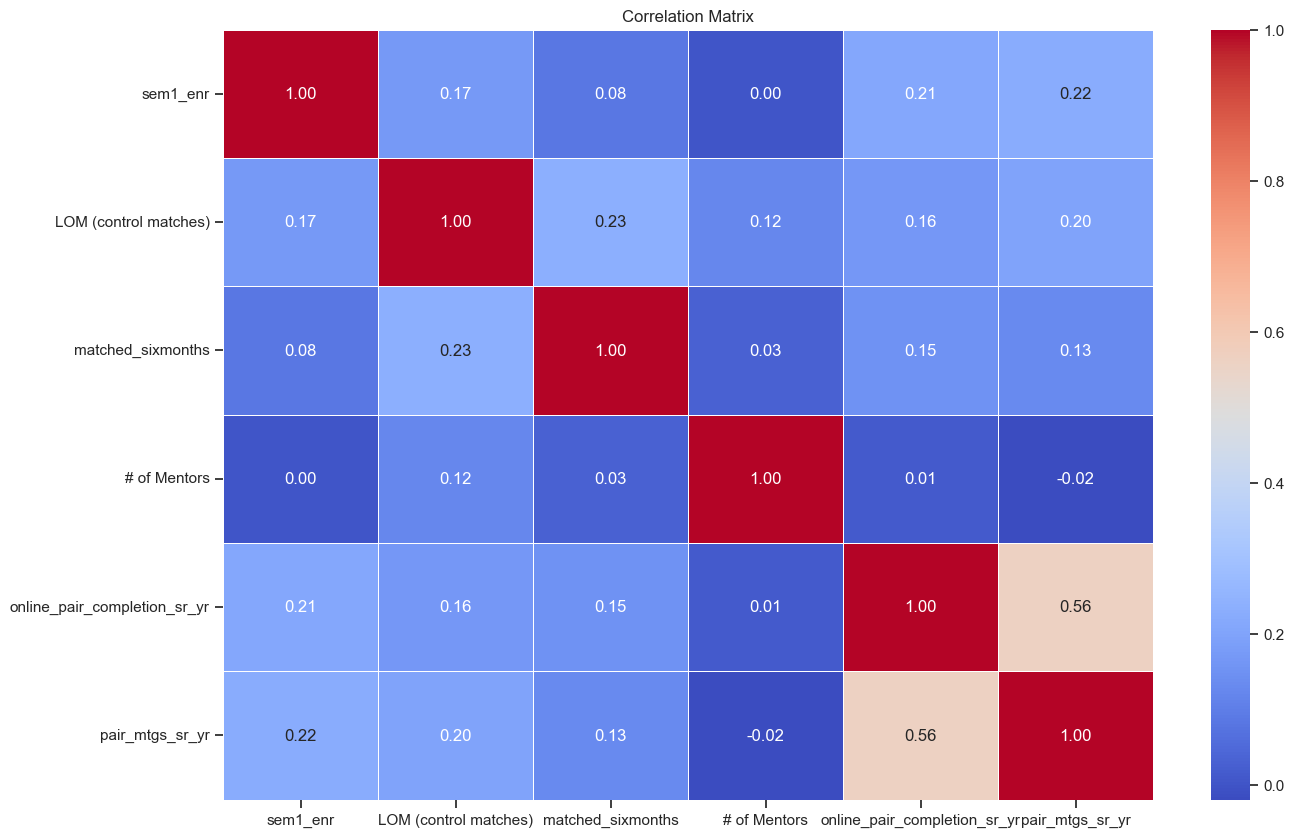

In [52]:
# Calculate the correlation matrix
corr_matrix = df[['sem1_enr', 'LOM (control matches)', 'matched_sixmonths', '# of Mentors', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr']].corr()

# Create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

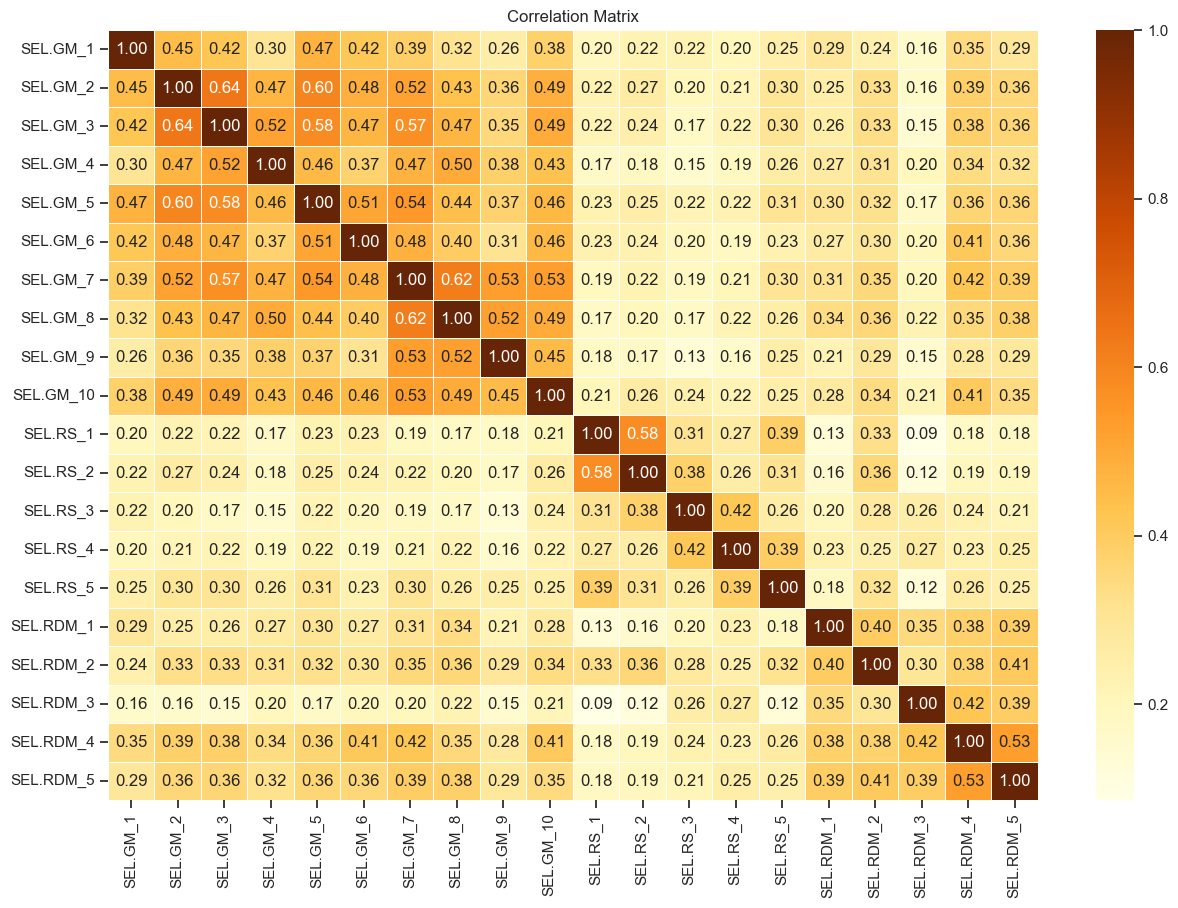

In [53]:
# Calculate the correlation matrix
corr_matrix = df.drop(columns = ['sem1_enr', 'LOM (control matches)', 'matched_sixmonths', '# of Mentors', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr']).select_dtypes(include=['float64', 'int64']).corr()

cmap = sns.color_palette("YlOrBr", as_cmap=True)

# Create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Step 4 - CRISP-DM: Data Modeling

Modeling Technique Chosen: Logistic Regression.
Why Logistic Regression? Logistic Regression is a type of machine learning predictive method that evaluates the probability of the outcome variable being classified as either 0 or 1, falling between 0 and 1 using the sigmoid function. Because the outcome variable in this project is a binary variable on whether the student had on-time college enrollment the semester after graduation from high school, the logistic regression method was chosen to classify each student into a 0 = did not enroll, or 1 = did enroll.


#### Assumptions
- Binary Response Variable - this is satisfied.
- Observations are independent - this is satisfied (removed all duplicates, each record is one observation individually collected)
- no extreme Multi-collinearity (this will be checked by VIF, but has been explored using the correlation plot, where the highest is 64%) - This has been satisfied to remove all VIF scores greater than or equal to 5.
- There are no extreme outliers (remove, replace, or leave in and explain) - these have already been addressed - satisfied.
- There is a Linear Relationship Between Explanatory Variables and the Logit of the Response Variable. (Box-tidwell test)
- The sample size must be sufficiently large. This can be checked with look at a 10 instances of a minimum case for each predictor variable.

In [54]:
df.head(10)

,user_id,cohort,Member,school,gender,race/ethnicity,LOM (control matches),matched_sixmonths,# of Mentors,online_pair_completion_sr_yr,...,SEL.RS_1,SEL.RS_2,SEL.RS_3,SEL.RS_4,SEL.RS_5,SEL.RDM_1,SEL.RDM_2,SEL.RDM_3,SEL.RDM_4,SEL.RDM_5
0,123456,2019,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1244,1,1,57,...,2,2,3,3,3,3,2,3,3,3
1,123457,2019,iMentor NYC,Rushmore Academy,Female,Hispanic (May be of any race),1500,1,2,68,...,3,2,3,3,2,2,3,3,3,3
2,123458,2019,iMentor NYC,Rushmore Academy,Male,Black / African American,1529,1,2,84,...,2,2,2,2,2,4,4,4,4,4
3,123459,2019,iMentor NYC,Rushmore Academy,Male,Hispanic (May be of any race),1552,1,3,92,...,4,3,4,3,2,3,3,3,3,3
4,123460,2019,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1580,1,2,95,...,2,2,3,2,1,3,3,3,3,3
5,123464,2019,iMentor NYC,Rushmore Academy,Female,Black / African American,1607,1,1,55,...,2,3,3,2,3,3,4,4,4,3
6,123465,2019,iMentor NYC,Rushmore Academy,Male,Black / African American,1480,1,2,81,...,4,2,4,3,4,4,3,4,4,4
7,123466,2019,iMentor NYC,Rushmore Academy,Female,I identify with a race not listed here,432,1,2,0,...,2,3,2,3,3,2,3,3,3,2
8,123467,2019,iMentor NYC,Rushmore Academy,Male,White (Non-Hispanic),1265,1,1,14,...,2,2,2,2,2,2,2,4,2,2
9,123468,2019,iMentor NYC,Rushmore Academy,Male,Hispanic (May be of any race),1608,1,1,95,...,4,4,4,4,4,4,4,4,4,4


##### Feature Engineering to Prepare for the Logisic Regression

In [55]:
# One-hot encode categorical variables
# this gets dummy variables for the cohort, Member, school, gneder, and Race/ethnicity columns, and drops the first column to preven multicollinearity.
df_encoded = pd.get_dummies(df, columns=['cohort', 'Member', 'school', 'gender', 'race/ethnicity', '# of Mentors'], drop_first=True, dtype=int)
df_features_engineered_non_standardized = df_encoded.copy()
df_encoded.head()


,user_id,LOM (control matches),matched_sixmonths,online_pair_completion_sr_yr,pair_mtgs_sr_yr,sem1_enr,SEL.GM_1,SEL.GM_2,SEL.GM_3,SEL.GM_4,...,race/ethnicity_Black / African American,race/ethnicity_Did not answer,race/ethnicity_Hispanic (May be of any race),race/ethnicity_I identify with a race not listed here,race/ethnicity_Multi-Racial,race/ethnicity_Native American (Aleutian Islander),race/ethnicity_White (Non-Hispanic),# of Mentors_2,# of Mentors_3,# of Mentors_4
0,123456,1244,1,57,1,0,2,3,3,3,...,0,0,0,0,0,0,0,0,0,0
1,123457,1500,1,68,7,1,3,2,2,3,...,0,0,1,0,0,0,0,1,0,0
2,123458,1529,1,84,8,1,4,4,4,4,...,1,0,0,0,0,0,0,1,0,0
3,123459,1552,1,92,4,1,3,3,3,3,...,0,0,1,0,0,0,0,0,1,0
4,123460,1580,1,95,8,1,3,3,3,3,...,0,0,0,0,0,0,0,1,0,0


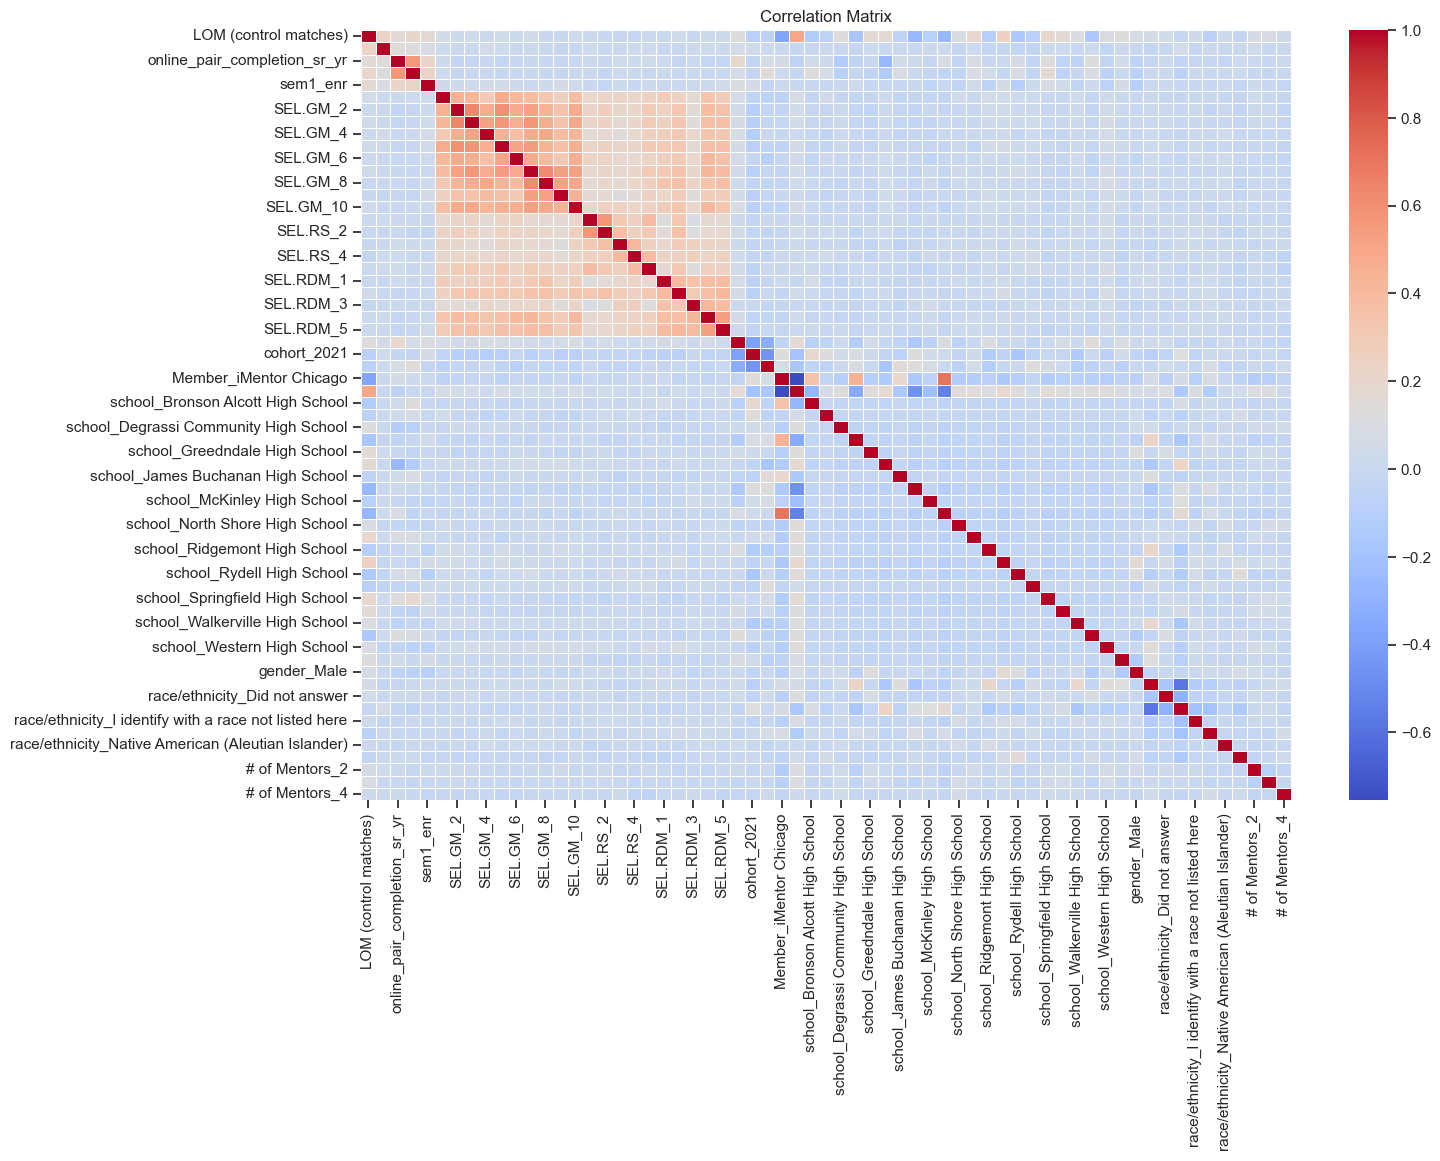

In [56]:
# Calculate the correlation matrix - check to see if there is multicollinearity.
corr_matrix = df_encoded.select_dtypes(include=['float64', 'int64']).corr()

# Create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Now that some features are engineered, I will look again at the bivariate statistics for some additional review.

In [57]:
import warnings

# warnings.filterwarnings('ignore')
bivariate_stats_logistic_option_2(df = df_encoded, label = 'sem1_enr')

,missing,p,coef,std_err,z,X2
LOM (control matches),0.00%,0.0000,0.0009,0.0001,7.9979,-
online_pair_completion_sr_yr,0.00%,0.0000,0.0134,0.0014,9.8356,-
pair_mtgs_sr_yr,0.00%,0.0000,0.1541,0.0146,10.5578,-
school_Rydell High School,0.00%,0.0000,-0.993,0.1991,-4.9887,-
gender_Male,0.00%,0.0000,-0.4139,0.0875,-4.7322,-
...,...,...,...,...,...,...
SEL.RS_4,0.00%,0.9543,-0.0034,0.0589,-0.0573,-
school_Degrassi Community High School,0.00%,0.9620,0.0104,0.2186,0.0476,-
race/ethnicity_Multi-Racial,0.00%,0.9651,-0.0104,0.2367,-0.0438,-
SEL.RS_1,0.00%,0.9926,-0.0005,0.0496,-0.0093,-


Interestingly, now there are 21 statistically significant variables. A few to note here are:
- school_Rydeel High School
- gender_Male
- school_Springfield High School
- school_Western High School
- cohort_2021
- school_Rushmore Academy
- school_Ridgemont High School
- school_Zyzzx High School
- school_MckInley High School
- school_North Shore High School
- school_Walkerville High School
- school_Third Street High School

These additionally significant variables coincide exactly with the t-test and ANOVA testing for statistical significance between samples of the population for variables such as cohort, school, and gender during the EDA phase.

From the heatmap, it looks like there could be some multicollinearity within the SEL Outcomes. I will check now using the VIF scores.

In [58]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296 entries, 0 to 2295
Data columns (total 64 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   user_id                                                2296 non-null   object
 1   LOM (control matches)                                  2296 non-null   int64 
 2   matched_sixmonths                                      2296 non-null   int64 
 3   online_pair_completion_sr_yr                           2296 non-null   int64 
 4   pair_mtgs_sr_yr                                        2296 non-null   int64 
 5   sem1_enr                                               2296 non-null   int64 
 6   SEL.GM_1                                               2296 non-null   int64 
 7   SEL.GM_2                                               2296 non-null   int64 
 8   SEL.GM_3                                               229

In [59]:
df_encoded = df_encoded.drop(columns = ['user_id'])
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296 entries, 0 to 2295
Data columns (total 63 columns):
 #   Column                                                 Non-Null Count  Dtype
---  ------                                                 --------------  -----
 0   LOM (control matches)                                  2296 non-null   int64
 1   matched_sixmonths                                      2296 non-null   int64
 2   online_pair_completion_sr_yr                           2296 non-null   int64
 3   pair_mtgs_sr_yr                                        2296 non-null   int64
 4   sem1_enr                                               2296 non-null   int64
 5   SEL.GM_1                                               2296 non-null   int64
 6   SEL.GM_2                                               2296 non-null   int64
 7   SEL.GM_3                                               2296 non-null   int64
 8   SEL.GM_4                                               2296 non-null

#### Standardize the data for the logistic regression model, continuous numeric features only that are not on the same scale as the survey data.

In [60]:
from sklearn.preprocessing import StandardScaler

# Identify continuous numerical features
continuous_features = ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr']

# Initialize the scaler
scaler = StandardScaler()

# Standardize only numerical features
df_encoded[continuous_features] = scaler.fit_transform(df_encoded[continuous_features])
df_encoded


,LOM (control matches),matched_sixmonths,online_pair_completion_sr_yr,pair_mtgs_sr_yr,sem1_enr,SEL.GM_1,SEL.GM_2,SEL.GM_3,SEL.GM_4,SEL.GM_5,...,race/ethnicity_Black / African American,race/ethnicity_Did not answer,race/ethnicity_Hispanic (May be of any race),race/ethnicity_I identify with a race not listed here,race/ethnicity_Multi-Racial,race/ethnicity_Native American (Aleutian Islander),race/ethnicity_White (Non-Hispanic),# of Mentors_2,# of Mentors_3,# of Mentors_4
0,0.663966,1,0.124822,-0.968025,0,2,3,3,3,3,...,0,0,0,0,0,0,0,0,0,0
1,1.316637,1,0.463292,0.823420,1,3,2,2,3,2,...,0,0,1,0,0,0,0,1,0,0
2,1.390573,1,0.955612,1.121994,1,4,4,4,4,4,...,1,0,0,0,0,0,0,1,0,0
3,1.449211,1,1.201772,-0.072303,1,3,3,3,3,3,...,0,0,1,0,0,0,0,0,1,0
4,1.520597,1,1.294082,1.121994,1,3,3,3,3,3,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,-1.266005,1,-1.629067,-1.266599,0,4,4,4,4,4,...,0,1,0,0,0,0,0,0,0,0
2292,-1.041649,1,1.447932,-0.370877,1,4,4,4,4,4,...,1,0,0,0,0,0,0,0,0,0
2293,-1.342490,1,-1.629067,-1.266599,0,2,3,4,4,3,...,1,0,0,0,0,0,0,0,0,0
2294,-0.669422,1,-0.613658,-0.072303,1,2,3,3,3,3,...,1,0,0,0,0,0,0,0,0,0


In [61]:
def vif(df, label):
  # Testing for multicollinearity
  import statsmodels.api as sm

  # Create a blank DataFrame to store the results
  df_vif = pd.DataFrame(columns=['VIF'])

  # Loop through the X features only to generate VIF score for each
  for col in df.drop(columns=['sem1_enr']):
    y = df[col] # Each X feature takes a turn being the y
    # All remaining X features are used to predict that y
    X = df.drop(columns=[col, f'{label}']).assign(const=1)

    r_squared = sm.OLS(y, X).fit().rsquared # Record the R squared from the model
    df_vif.loc[col] = [1/(1 - r_squared)]

  # Print out the list of VIF scores sorted from highest (worst) to lowest (best)
  df_vif.sort_values(by=['VIF'], ascending=False, inplace=True)
  return df_vif

In [62]:
vif(df = df_encoded, label = 'sem1_enr')

,VIF
school_Mechanicville High School,inf
school_McKinley High School,inf
Member_iMentor Chicago,inf
Member_iMentor NYC,inf
school_Bronson Alcott High School,inf
...,...
gender_Male,1.144670
race/ethnicity_Native American (Aleutian Islander),1.091309
# of Mentors_2,1.067905
# of Mentors_3,1.054231


In [63]:
import pandas as pd
import statsmodels.api as sm

def calculate_vif(df, label):
    df_vif = pd.DataFrame(columns=['VIF'])
    for col in df.drop(columns=[label]):
        y = df[col]
        X = df.drop(columns=[col, label]).assign(const=1)
        r_squared = sm.OLS(y, X).fit().rsquared
        if r_squared < 1:
            df_vif.loc[col] = [1 / (1 - r_squared)]
        else:
            df_vif.loc[col] = [float('inf')]
    return df_vif

def iterative_vif_removal(df, label, threshold=5):
    while True:
        df_vif = calculate_vif(df, label)
        df_vif.sort_values(by=['VIF'], ascending=False, inplace=True)
        max_vif = df_vif.iloc[0]
        if max_vif['VIF'] > threshold:
            feature_to_remove = df_vif.index[0]
            print(f"Removing feature '{feature_to_remove}' with VIF = {max_vif['VIF']}")
            df = df.drop(columns=[feature_to_remove])
        else:
            break
    return df, df_vif

# Use the iterative process on your dataset
df_cleaned, final_vif = iterative_vif_removal(df_encoded, 'sem1_enr', threshold=5)

# Display the final VIF scores
final_vif

Removing feature 'school_Mechanicville High School' with VIF = inf
Removing feature 'school_McKinley High School' with VIF = inf
Removing feature 'Member_iMentor NYC' with VIF = 15.418937972406896
Removing feature 'race/ethnicity_Hispanic (May be of any race)' with VIF = 5.586799915003286


,VIF
Member_iMentor Chicago,3.989908
cohort_2021,3.647085
cohort_2022,3.475546
LOM (control matches),2.954396
school_Rushmore Academy,2.884408
school_Hogwarts School of Wizardry and Withcraft,2.834310
cohort_2020,2.711587
SEL.GM_7,2.376295
SEL.GM_3,2.237720
school_Springfield High School,2.183901


In [64]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296 entries, 0 to 2295
Data columns (total 59 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   LOM (control matches)                                  2296 non-null   float64
 1   matched_sixmonths                                      2296 non-null   int64  
 2   online_pair_completion_sr_yr                           2296 non-null   float64
 3   pair_mtgs_sr_yr                                        2296 non-null   float64
 4   sem1_enr                                               2296 non-null   int64  
 5   SEL.GM_1                                               2296 non-null   int64  
 6   SEL.GM_2                                               2296 non-null   int64  
 7   SEL.GM_3                                               2296 non-null   int64  
 8   SEL.GM_4                                        

In [65]:
vif(df = df_cleaned, label = 'sem1_enr')

,VIF
Member_iMentor Chicago,3.989908
cohort_2021,3.647085
cohort_2022,3.475546
LOM (control matches),2.954396
school_Rushmore Academy,2.884408
school_Hogwarts School of Wizardry and Withcraft,2.834310
cohort_2020,2.711587
SEL.GM_7,2.376295
SEL.GM_3,2.237720
school_Springfield High School,2.183901


All VIF Scores are now under 5, meaning the assumption for multicollinearity removal has been satisfied.

##### Test for Linear Relationship - Between Explanatory Variables and the Logit of the Response Variable. (Box-tidwell test)


In [66]:
df_cleaned

,LOM (control matches),matched_sixmonths,online_pair_completion_sr_yr,pair_mtgs_sr_yr,sem1_enr,SEL.GM_1,SEL.GM_2,SEL.GM_3,SEL.GM_4,SEL.GM_5,...,gender_Male,race/ethnicity_Black / African American,race/ethnicity_Did not answer,race/ethnicity_I identify with a race not listed here,race/ethnicity_Multi-Racial,race/ethnicity_Native American (Aleutian Islander),race/ethnicity_White (Non-Hispanic),# of Mentors_2,# of Mentors_3,# of Mentors_4
0,0.663966,1,0.124822,-0.968025,0,2,3,3,3,3,...,1,0,0,0,0,0,0,0,0,0
1,1.316637,1,0.463292,0.823420,1,3,2,2,3,2,...,0,0,0,0,0,0,0,1,0,0
2,1.390573,1,0.955612,1.121994,1,4,4,4,4,4,...,1,1,0,0,0,0,0,1,0,0
3,1.449211,1,1.201772,-0.072303,1,3,3,3,3,3,...,1,0,0,0,0,0,0,0,1,0
4,1.520597,1,1.294082,1.121994,1,3,3,3,3,3,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,-1.266005,1,-1.629067,-1.266599,0,4,4,4,4,4,...,0,0,1,0,0,0,0,0,0,0
2292,-1.041649,1,1.447932,-0.370877,1,4,4,4,4,4,...,0,1,0,0,0,0,0,0,0,0
2293,-1.342490,1,-1.629067,-1.266599,0,2,3,4,4,3,...,0,1,0,0,0,0,0,0,0,0
2294,-0.669422,1,-0.613658,-0.072303,1,2,3,3,3,3,...,0,1,0,0,0,0,0,0,0,0


Creating the Logistic Regression Model, Fitting the Model on all data, and looking at the model fit.

In [67]:
import statsmodels.api as sm

#  df_cleaned is the cleaned DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Fit logistic regression model
model = sm.Logit(y, X).fit()

# Display model summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.581118
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               sem1_enr   No. Observations:                 2296
Model:                          Logit   Df Residuals:                     2237
Method:                           MLE   Df Model:                           58
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                  0.1108
Time:                        15:09:11   Log-Likelihood:                -1334.2
converged:                       True   LL-Null:                       -1500.5
Covariance Type:            nonrobust   LLR p-value:                 3.747e-40
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
const                 

Optimization terminated successfully.
         Current function value: 0.581118
         Iterations 6
Confusion Matrix:
[[ 312  515]
 [ 171 1298]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.38      0.48       827
           1       0.72      0.88      0.79      1469

    accuracy                           0.70      2296
   macro avg       0.68      0.63      0.63      2296
weighted avg       0.69      0.70      0.68      2296



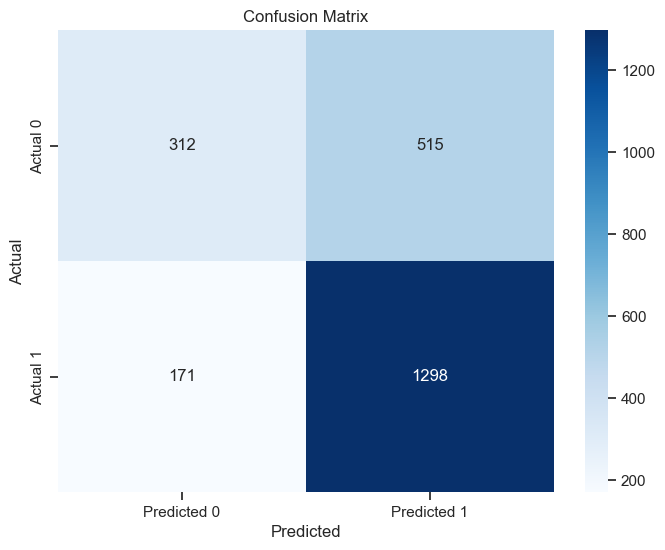

In [68]:
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df_cleaned is the cleaned, encoded, and DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Fit logistic regression model
model = sm.Logit(y, X).fit()

# Make predictions
y_pred_prob = model.predict(X)
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions

# Create confusion matrix
conf_matrix = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y, y_pred)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [69]:
df_results = pd.DataFrame(columns = ['y_pred', 'y_actual', 'y_pred_prob'])
df_results['y_pred_prob'] = y_pred_prob
df_results['y_pred'] = y_pred
df_results['y_actual'] = y
df_results

,y_pred,y_actual,y_pred_prob
0,1,0,0.602650
1,1,1,0.815943
2,1,1,0.892301
3,1,1,0.761428
4,1,1,0.840589
...,...,...,...
2291,1,0,0.686724
2292,1,1,0.850239
2293,1,0,0.604711
2294,1,1,0.807606


#### ROC Curve Only on the Trained Model Using 100% of the Data - not split

Remember: True Positive Rate = Sensitivity = Recall.

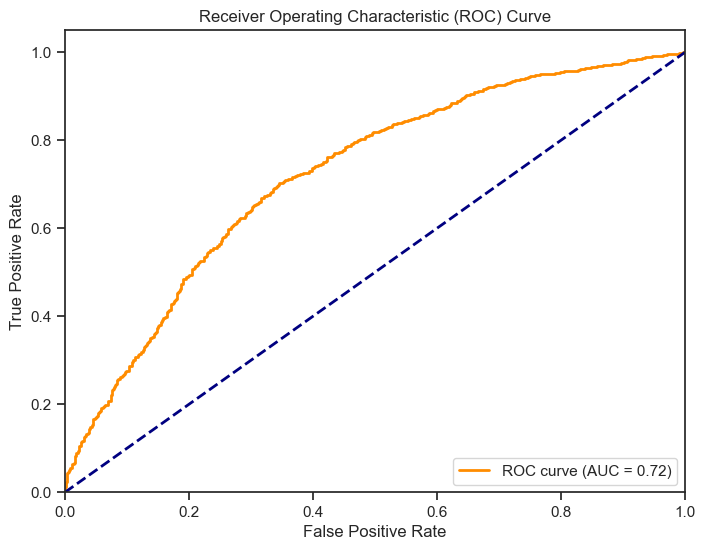

In [70]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

So this model has an AUC of 0.72, and an overall accuracy score of 70. The f1 Score for class = 1 is 79 and the F1 score for class = 0 is 48. What this means is that the dataset is predicting well on training data, using all variables that do not have too high of multicollinearity. Additionally, one thing to note is that this model is overfit, since the p-values in the dataset do not contribute statistical significace to the outcome logit relationship variable of sem1_enr.

## Step 5 CRISP-DM: Model Evaluation

I am going to start by looking at the ROC Curve to look at the tradeoffs between the true positive rate and false positive rate.

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
# X = df_cleaned.drop(columns=['sem1_enr'])
# X = sm.add_constant(X)  # Add constant term
# y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

LR = LogisticRegression(C = 0.01, solver = 'liblinear')
LR.fit(X_train, y_train)


LogisticRegression(C=0.01, solver='liblinear')

In [72]:
y_pred = LR.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,

__predict_proba__  returns estimates for all classes, ordered by the label of classes. So, the first column is the probability of class 0, P(Y=0|X), and second column is probability of class 1, P(Y=1|X):


In [73]:
y_pred_prob = LR.predict_proba(X_test)[:, 1]
y_pred_prob

array([0.47292737, 0.71051723, 0.75133442, 0.76214853, 0.49243792,
       0.82468453, 0.63888976, 0.76278105, 0.84167603, 0.64707664,
       0.51883741, 0.63861546, 0.80507809, 0.50219655, 0.64688172,
       0.65944536, 0.61546264, 0.65519401, 0.5885924 , 0.65752358,
       0.46609492, 0.74579572, 0.73160943, 0.61924258, 0.64689046,
       0.8214379 , 0.61074944, 0.53010637, 0.38821223, 0.32189035,
       0.59964356, 0.77698347, 0.35217166, 0.60760682, 0.48818575,
       0.65491271, 0.65206203, 0.45718625, 0.6748083 , 0.85924673,
       0.66334121, 0.79861544, 0.8116737 , 0.71629286, 0.72996449,
       0.73893126, 0.52826016, 0.70778623, 0.82326425, 0.65446414,
       0.69153642, 0.5599993 , 0.40295324, 0.625579  , 0.38583755,
       0.83039964, 0.42458638, 0.60028528, 0.74861696, 0.65606871,
       0.55513524, 0.72738941, 0.73392726, 0.53909473, 0.52979503,
       0.71463483, 0.73745949, 0.67427669, 0.62440814, 0.61974053,
       0.47615308, 0.7523532 , 0.41095701, 0.31700821, 0.58800

Confusion Matrix:
[[ 53 137]
 [ 17 253]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.28      0.41       190
           1       0.65      0.94      0.77       270

    accuracy                           0.67       460
   macro avg       0.70      0.61      0.59       460
weighted avg       0.69      0.67      0.62       460



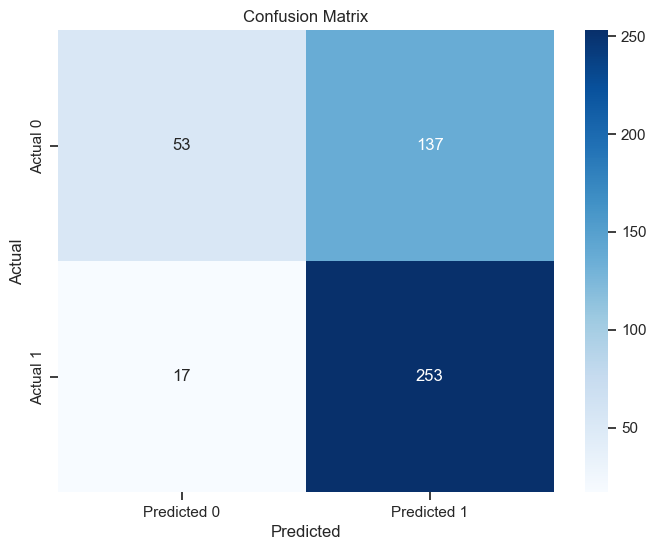

In [74]:
# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### ROC Curve

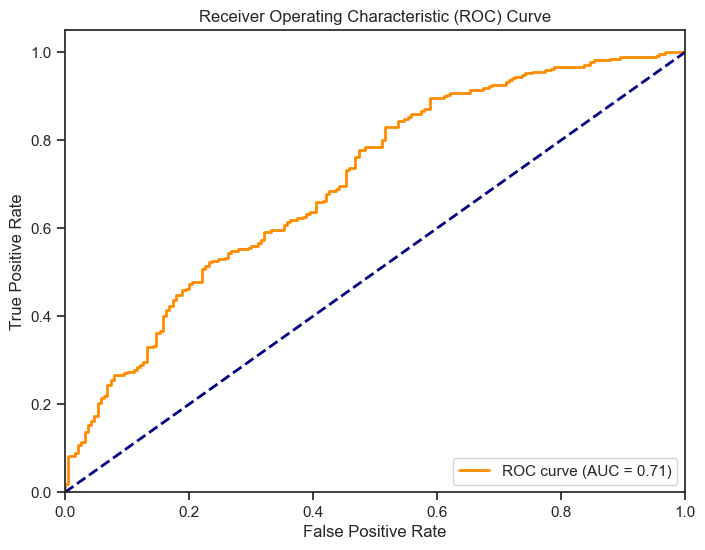

In [75]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

With an 80/20 split using the train, test, split for model validation and evaluation, we have a ROC curve with an AUC value of 0.71. The closer to 1.0, the better the model is performing. Interestingly here, with a 20% test dataset, the model still predicts almost as accurately with a 67 for overall accuracy on the test data rather than a 70 on just the training data. However, the model may still be overfit with non-statistically significant predictors of the outcome variable, even if they are contributing to overall model accuracy.

### jaccard index
Let's try the jaccard index for accuracy evaluation. we can define jaccard as the size of the intersection divided by the size of the union of the two label sets. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.



In [76]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, y_pred, pos_label=0)

0.2560386473429952

### Using Class Weights for balancing the imbalanced dataset with sem1_enr = 0 underrepresented.

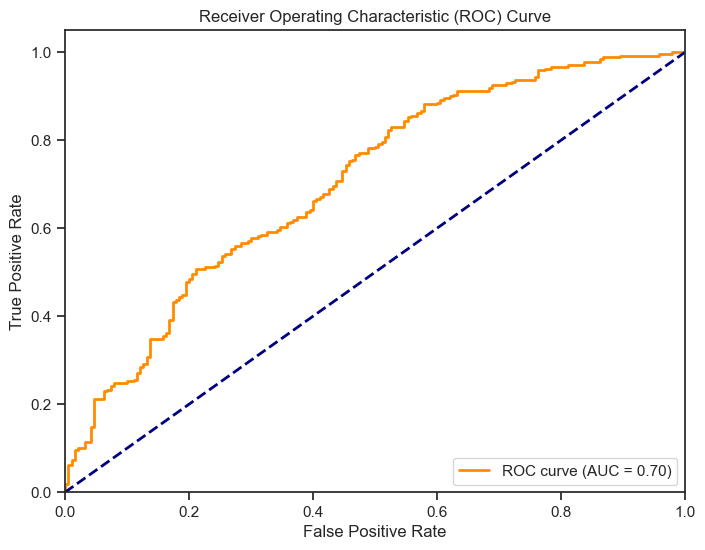

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# train the model using balanced class weights
LR = LogisticRegression(C = 0.01, class_weight = 'balanced', solver = 'liblinear')
LR.fit(X_train, y_train)

# make predictions & get the probabilities.
y_pred = LR.predict(X_test)
y_pred_prob = LR.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Corrected now for class imbalance, the model can predict with AUC 0.70 on the test set.

Confusion Matrix:
[[114  76]
 [ 97 173]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.60      0.57       190
           1       0.69      0.64      0.67       270

    accuracy                           0.62       460
   macro avg       0.62      0.62      0.62       460
weighted avg       0.63      0.62      0.63       460



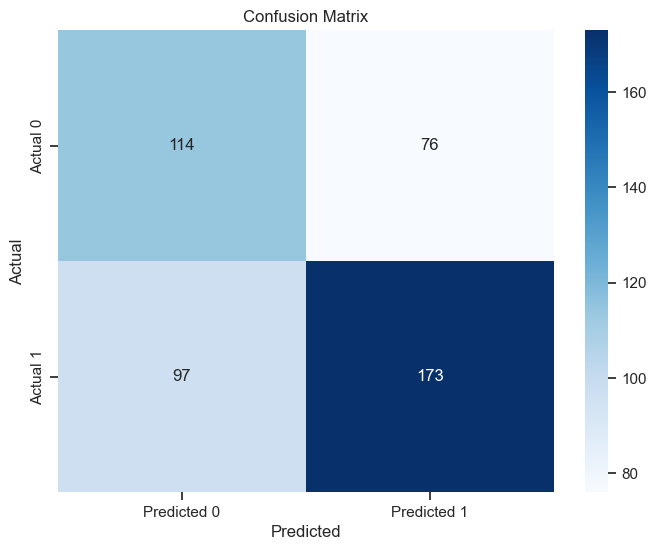

In [78]:
# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

PR AUC: 0.7540306334373253


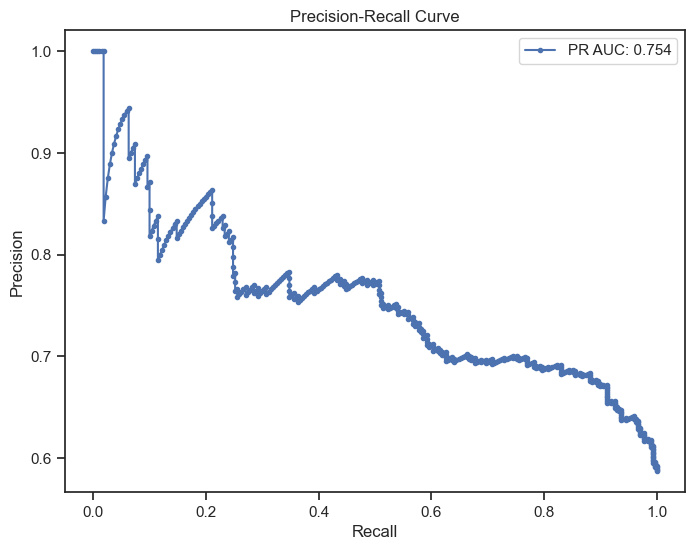

In [79]:
from sklearn.metrics import precision_recall_curve

# Calculate precision-recall curve and AUC
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC: {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

#### Logistic Regression, Class Balanced, with Threshold Shift
Instead of a threshold set at 0.50 for classifying to 0 or 1 based on the predicted probability, the threshold will be set using a Precision-Recall curve (Prasad, 2025).

Prasad, N. (2025, March 15). Handling imbalanced dataset in ML. Epochs of Data Insights. https://analyticalnikita.substack.com/p/handling-imbalanced-dataset-in-ml

"Other metrics, such as the Precision-Recall (PR) curve helps identify a threshold that works best for the dataset, as it gives more emphasis on how many predictions the model got right out of the total number it predicted to be positive, which is helpful when dealing with imbalanced data sets."



### Lasso Regression w/Class Balancing

In [80]:
# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Fit logistic regression model with L1 regularization
log_reg_l1 = LogisticRegression(penalty='l1', class_weight = 'balanced', C=0.01, solver='liblinear')
log_reg_l1.fit(X_train, y_train)

# Get non-zero coefficients (important features)
selected_features = X_train.columns[log_reg_l1.coef_[0] != 0]
print("Selected Features:", selected_features.tolist())


Selected Features: ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr']


Fit Model Summary on Training Dataset using Lasso Regularizaton

In [81]:
# Create a new DataFrame with only the selected features
X_train_selected = X_train[selected_features]
X_train_selected = sm.add_constant(X_train_selected)  # Add constant term

# Fit the Logit model using statsmodels
logit_model = sm.Logit(y_train, X_train_selected).fit()

# Print the summary
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.612657
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               sem1_enr   No. Observations:                 1836
Model:                          Logit   Df Residuals:                     1832
Method:                           MLE   Df Model:                            3
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.05094
Time:                        15:09:12   Log-Likelihood:                -1124.8
converged:                       True   LL-Null:                       -1185.2
Covariance Type:            nonrobust   LLR p-value:                 5.348e-26
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.6736      0.051     13.142      0.000

The Lasso L1 regularization for feature selection only chose 3 predictor variables. However, I will try with a slighly less stringent C = 0.05 for feature selection.

In [82]:
# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Fit logistic regression model with L1 regularization
log_reg_l1 = LogisticRegression(penalty='l1', class_weight = 'balanced', C=0.05, solver='liblinear')
log_reg_l1.fit(X_train, y_train)

# Get non-zero coefficients (important features)
selected_features = X_train.columns[log_reg_l1.coef_[0] != 0]
print("Selected Features:", selected_features.tolist())

# Create a new DataFrame with only the selected features
X_train_selected = X_train[selected_features]
X_train_selected = sm.add_constant(X_train_selected)  # Add constant term

# Fit the Logit model using statsmodels
logit_model = sm.Logit(y_train, X_train_selected).fit()

# Print the summary
print(logit_model.summary())


Selected Features: ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_4', 'SEL.GM_9', 'SEL.RS_2', 'SEL.RDM_2', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Optimization terminated successfully.
         Current function value: 0.595133
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               sem1_enr   No. Observations:                 1836
Model:                          Logit   Df Residuals:                     1824
Method:                           MLE   Df Model:                           11
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.07808
Time:                        15:09:12   Log-Likelihood:                -1092.7
converged:                       True   LL-Null:                       -1185.2
Covariance Type:            nonrobust   LLR p-value:                 9.126e-34
                                   coef    std 

With a C value of 0.05, only 2 features are left with insignificant p-values.

In [83]:
# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Fit logistic regression model with L1 regularization
log_reg_l1 = LogisticRegression(penalty='l1', class_weight = 'balanced', C=0.04, solver='liblinear')
log_reg_l1.fit(X_train, y_train)

# Get non-zero coefficients (important features)
selected_features = X_train.columns[log_reg_l1.coef_[0] != 0]
print("Selected Features:", selected_features.tolist())

# Create a new DataFrame with only the selected features
X_train_selected = X_train[selected_features]
X_train_selected = sm.add_constant(X_train_selected)  # Add constant term

# Fit the Logit model using statsmodels
logit_model = sm.Logit(y_train, X_train_selected).fit()

# Print the summary
print(logit_model.summary())


Selected Features: ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'gender_Male']
Optimization terminated successfully.
         Current function value: 0.600868
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               sem1_enr   No. Observations:                 1836
Model:                          Logit   Df Residuals:                     1828
Method:                           MLE   Df Model:                            7
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.06920
Time:                        15:09:12   Log-Likelihood:                -1103.2
converged:                       True   LL-Null:                       -1185.2
Covariance Type:            nonrobust   LLR p-value:                 4.548e-32
                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------

With a C value of 0.04, we now have left out 4 variables. Instead of using this, I will simply remove the one variable at a time, re-run the model, and check to see if all values are significant.

In [84]:
# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Fit logistic regression model with L1 regularization
log_reg_l1 = LogisticRegression(penalty='l1', class_weight = 'balanced', C=0.05, solver='liblinear')
log_reg_l1.fit(X_train, y_train)

# Get non-zero coefficients (important features)
selected_features = X_train.columns[log_reg_l1.coef_[0] != 0]
print("Selected Features:", selected_features.tolist())

# Create a new DataFrame with only the selected features
X_train_selected = X_train[['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_4', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']]
X_train_selected = sm.add_constant(X_train_selected)  # Add constant term

# Fit the Logit model using statsmodels
logit_model = sm.Logit(y_train, X_train_selected).fit()

# Print the summary
print(logit_model.summary())


Selected Features: ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_4', 'SEL.GM_9', 'SEL.RS_2', 'SEL.RDM_2', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Optimization terminated successfully.
         Current function value: 0.596067
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               sem1_enr   No. Observations:                 1836
Model:                          Logit   Df Residuals:                     1826
Method:                           MLE   Df Model:                            9
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.07663
Time:                        15:09:12   Log-Likelihood:                -1094.4
converged:                       True   LL-Null:                       -1185.2
Covariance Type:            nonrobust   LLR p-value:                 2.284e-34
                                   coef    std 

Now I will remove the SEL.GM_4

In [85]:
# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Fit logistic regression model with L1 regularization
log_reg_l1 = LogisticRegression(penalty='l1', class_weight = 'balanced', C=0.05, solver='liblinear')
log_reg_l1.fit(X_train, y_train)

# Get non-zero coefficients (important features)
selected_features = X_train.columns[log_reg_l1.coef_[0] != 0]
print("Selected Features:", selected_features.tolist())

# Create a new DataFrame with only the selected features
X_train_selected = X_train[['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']]
X_train_selected = sm.add_constant(X_train_selected)  # Add constant term

# Fit the Logit model using statsmodels
logit_model = sm.Logit(y_train, X_train_selected).fit()

# Print the summary
print(logit_model.summary())


Selected Features: ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_4', 'SEL.GM_9', 'SEL.RS_2', 'SEL.RDM_2', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Optimization terminated successfully.
         Current function value: 0.596833
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               sem1_enr   No. Observations:                 1836
Model:                          Logit   Df Residuals:                     1827
Method:                           MLE   Df Model:                            8
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.07545
Time:                        15:09:12   Log-Likelihood:                -1095.8
converged:                       True   LL-Null:                       -1185.2
Covariance Type:            nonrobust   LLR p-value:                 1.800e-34
                                   coef    std 

All variables are now statistically significant!

Overall Accuracy: 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.58      0.58       190
           1       0.70      0.70      0.70       270

    accuracy                           0.65       460
   macro avg       0.64      0.64      0.64       460
weighted avg       0.65      0.65      0.65       460



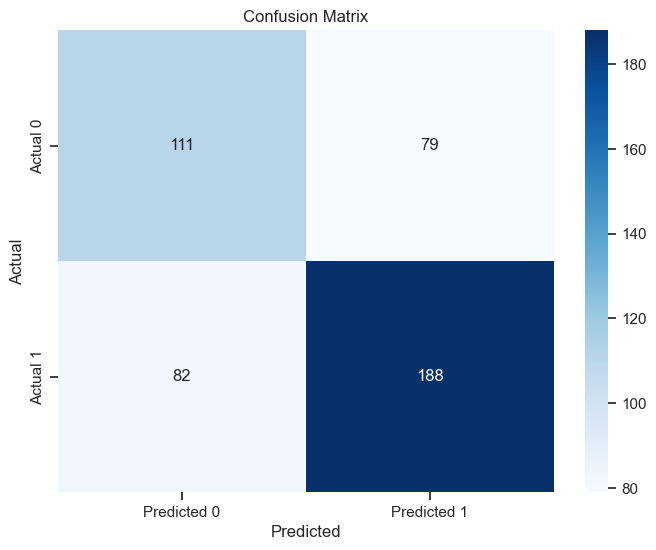

In [86]:
# only the manually created list of significant features.
selected_features = ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']

# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned[selected_features]
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Fit logistic regression model with L1 regularization
log_reg_l1 = LogisticRegression(penalty='l1', class_weight = 'balanced', C=0.05, solver='liblinear')

# refit the model using the selected features only.
log_reg_l1.fit(X_train, y_train)

# Make predictions using the logistic regression model with Lasso Regularization
y_pred_prob = log_reg_l1.predict_proba(X_test)[:, 1]
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
#print("Confusion Matrix:")
#print(conf_matrix)

#print the overall accuracy of the model
accuracy = (y_pred == y_test).mean()
print("Overall Accuracy:", accuracy)

# Print classification report for additional metrics
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

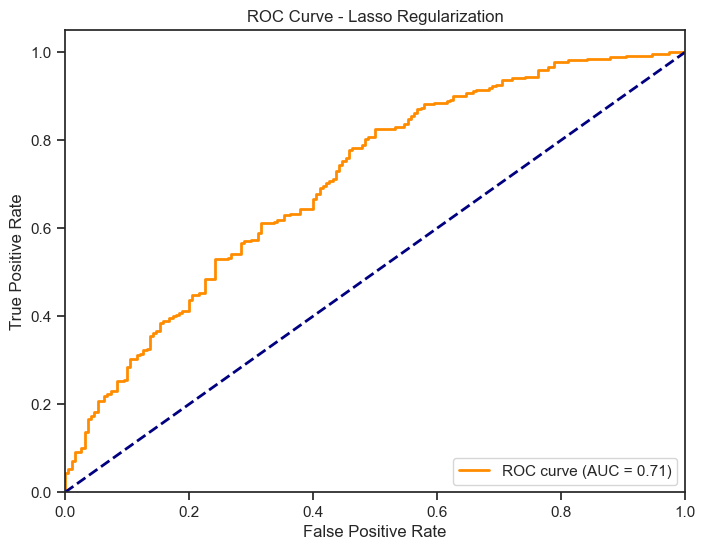

In [87]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Lasso Regularization')
plt.legend(loc='lower right')
plt.show()

PR AUC: 0.7591323860550754


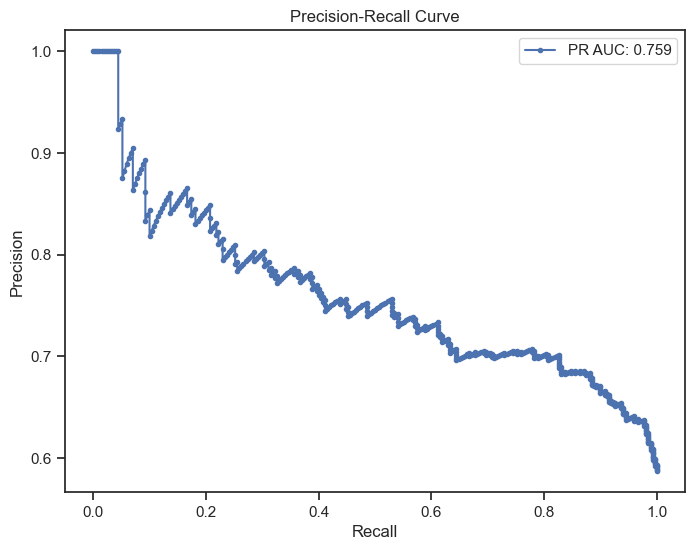

In [88]:
from sklearn.metrics import precision_recall_curve

# Calculate precision-recall curve and AUC
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC: {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

##### Confusion Matrix: Logistic Regression Model using Lasso Regularization - Predictions vs. Actual On Test Data

### Model Evaluation on Test Data with Train, Test, Split - Lasso Regularization 

Model Evaluation - k-Fold Cross Validation with Lasso Regularization

Average Accuracy: 0.6089

Fold 1 Confusion Matrix:
[[ 94  72]
 [106 188]]

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.63      0.55       165
           1       0.75      0.63      0.68       294

    accuracy                           0.63       459
   macro avg       0.62      0.63      0.62       459
weighted avg       0.66      0.63      0.63       459


Fold 2 Confusion Matrix:
[[102  64]
 [117 176]]

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.63      0.55       165
           1       0.75      0.63      0.68       294

    accuracy                           0.63       459
   macro avg       0.62      0.63      0.62       459
weighted avg       0.66      0.63      0.63       459


Fold 3 Confusion Matrix:
[[ 92  73]
 [127 167]]

Fold 3 Classification Report:
              precision    recall  f1-score   support

           0       0.49   

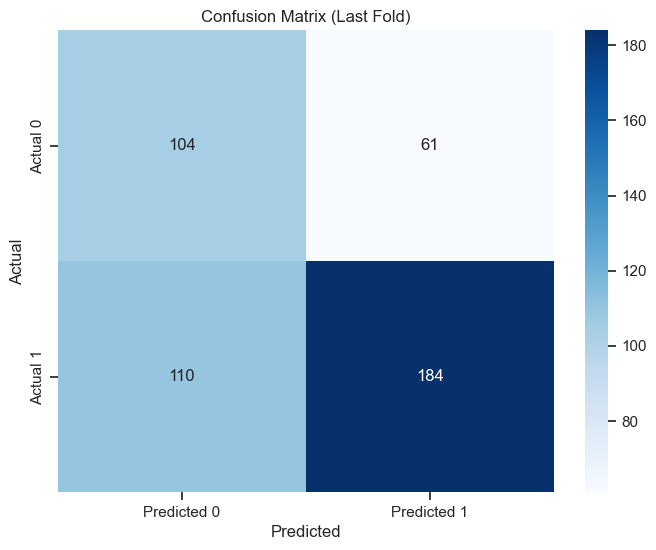

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold
import statsmodels.api as sm

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize StratifiedKFold with 5 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

# Lists to store evaluation metrics for each fold
accuracy_scores = []
conf_matrices = []
class_reports = []

# Iterate through each fold
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit logistic regression model with L1 regularization (Lasso)
    log_reg_l1 = LogisticRegression(penalty='l1', class_weight = 'balanced', C=0.01, solver='liblinear')
    log_reg_l1.fit(X_train, y_train)
    
    # Make predictions
    y_pred_prob = log_reg_l1.predict_proba(X_test)[:, 1]
    y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions
    
    # Evaluate the model
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))
    class_reports.append(classification_report(y_test, y_pred, output_dict=True))

# Print average accuracy
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")

# Print confusion matrices and classification reports for each fold
for i, (conf_matrix, class_report) in enumerate(zip(conf_matrices, class_reports)):
    print(f"\nFold {i+1} Confusion Matrix:")
    print(conf_matrix)
    print(f"\nFold {i+1} Classification Report:")
    print(classification_report(y_test, y_pred))

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrices[-1], annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Last Fold)')
plt.show()

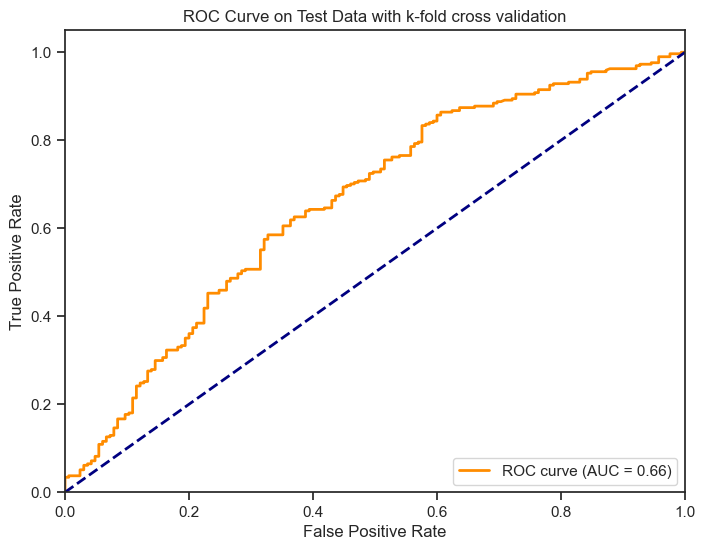

In [90]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Data with k-fold cross validation')
plt.legend(loc='lower right')
plt.show()

In [91]:
from sklearn.metrics import log_loss
log_loss(y_test, y_pred)

13.428027733200507

### k-fold cross-validation with Lasso regularization and selected features all with statistical significance.

- C Value of 0.05
- selected features chosen with only statistically significant features; 'LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male'
- 5 splits for the k-fold cross-validation
- balanced class weights

Selected Features: ['const', 'LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Selected Features: ['const', 'LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Selected Features: ['const', 'LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Selected Features: ['const', 'LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Selected Features: ['const', 'LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']
Average Accuracy: 0.6481

Fold 1 Confusion Ma

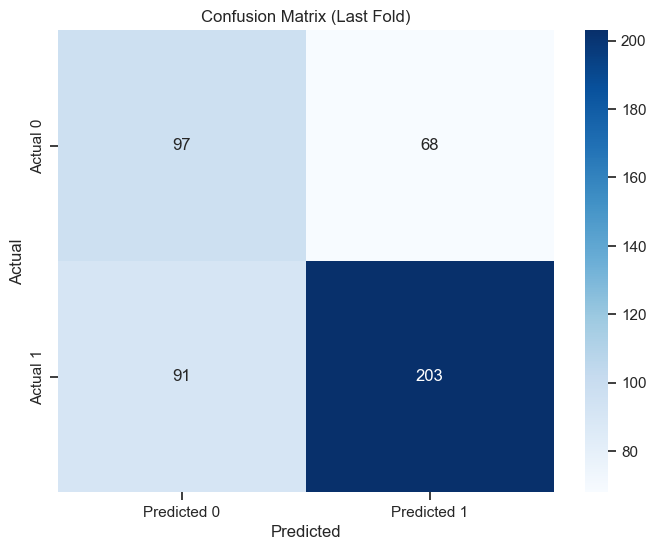

In [92]:
# only the manually created list of significant features.
selected_features = ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']

# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned[selected_features]
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize StratifiedKFold with 5 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

# Lists to store evaluation metrics for each fold
accuracy_scores = []
conf_matrices = []
class_reports = []

# store all the probabilities
y_pred_prob_all = []

# Iterate through each fold
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit logistic regression model with L1 regularization (Lasso)
    log_reg_l1 = LogisticRegression(class_weight = 'balanced', C=0.05, solver='liblinear')
    log_reg_l1.fit(X_train, y_train)

    # Get non-zero coefficients (important features)
    selected_features = X_train.columns[log_reg_l1.coef_[0] != 0]
    print("Selected Features:", selected_features.tolist())
    
    # Make predictions
    y_pred_prob = log_reg_l1.predict_proba(X_test)[:, 1]
    y_pred_prob_all.extend(y_pred_prob)
    y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions
    
    # Evaluate the model
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))
    class_reports.append(classification_report(y_test, y_pred, output_dict=True))

# Print average accuracy
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")

# Print confusion matrices and classification reports for each fold
for i, (conf_matrix, class_report) in enumerate(zip(conf_matrices, class_reports)):
    print(f"\nFold {i+1} Confusion Matrix:")
    print(conf_matrix)
    print(f"\nFold {i+1} Classification Report:")
    print(classification_report(y_test, y_pred))

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrices[-1], annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Last Fold)')
plt.show()

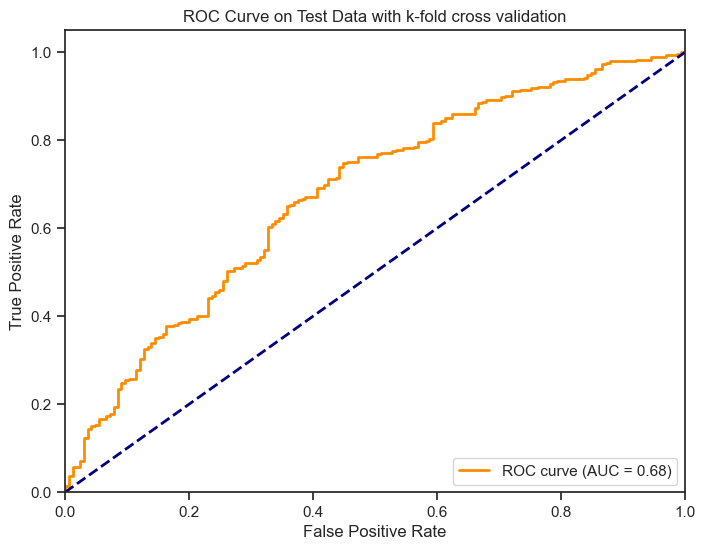

In [93]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Data with k-fold cross validation')
plt.legend(loc='lower right')
plt.show()

In [94]:
y_pred_prob_all

[0.36817599881951146,
 0.3637105304940615,
 0.22139960212780477,
 0.6234005686798761,
 0.5728300388713435,
 0.6185179338856752,
 0.19364032184686902,
 0.18367252193559983,
 0.2783478265520593,
 0.656749447088763,
 0.5228026534599755,
 0.3800684373218172,
 0.46392563653776914,
 0.3137719370257358,
 0.6104678169034543,
 0.2587213747450522,
 0.6553268350522529,
 0.5660222823419482,
 0.5920467530024982,
 0.509206312813799,
 0.325818945973098,
 0.3619949990100031,
 0.28060577970398337,
 0.20856780605293676,
 0.27160218829555727,
 0.24242060618576866,
 0.3286100086672235,
 0.48704385860088883,
 0.3630127073358968,
 0.32777982340324824,
 0.45714317272098726,
 0.48060767193324627,
 0.4951022201777931,
 0.2451562949678243,
 0.5206815269800953,
 0.6879602230801116,
 0.6264186313437958,
 0.6344040149512055,
 0.5348083364099352,
 0.32805366336769076,
 0.5143787763149359,
 0.25138859158944293,
 0.6473969775232588,
 0.23137381805250865,
 0.5519861431218456,
 0.13410354098422975,
 0.3273510494299343,

#### ANALYSIS - K-Fold Cross-Validation, Lasso Regularization, Logistic Regression, Features Selected

### Model Evaluation - Train, Test, Split - Ridge Regularization

Confusion Matrix:
[[114  76]
 [ 97 173]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.60      0.57       190
           1       0.69      0.64      0.67       270

    accuracy                           0.62       460
   macro avg       0.62      0.62      0.62       460
weighted avg       0.63      0.62      0.63       460



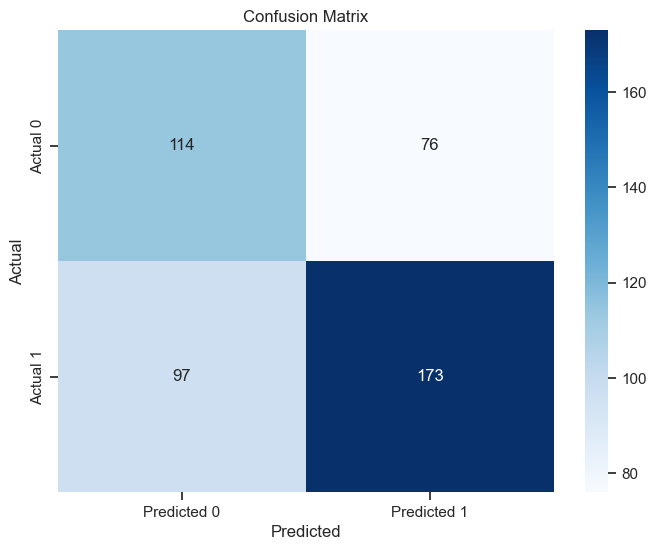

In [95]:
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Fit logistic regression model with L2 regularization (Ridge)
log_reg_l2 = LogisticRegression(penalty='l2', class_weight = 'balanced', C=0.01, solver='liblinear')
log_reg_l2.fit(X_train, y_train)

# Make predictions using the logistic regression model with Ridge Regularization
y_pred_prob = log_reg_l2.predict_proba(X_test)[:, 1]
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Model Evaluation - k-fold cross-validation with Ridge Regularization & Balanced Class

Average Accuracy: 0.6446

Fold 1 Confusion Matrix:
[[ 92  74]
 [ 96 198]]

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.57      0.53       165
           1       0.74      0.68      0.71       294

    accuracy                           0.64       459
   macro avg       0.62      0.62      0.62       459
weighted avg       0.65      0.64      0.64       459


Fold 2 Confusion Matrix:
[[ 99  67]
 [ 96 197]]

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.57      0.53       165
           1       0.74      0.68      0.71       294

    accuracy                           0.64       459
   macro avg       0.62      0.62      0.62       459
weighted avg       0.65      0.64      0.64       459


Fold 3 Confusion Matrix:
[[ 91  74]
 [100 194]]

Fold 3 Classification Report:
              precision    recall  f1-score   support

           0       0.50   

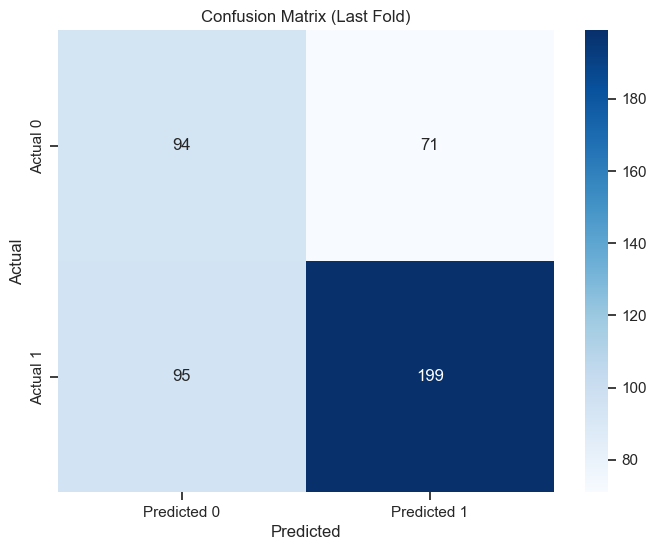

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold
import statsmodels.api as sm

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize StratifiedKFold with 5 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

# Lists to store evaluation metrics for each fold
accuracy_scores = []
conf_matrices = []
class_reports = []

# Iterate through each fold
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit logistic regression model with L2 regularization (Ridge)
    log_reg_l2 = LogisticRegression(penalty='l2', class_weight = 'balanced', C=0.01, solver='liblinear')
    log_reg_l2.fit(X_train, y_train)
    
    # Make predictions
    y_pred_prob = log_reg_l2.predict_proba(X_test)[:, 1]
    y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions
    
    # Evaluate the model
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))
    class_reports.append(classification_report(y_test, y_pred, output_dict=True))

# Print average accuracy
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")

# Print confusion matrices and classification reports for each fold
for i, (conf_matrix, class_report) in enumerate(zip(conf_matrices, class_reports)):
    print(f"\nFold {i+1} Confusion Matrix:")
    print(conf_matrix)
    print(f"\nFold {i+1} Classification Report:")
    print(classification_report(y_test, y_pred))

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrices[-1], annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Last Fold)')
plt.show()

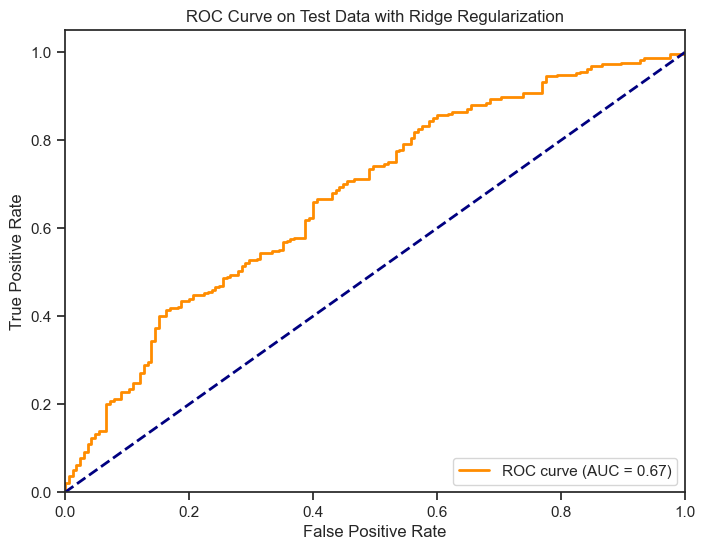

In [97]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Data with Ridge Regularization')
plt.legend(loc='lower right')
plt.show()

### Choosing the Ideal Threshold

In [98]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

# Find the best threshold: maximizing recall while keeping precision decent
best_index = np.argmax(recall - (1 - precision))  # Balance recall & precision
best_threshold = thresholds[best_index]

print(f"Optimal Threshold: {best_threshold:.3f}")


PR AUC: 0.7693152937061785
Optimal Threshold: 0.191


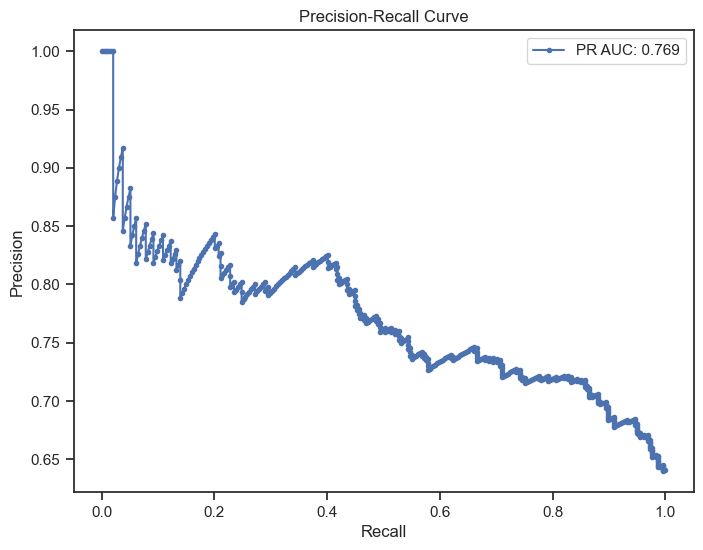

In [99]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC: {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


#### K-fold cross-validation with Elastic Nets and balanced class Logistic Regression

I will use GridSearchCV to also tune the hyperparameters to find the ideal l1_ratio and the best C value.

Best parameters found: {'C': 1, 'l1_ratio': 0.75}
Average Accuracy: 0.6529

Fold 1 Confusion Matrix:
[[100  66]
 [100 194]]

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.59      0.54       165
           1       0.74      0.66      0.70       294

    accuracy                           0.64       459
   macro avg       0.62      0.63      0.62       459
weighted avg       0.65      0.64      0.64       459


Fold 2 Confusion Matrix:
[[101  65]
 [ 91 202]]

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.59      0.54       165
           1       0.74      0.66      0.70       294

    accuracy                           0.64       459
   macro avg       0.62      0.63      0.62       459
weighted avg       0.65      0.64      0.64       459


Fold 3 Confusion Matrix:
[[109  56]
 [106 188]]

Fold 3 Classification Report:
              precision    reca

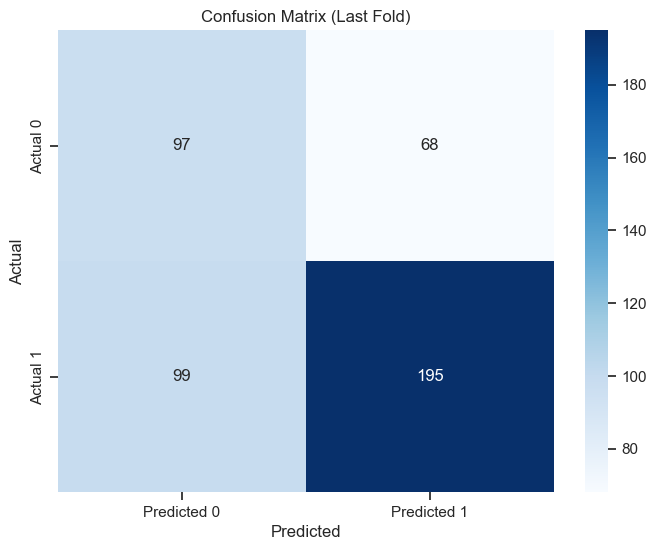

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import statsmodels.api as sm

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize StratifiedKFold with 5 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

# Define the parameter grid for l1_ratio and C
param_grid = {
    'l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
    'C': [0.001, 0.01, 0.05, 0.1, 1, 10, 100]
}

# Initialize the logistic regression model with elastic net regularization
log_reg_en = LogisticRegression(penalty='elasticnet', class_weight='balanced', solver='saga', max_iter=10000)

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg_en, param_grid, cv=kf, scoring='accuracy', n_jobs=-1)

# Fit the model using grid search
grid_search.fit(X, y)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Lists to store evaluation metrics for each fold
accuracy_scores = []
conf_matrices = []
class_reports = []

# Iterate through each fold
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit logistic regression model with the best parameters
    log_reg_en_best = LogisticRegression(penalty='elasticnet', class_weight='balanced', C=best_params['C'], solver='saga', l1_ratio=best_params['l1_ratio'], max_iter=10000)
    log_reg_en_best.fit(X_train, y_train)
    
    # Make predictions
    y_pred_prob = log_reg_en_best.predict_proba(X_test)[:, 1]
    y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions
    
    # Evaluate the model
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))
    class_reports.append(classification_report(y_test, y_pred, output_dict=True))

# Print average accuracy
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")

# Print confusion matrices and classification reports for each fold
for i, (conf_matrix, class_report) in enumerate(zip(conf_matrices, class_reports)):
    print(f"\nFold {i+1} Confusion Matrix:")
    print(conf_matrix)
    print(f"\nFold {i+1} Classification Report:")
    print(classification_report(y_test, y_pred))

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrices[-1], annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Last Fold)')
plt.show()

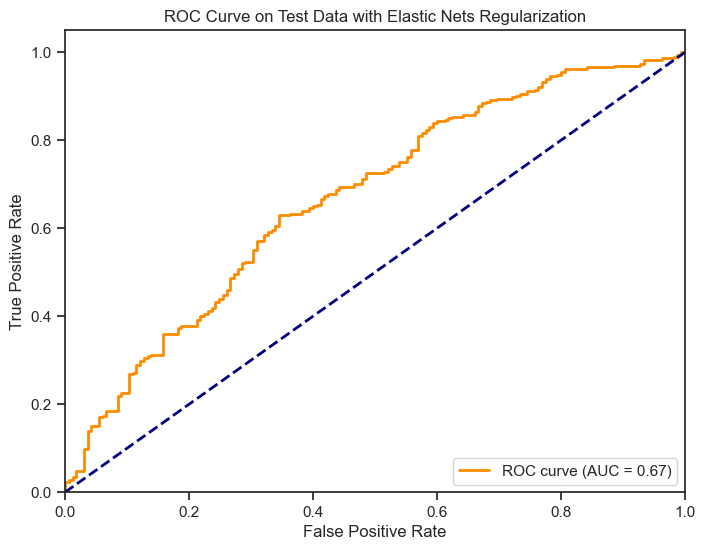

In [101]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Data with Elastic Nets Regularization')
plt.legend(loc='lower right')
plt.show()

PR AUC: 0.7649586881624748
Optimal Threshold: 0.222


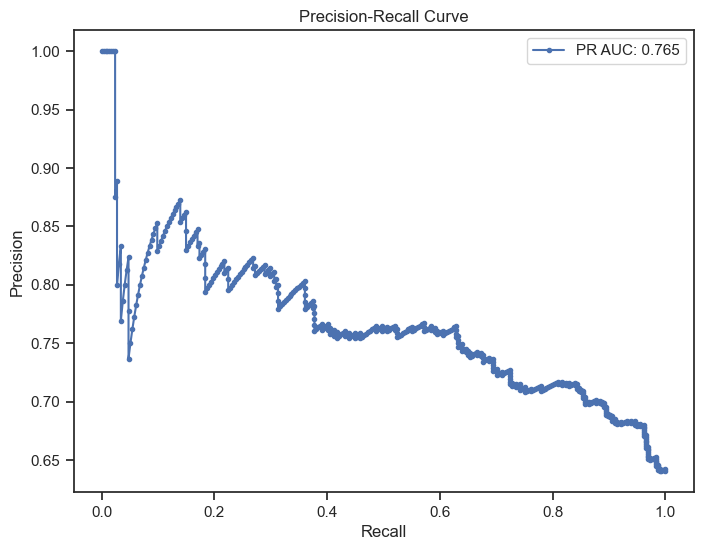

In [102]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

# Find the best threshold: maximizing recall while keeping precision decent
best_index = np.argmax(recall - (1 - precision))  # Balance recall & precision
best_threshold = thresholds[best_index]

print(f"Optimal Threshold: {best_threshold:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC: {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()



### Model Evaluation - Predicting sem1_enr = 0 for mentee students who did not enroll in college the Fall after high school graduation.

Best parameters found: {'C': 100, 'l1_ratio': 0.1}
Average Accuracy: 0.4839

Fold 1 Confusion Matrix:
[[136  30]
 [219  75]]

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.88      0.56       165
           1       0.82      0.29      0.43       294

    accuracy                           0.50       459
   macro avg       0.61      0.59      0.49       459
weighted avg       0.67      0.50      0.48       459


Fold 2 Confusion Matrix:
[[144  22]
 [213  80]]

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.88      0.56       165
           1       0.82      0.29      0.43       294

    accuracy                           0.50       459
   macro avg       0.61      0.59      0.49       459
weighted avg       0.67      0.50      0.48       459


Fold 3 Confusion Matrix:
[[152  13]
 [239  55]]

Fold 3 Classification Report:
              precision    rec

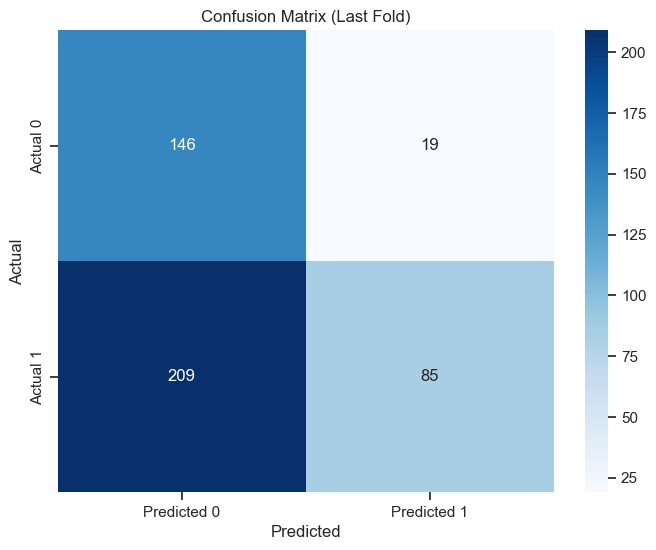

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import statsmodels.api as sm

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize StratifiedKFold with 5 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

# Define the parameter grid for l1_ratio and C
param_grid = {
    'l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Initialize the logistic regression model with elastic net regularization
log_reg_en = LogisticRegression(penalty='elasticnet', class_weight= {0:4, 1:1}, solver='saga', max_iter=10000)

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg_en, param_grid, cv=kf, scoring='accuracy', n_jobs=-1)

# Fit the model using grid search
grid_search.fit(X, y)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Lists to store evaluation metrics for each fold
accuracy_scores = []
conf_matrices = []
class_reports = []

# Iterate through each fold
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit logistic regression model with the best parameters
    log_reg_en_best = LogisticRegression(penalty='elasticnet', class_weight={0:4, 1:1}, C=best_params['C'], solver='saga', l1_ratio=best_params['l1_ratio'], max_iter=10000)
    log_reg_en_best.fit(X_train, y_train)
    
    # Make predictions
    y_pred_prob = log_reg_en_best.predict_proba(X_test)[:, 1]
    y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions
    
    # Evaluate the model
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))
    class_reports.append(classification_report(y_test, y_pred, output_dict=True))

# Print average accuracy
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")

# Print confusion matrices and classification reports for each fold
for i, (conf_matrix, class_report) in enumerate(zip(conf_matrices, class_reports)):
    print(f"\nFold {i+1} Confusion Matrix:")
    print(conf_matrix)
    print(f"\nFold {i+1} Classification Report:")
    print(classification_report(y_test, y_pred))

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrices[-1], annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Last Fold)')
plt.show()

With an overall accuracy of 48%, the F1 score still only is at about 50 for the sem1_enr = 0. This means this model may need oversampling of the minority class to provide better predictions.

Best parameters found: {'C': 0.1, 'l1_ratio': 0.25}
Average Accuracy: 0.6564

Fold 1 Confusion Matrix:
[[ 84  82]
 [ 77 217]]

Fold 1 Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       165
           1       0.72      0.71      0.72       294

    accuracy                           0.64       459
   macro avg       0.61      0.61      0.61       459
weighted avg       0.64      0.64      0.64       459


Fold 2 Confusion Matrix:
[[ 79  87]
 [ 76 217]]

Fold 2 Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       165
           1       0.72      0.71      0.72       294

    accuracy                           0.64       459
   macro avg       0.61      0.61      0.61       459
weighted avg       0.64      0.64      0.64       459


Fold 3 Confusion Matrix:
[[ 86  79]
 [ 87 207]]

Fold 3 Classification Report:
              precision    re

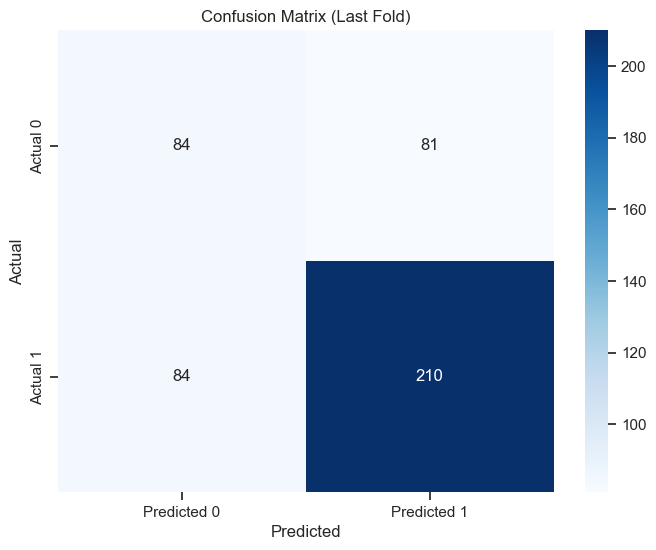

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE
from sklearn.utils.validation import validate_data

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize StratifiedKFold with 5 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

# Define the parameter grid for l1_ratio and C
param_grid = {
    'l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Initialize the logistic regression model with elastic net regularization
log_reg_en = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=10000)

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg_en, param_grid, cv=kf, scoring='accuracy', n_jobs=-1)

# Fit the model using grid search
grid_search.fit(X, y)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

# Lists to store evaluation metrics for each fold
accuracy_scores = []
conf_matrices = []
class_reports = []

# Initialize SMOTE
smote = SMOTE(random_state=21)

# Iterate through each fold
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Apply SMOTE to the training data
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    # Fit logistic regression model with the best parameters
    log_reg_en_best = LogisticRegression(penalty='elasticnet', C=best_params['C'], solver='saga', l1_ratio=best_params['l1_ratio'], max_iter=10000)
    log_reg_en_best.fit(X_train_resampled, y_train_resampled)
    
    # Make predictions
    y_pred_prob = log_reg_en_best.predict_proba(X_test)[:, 1]
    y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions
    
    # Evaluate the model
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))
    class_reports.append(classification_report(y_test, y_pred, output_dict=True))

# Print average accuracy
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")

# Print confusion matrices and classification reports for each fold
for i, (conf_matrix, class_report) in enumerate(zip(conf_matrices, class_reports)):
    print(f"\nFold {i+1} Confusion Matrix:")
    print(conf_matrix)
    print(f"\nFold {i+1} Classification Report:")
    print(classification_report(y_test, y_pred))

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrices[-1], annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Last Fold)')
plt.show()

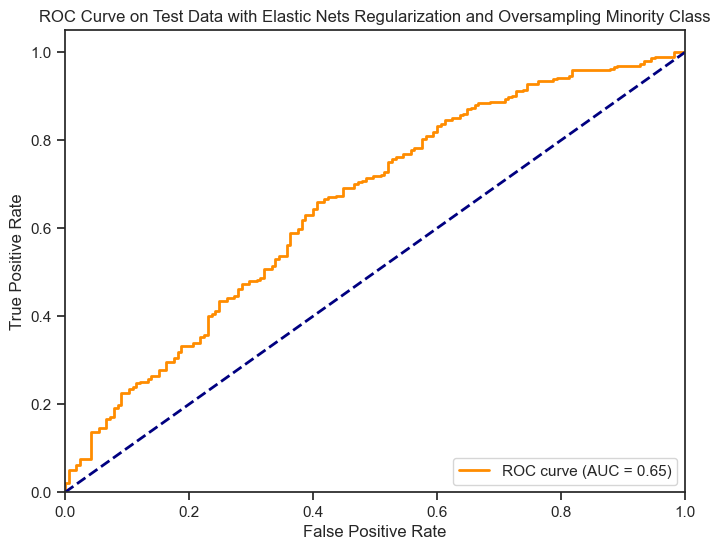

In [105]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Data with Elastic Nets Regularization and Oversampling Minority Class')
plt.legend(loc='lower right')
plt.show()

PR AUC: 0.7531302910068729
Optimal Threshold: 0.064


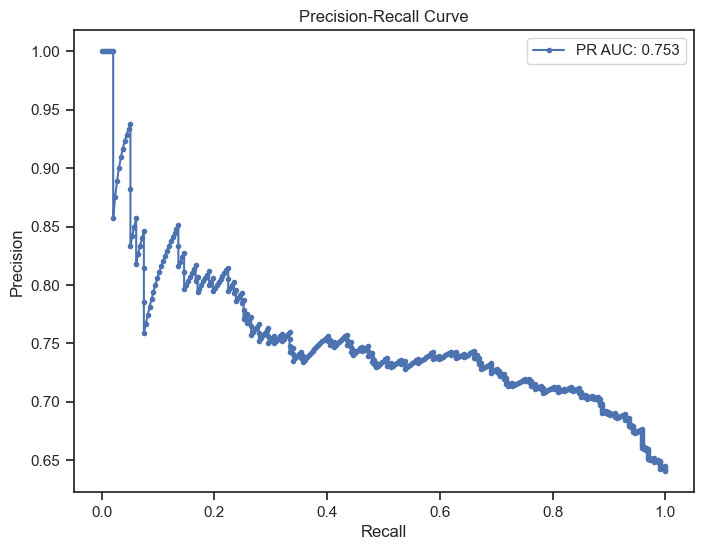

In [106]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

# Find the best threshold: maximizing recall while keeping precision decent
best_index = np.argmax(recall - (1 - precision))  # Balance recall & precision
best_threshold = thresholds[best_index]

print(f"Optimal Threshold: {best_threshold:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC: {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


### On the whole dataset - Logistic Regression Using Gridsearch CV with Elastic Nets & K-Fold Cross Validation

Accuracy: 66.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       827
           1       0.74      0.75      0.74      1469

    accuracy                           0.67      2296
   macro avg       0.64      0.64      0.64      2296
weighted avg       0.67      0.67      0.67      2296



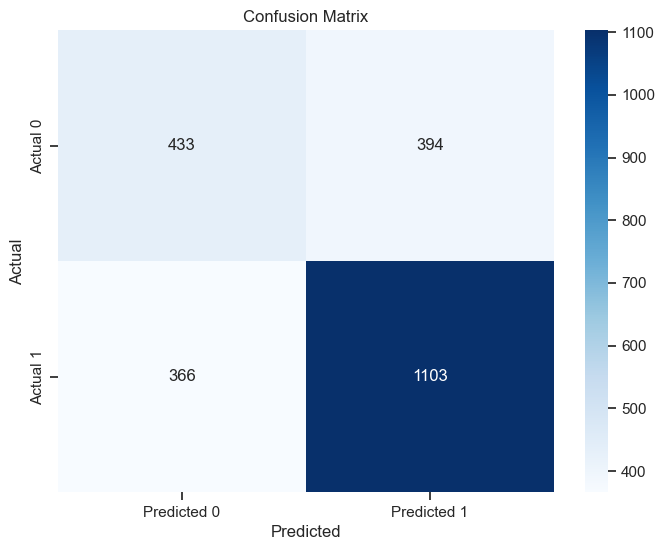

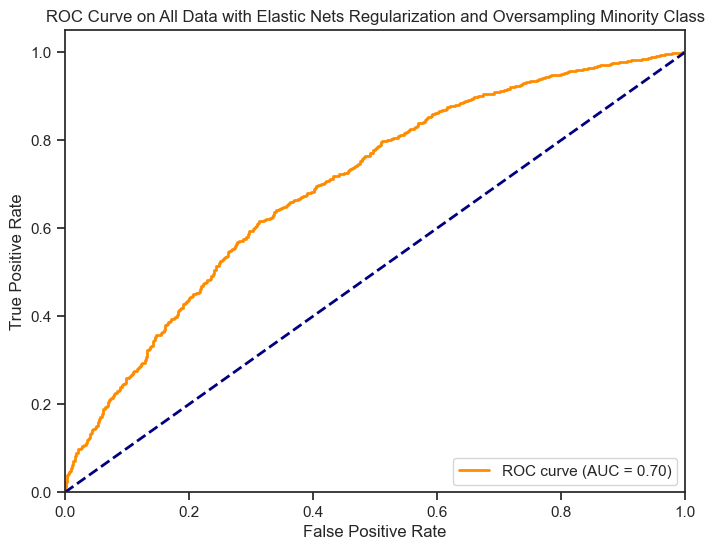

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE
from sklearn.utils.validation import validate_data

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize SMOTE
smote = SMOTE(random_state=21)
    
# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X, y)

# Fit logistic regression model with the best parameters
log_reg_en_best = LogisticRegression(penalty='elasticnet', C= 0.1, l1_ratio = 0.25, solver='saga')
log_reg_en_best.fit(X_resampled, y_resampled)

# Make predictions
y_pred_prob = log_reg_en_best.predict_proba(X)[:, 1]
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions

# Create confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

# Print overall accuracy
accuracy = accuracy_score(y, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Print classification report for additional metrics
class_report = classification_report(y, y_pred)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on All Data with Elastic Nets Regularization and Oversampling Minority Class')
plt.legend(loc='lower right')
plt.show()

#### Current Analysis

The best performing model for our business use case is able to adequately classify between sem1_enr = 0 and sem1_enr = 1 with on average 66% accuracy, having dealt with issues such as class imbalance, dealing with overfitting by utilizing hyperparemeter tuning with GridSearchCV, and applying Lasso & Ridge Regularization techniques with Elastic Nets. The model at this point is accurate, robust because it generalizes well to new data as validated by the test data using k-fold cross-validation techniques, and is simplified using feature selection with Lasso Regularization. 

## XGBoost

In [108]:
from numpy import loadtxt
from xgboost import XGBClassifier
from xgboost import XGBRFClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [109]:
X = df_encoded.drop(columns=['sem1_enr'])
y = df_encoded['sem1_enr']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [110]:
# Initialize XGBClassifier
XGB_Classifier_model = XGBClassifier(objective='binary:logistic', random_state=42)

# Fit the model to training data
XGB_Classifier_model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = XGB_Classifier_model.predict(X_test)
print(predictions[:5])

[1 1 1 1 1]


Confusion Matrix:
[[ 75 115]
 [ 63 207]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.39      0.46       190
           1       0.64      0.77      0.70       270

    accuracy                           0.61       460
   macro avg       0.59      0.58      0.58       460
weighted avg       0.60      0.61      0.60       460



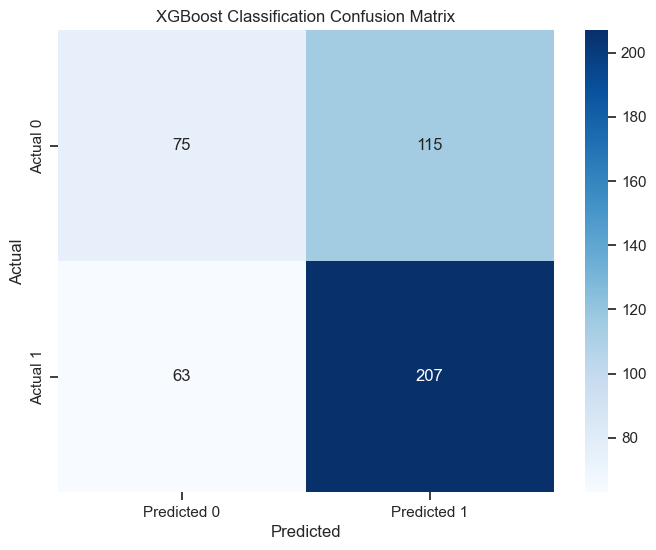

In [112]:
# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Classification Confusion Matrix')
plt.show()

[1 1 1 1 1]
Model Accuracy: 0.6587
Confusion Matrix:
[[ 73 117]
 [ 40 230]]

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.38      0.48       190
           1       0.66      0.85      0.75       270

    accuracy                           0.66       460
   macro avg       0.65      0.62      0.61       460
weighted avg       0.66      0.66      0.64       460



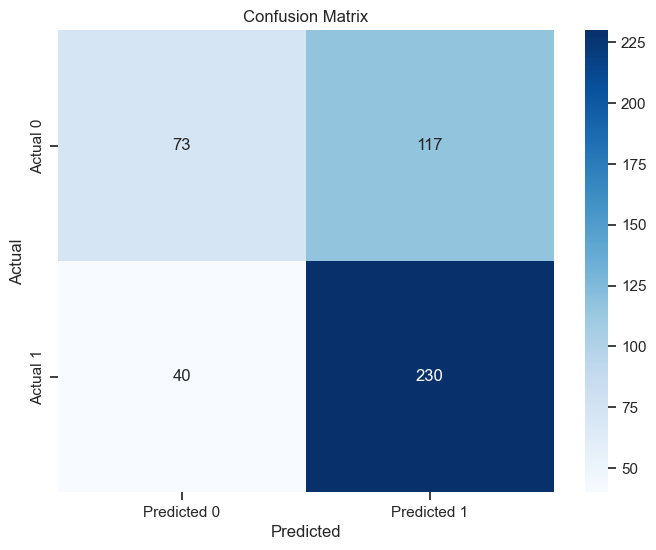

In [297]:
# Define XGBClassifier model parameters
params = {
    'objective': 'binary:logistic',
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Instantiate XGBoost Random Forest Classifier with the parameters
XGB_Classifier_model = XGBClassifier(**params)

# Fit the model to training data
XGB_Classifier_model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = XGB_Classifier_model.predict(X_test)
print(predictions[:5])

# print overall model accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.4f}")

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print("")
print(class_report)


# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### XGBRF Classifier - Random Forest

[1 1 1 1 0]
Model Accuracy: 0.6609
Confusion Matrix:
[[ 78 112]
 [ 44 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.41      0.50       190
           1       0.67      0.84      0.74       270

    accuracy                           0.66       460
   macro avg       0.65      0.62      0.62       460
weighted avg       0.66      0.66      0.64       460



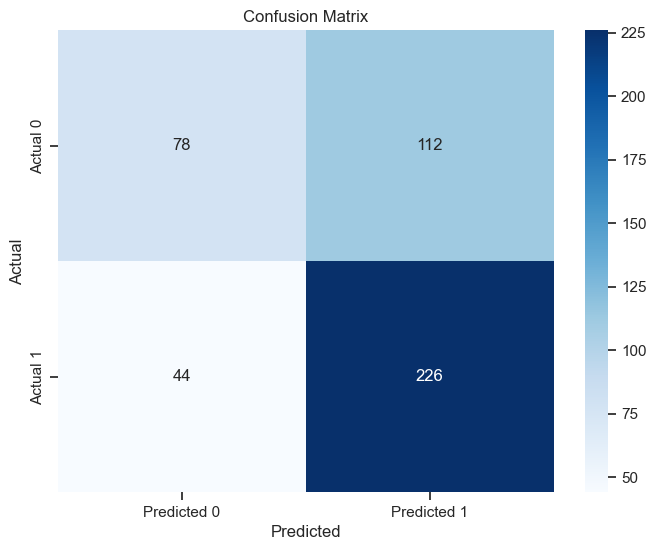

In [298]:
# Instantiate XGBRFClassifier with the parameters
XGBRF_model = XGBRFClassifier(objective='binary:logistic', random_state=42)

# Fit the model to training data
XGBRF_model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = XGBRF_model.predict(X_test)
print(predictions[:5])

# print overall model accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.4f}")

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [299]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 66.09%


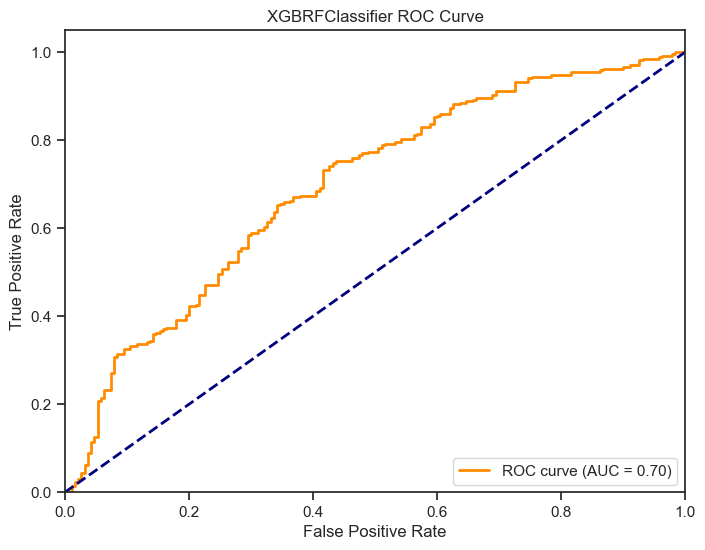

In [300]:
# Get the predicted probabilities for the positive class
y_pred_prob = XGBRF_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBRFClassifier ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Support Vector Machines

In [301]:
from sklearn import svm
from sklearn.linear_model import Perceptron

Check for Linear Separability for choosing the correct Kernel to train SVM on.

In [302]:
from sklearn.linear_model import Perceptron

perc = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perc.fit(X_train, y_train)

score = perc.score(X_test, y_test)
print(f"Perceptron Accuracy: {score:.4f}")

if score > 0.95:
    print("Data is likely linearly separable.")
else:
    print("Data is NOT linearly separable.")

Perceptron Accuracy: 0.6130
Data is NOT linearly separable.


Train the SVM model with rbf and create predictions

[1 1 1 1 1]
Confusion Matrix:
[[ 16 174]
 [  3 267]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.08      0.15       190
           1       0.61      0.99      0.75       270

    accuracy                           0.62       460
   macro avg       0.72      0.54      0.45       460
weighted avg       0.70      0.62      0.50       460



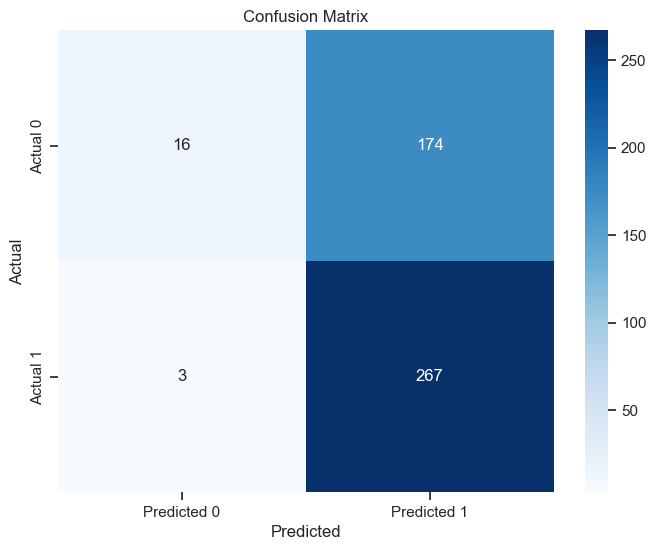

In [303]:
# Instantiate SVM with the parameters
model = svm.SVC(kernel='rbf')

# Fit the model to training data
model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = model.predict(X_test)
print(predictions[:5])

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)


# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

[1 1 1 1 1]
Confusion Matrix:
[[ 42 148]
 [ 22 248]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.22      0.33       190
           1       0.63      0.92      0.74       270

    accuracy                           0.63       460
   macro avg       0.64      0.57      0.54       460
weighted avg       0.64      0.63      0.57       460



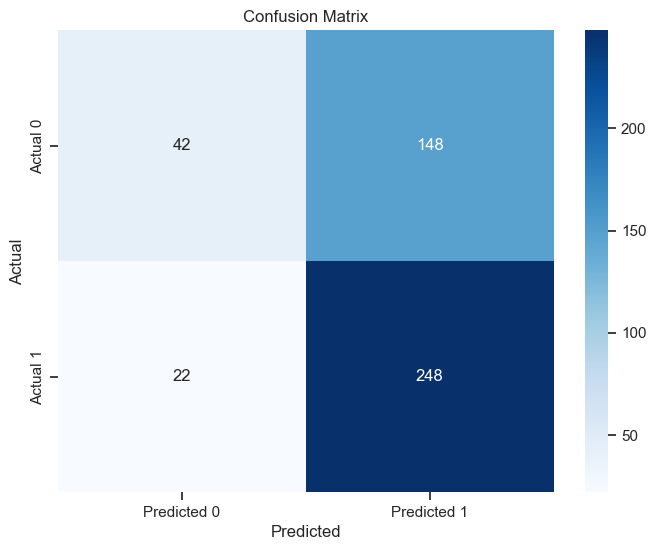

In [304]:
# Instantiate SVM with the parameters for poly
model = svm.SVC(kernel='poly', degree=6)

# Fit the model to training data
model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = model.predict(X_test)
print(predictions[:5])

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)


# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### K-Nearest Neighbors Classifier

In [305]:
from sklearn.neighbors import KNeighborsClassifier as KNN

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # Use the same scaler for test data


[1 1 1 0 1]
Confusion Matrix:
[[ 76 114]
 [ 61 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.40      0.46       190
           1       0.65      0.77      0.70       270

    accuracy                           0.62       460
   macro avg       0.60      0.59      0.58       460
weighted avg       0.61      0.62      0.61       460



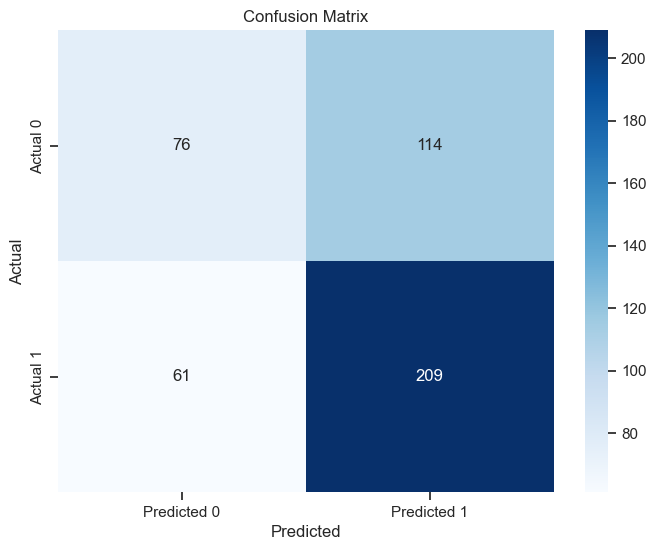

In [306]:
# Instantiate KNN with the parameters
model = KNN(n_neighbors=5)

# Fit the model to training data
model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = model.predict(X_test)
print(predictions[:5])

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)


# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

[1 1 1 0 1]
Confusion Matrix:
[[104  86]
 [110 160]]

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.55      0.51       190
           1       0.65      0.59      0.62       270

    accuracy                           0.57       460
   macro avg       0.57      0.57      0.57       460
weighted avg       0.58      0.57      0.58       460



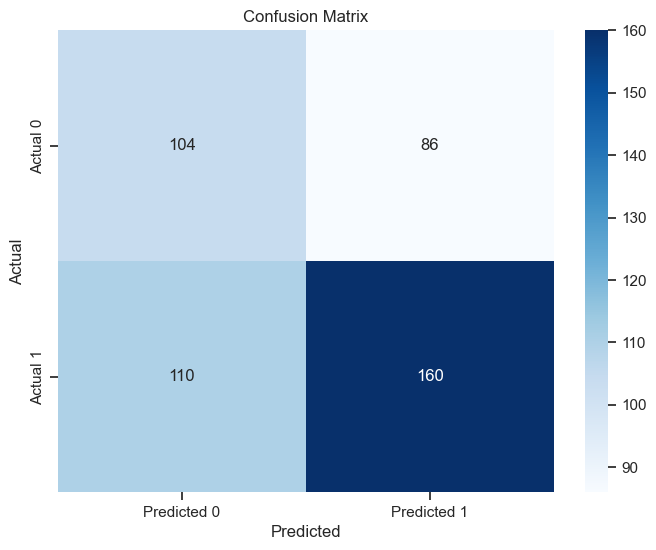

In [307]:
# Instantiate KNN
model = KNN(n_neighbors=4)

# Fit the model to training data
model.fit(X_train, y_train)

# Make predictions with the fit KNN model
predictions = model.predict(X_test)
print(predictions[:5])

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)


# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

[1 1 0 0 1]
Confusion Matrix:
[[ 71 119]
 [ 51 219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.37      0.46       190
           1       0.65      0.81      0.72       270

    accuracy                           0.63       460
   macro avg       0.61      0.59      0.59       460
weighted avg       0.62      0.63      0.61       460



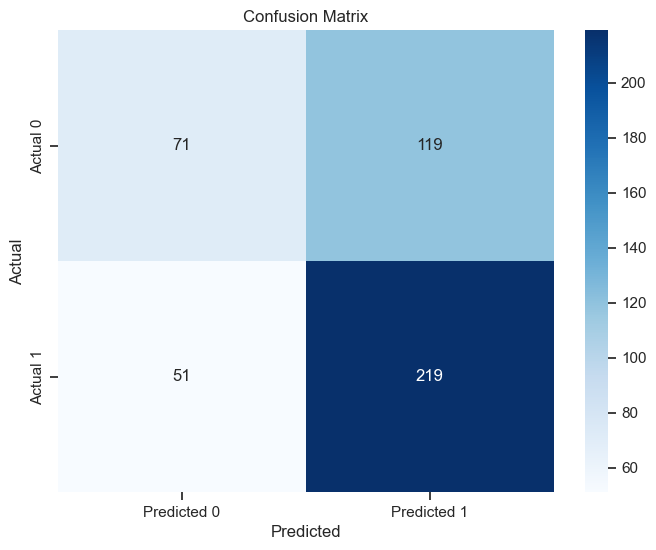

In [308]:
# Instantiate KNN with the parameters
model = KNN(n_neighbors=7)

# Fit the model to training data
model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = model.predict(X_test)
print(predictions[:5])

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)


# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Tuning Hyperparameters in KNN

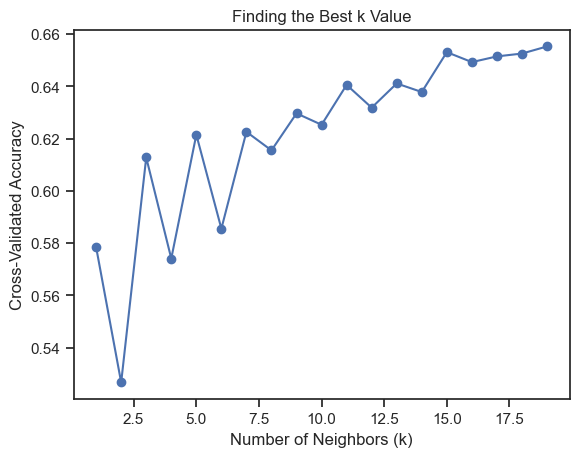

Best k: 19


In [309]:
from sklearn.model_selection import cross_val_score

# Test different k values
k_values = range(1, 20)
scores = [cross_val_score(KNN(n_neighbors=k), X_train, y_train, cv=5).mean() for k in k_values]

# Plot k vs. accuracy
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Finding the Best k Value")
plt.show()

# Best k value
best_k = k_values[np.argmax(scores)]
print(f"Best k: {best_k}")


##### KNN with 19 Neighbors

[1 1 1 0 1]
Confusion Matrix:
[[ 55 135]
 [ 24 246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.29      0.41       190
           1       0.65      0.91      0.76       270

    accuracy                           0.65       460
   macro avg       0.67      0.60      0.58       460
weighted avg       0.67      0.65      0.61       460



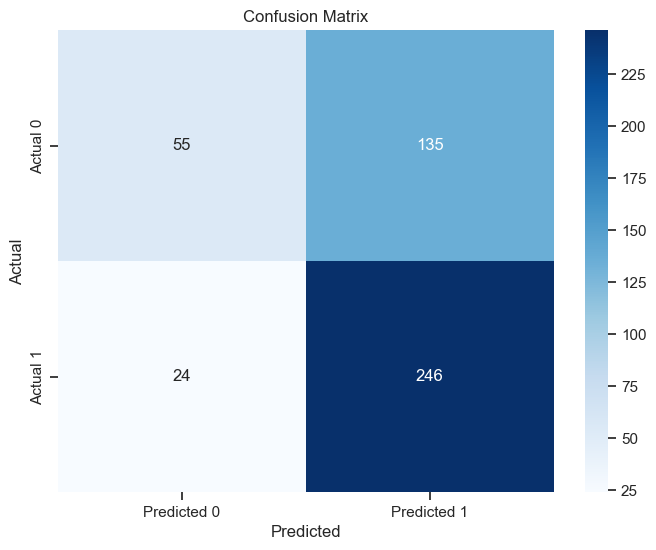

In [310]:
# Instantiate XGBRFClassifier with the parameters
model = KNN(n_neighbors=19)

# Fit the model to training data
model.fit(X_train, y_train)

# Make predictions with the fit model
predictions = model.predict(X_test)
print(predictions[:5])

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Optional: Print classification report for additional metrics
class_report = classification_report(y_test, predictions)
print("\nClassification Report:")
print(class_report)


# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

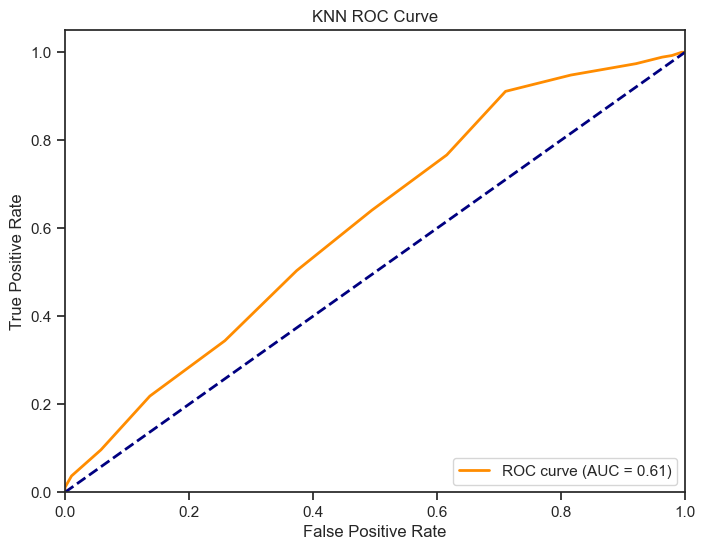

In [311]:
# Get the predicted probabilities for the positive class
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Logistic Regression Model Selection
### Logistic Regression Using Gridsearch CV with Elastic Nets & K-Fold Cross Validation

Accuracy: 66.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.52      0.53       827
           1       0.74      0.75      0.74      1469

    accuracy                           0.67      2296
   macro avg       0.64      0.64      0.64      2296
weighted avg       0.67      0.67      0.67      2296



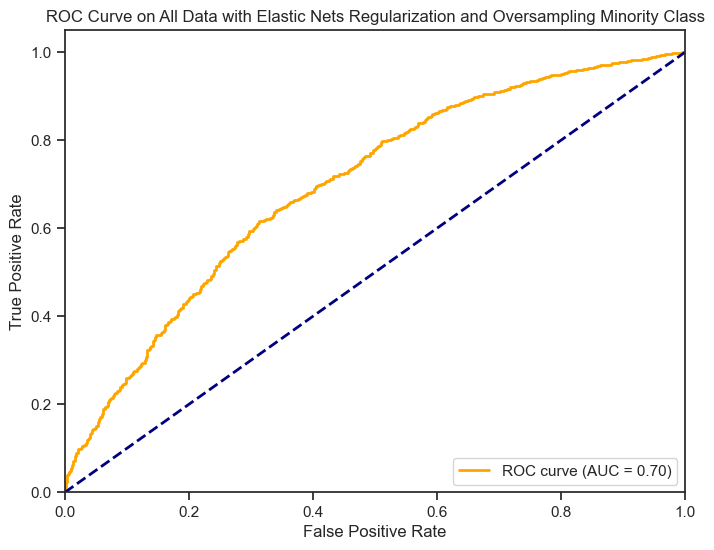

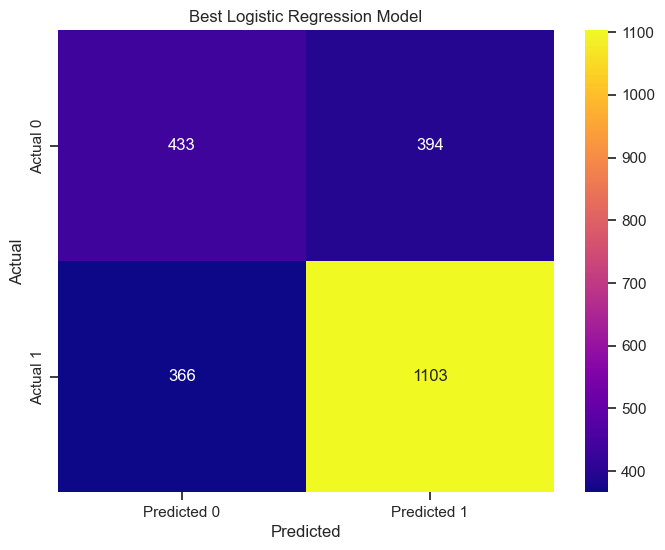

In [312]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE
from sklearn.utils.validation import validate_data

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=['sem1_enr'])
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize SMOTE
smote = SMOTE(random_state=21)
    
# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X, y)

# Fit logistic regression model with the best parameters
log_reg_en_best = LogisticRegression(penalty='elasticnet', C= 0.1, l1_ratio = 0.25, solver='saga')
log_reg_en_best.fit(X_resampled, y_resampled)

# Make predictions
y_pred_prob = log_reg_en_best.predict_proba(X)[:, 1]
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions

# Create confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

# Print overall accuracy
accuracy = accuracy_score(y, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Print classification report for additional metrics
class_report = classification_report(y, y_pred)
print("\nClassification Report:")
print(class_report)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on All Data with Elastic Nets Regularization and Oversampling Minority Class')
plt.legend(loc='lower right')
plt.show()

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='plasma', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Best Logistic Regression Model')
plt.show()

# Model Calibration

According to Brownlee (2019), bagged decision trees and boosted decision trees along with SVM and Random Forest algorithms all benefit the most from model calibration. Because of this, I will attempt to calibrate the model for the XGBoost Random Forest Classifier to see if the calibrated version will outperform the tuned Logistic Regression Model, which is the current best performer on this dataset.

### **<p style="text-align: center;">References</p>**

Brownlee, J. (2019, September 24). How and When to Use a Calibrated Classification Model with scikit-learn. MachineLearningMastery.com. https://machinelearningmastery.com/calibrated-classification-model-in-scikit-learn/

## Model Calibration: XGBoost Random Forest Classifier

Accuracy: 66.09%
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.41      0.50       190
           1       0.67      0.84      0.74       270

    accuracy                           0.66       460
   macro avg       0.65      0.62      0.62       460
weighted avg       0.66      0.66      0.64       460



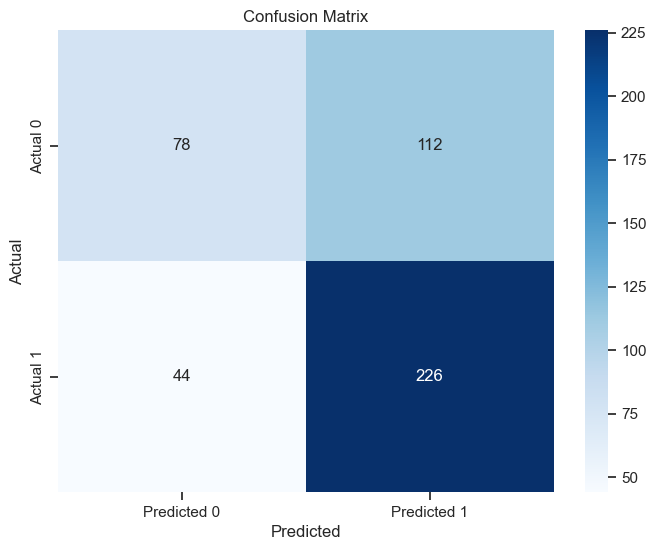

In [126]:
from sklearn.calibration import calibration_curve
from numpy import loadtxt
from xgboost import XGBClassifier
from xgboost import XGBRFClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_encoded.drop(columns=['sem1_enr'])
y = df_encoded['sem1_enr']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Instantiate XGBRFClassifier & fit the model
XGBRF_model = XGBRFClassifier(objective='binary:logistic', random_state=42)
XGBRF_model.fit(X_train, y_train)

# Make predictions with the fit model
y_pred = XGBRF_model.predict(X_test)

# print overall model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# print("Confusion Matrix:")
# print(conf_matrix)

# Print classification report for additional metrics
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [127]:
# Get the predicted probabilities for the positive class
y_pred_prob_all_training = XGBRF_model.predict_proba(X)[:, 1]
y_pred_all_data = XGBRF_model.predict(X) # Convert probabilities to binary predictions

df_results = pd.DataFrame(columns = ['y_pred', 'y_actual', 'y_pred_prob'])
df_results['y_pred_prob'] = y_pred_prob_all_training
df_results['y_pred'] = y_pred_all_data # refers to df_encoded['sem1_enr'] predictions on the test set
df_results['y_actual'] = y # refers to df_encoded['sem1_enr'] actual values
df_results

,y_pred,y_actual,y_pred_prob
0,1,0,0.586318
1,1,1,0.759259
2,1,1,0.804494
3,1,1,0.793781
4,1,1,0.811723
...,...,...,...
2291,0,0,0.432616
2292,1,1,0.762862
2293,0,0,0.383044
2294,1,1,0.715728


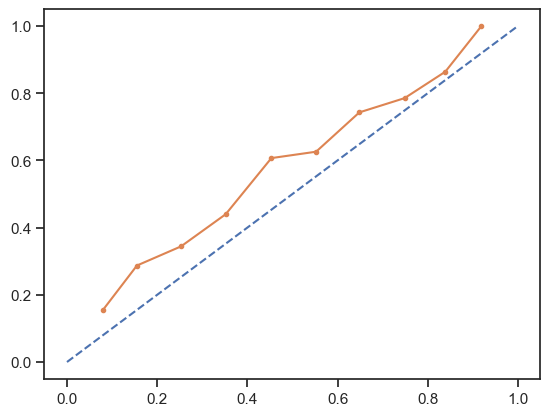

In [128]:
from sklearn.calibration import calibration_curve
from matplotlib import pyplot
# reliability diagram
fop, mpv = calibration_curve(y, y_pred_prob, n_bins=10)

# plot perfectly calibrated
pyplot.plot([0, 1], [0, 1], linestyle='--')
# plot model reliability
pyplot.plot(mpv, fop, marker='.')
pyplot.show()


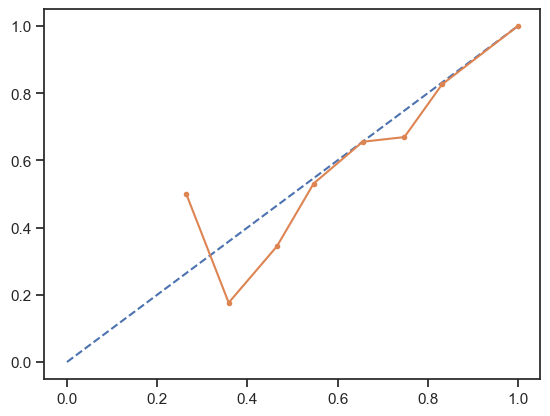

In [129]:
from sklearn.calibration import CalibratedClassifierCV
calibrator = CalibratedClassifierCV(XGBRF_model, method = 'isotonic', cv = 3)
calibrator.fit(X_train, y_train)

# predict probabilities
probs = calibrator.predict_proba(X_test)[:, 1]
# reliability diagram
fop, mpv = calibration_curve(y_test, probs, n_bins=10)
# plot perfectly calibrated
pyplot.plot([0, 1], [0, 1], linestyle='--')
# plot calibrated reliability
pyplot.plot(mpv, fop, marker='.')
pyplot.show()

Accuracy: 67.39%
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.40      0.50       190
           1       0.67      0.87      0.76       270

    accuracy                           0.67       460
   macro avg       0.68      0.63      0.63       460
weighted avg       0.67      0.67      0.65       460



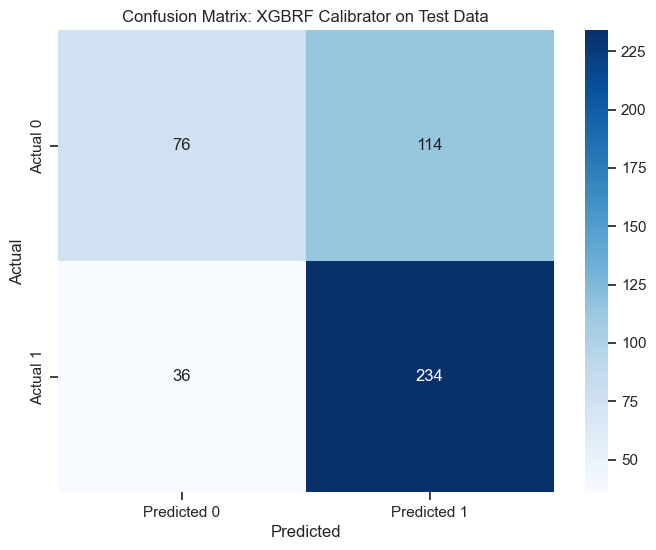

In [130]:
# print overall model accuracy
y_pred = calibrator.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# print("Confusion Matrix:")
# print(conf_matrix)

# Print classification report for additional metrics
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: XGBRF Calibrator on Test Data')
plt.show()

Accuracy: 74.56%
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.44      0.55       827
           1       0.74      0.92      0.82      1469

    accuracy                           0.75      2296
   macro avg       0.75      0.68      0.69      2296
weighted avg       0.75      0.75      0.73      2296



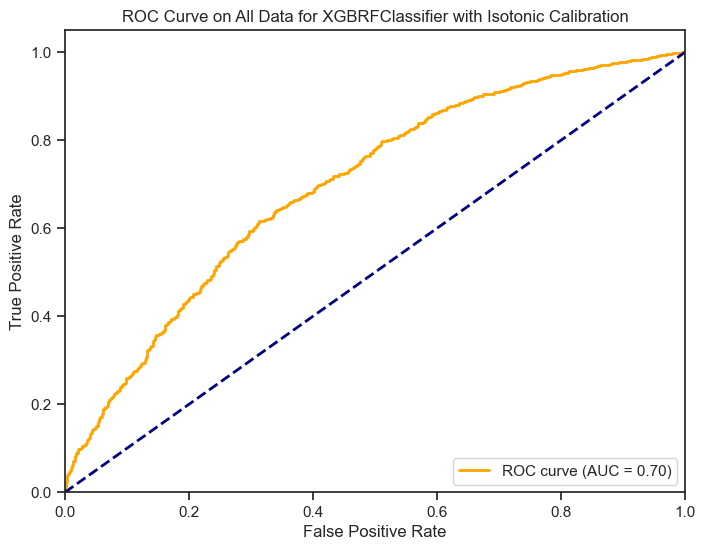

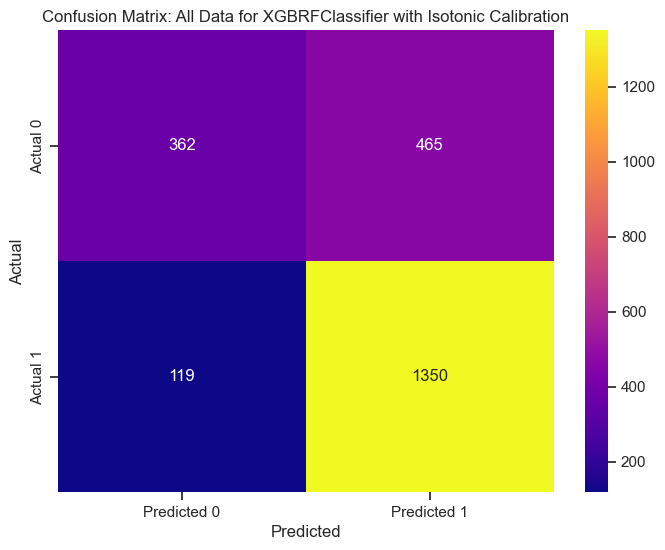

In [131]:
# print overall model accuracy
y_pred = calibrator.predict(X)

accuracy = accuracy_score(y, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Create confusion matrix
conf_matrix = confusion_matrix(y, y_pred)
# print("Confusion Matrix:")
# print(conf_matrix)

# Print classification report for additional metrics
class_report = classification_report(y, y_pred)
print("Classification Report:")
print(class_report)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on All Data for XGBRFClassifier with Isotonic Calibration')
plt.legend(loc='lower right')
plt.show()

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='plasma', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: All Data for XGBRFClassifier with Isotonic Calibration')
plt.show()

### Overall Model Selection Process (as of March 22, 2025)
#### AUC Scores are both 0.70 on All Data

**Logistic Regression**:
- Produces a better overall outcome, specifically with Recall.
- For the negative class it will be chosen for predictions of those students who will not enroll on time: (sem1_enr = 0)

**XGBoost Random Forest Classifier**: 
- Because the XGBoost Random Forest Calibrated Classifier with Isotonic Calibration predicts overall accuracy, it will be used to predict the positive class.
- For those students who will enroll on time: (sem1_enr = 1)

# Simulation

Step 1: Defining the Problem and Solution
- Definite the process to simulate: Determine the outcome of changing certain input variables on sem1_enr, which the process is chaning the variables that will lead to stronger impacts on levels of enrollment.
- identify the input variables and their probability distributions.
- Question I want to answer: "If I change one of the variables, how does this affect increases or decreases in average sem1_enr?"

In [132]:
df.head()

,user_id,cohort,Member,school,gender,race/ethnicity,LOM (control matches),matched_sixmonths,# of Mentors,online_pair_completion_sr_yr,...,SEL.RS_1,SEL.RS_2,SEL.RS_3,SEL.RS_4,SEL.RS_5,SEL.RDM_1,SEL.RDM_2,SEL.RDM_3,SEL.RDM_4,SEL.RDM_5
0,123456,2019,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1244,1,1,57,...,2,2,3,3,3,3,2,3,3,3
1,123457,2019,iMentor NYC,Rushmore Academy,Female,Hispanic (May be of any race),1500,1,2,68,...,3,2,3,3,2,2,3,3,3,3
2,123458,2019,iMentor NYC,Rushmore Academy,Male,Black / African American,1529,1,2,84,...,2,2,2,2,2,4,4,4,4,4
3,123459,2019,iMentor NYC,Rushmore Academy,Male,Hispanic (May be of any race),1552,1,3,92,...,4,3,4,3,2,3,3,3,3,3
4,123460,2019,iMentor NYC,Rushmore Academy,Male,Asian / Pacific Islander,1580,1,2,95,...,2,2,3,2,1,3,3,3,3,3


In [133]:
df_cleaned.head()

,LOM (control matches),matched_sixmonths,online_pair_completion_sr_yr,pair_mtgs_sr_yr,sem1_enr,SEL.GM_1,SEL.GM_2,SEL.GM_3,SEL.GM_4,SEL.GM_5,...,gender_Male,race/ethnicity_Black / African American,race/ethnicity_Did not answer,race/ethnicity_I identify with a race not listed here,race/ethnicity_Multi-Racial,race/ethnicity_Native American (Aleutian Islander),race/ethnicity_White (Non-Hispanic),# of Mentors_2,# of Mentors_3,# of Mentors_4
0,0.663966,1,0.124822,-0.968025,0,2,3,3,3,3,...,1,0,0,0,0,0,0,0,0,0
1,1.316637,1,0.463292,0.823420,1,3,2,2,3,2,...,0,0,0,0,0,0,0,1,0,0
2,1.390573,1,0.955612,1.121994,1,4,4,4,4,4,...,1,1,0,0,0,0,0,1,0,0
3,1.449211,1,1.201772,-0.072303,1,3,3,3,3,3,...,1,0,0,0,0,0,0,0,1,0
4,1.520597,1,1.294082,1.121994,1,3,3,3,3,3,...,1,0,0,0,0,0,0,1,0,0


Only choosing the statistically significant features that do not have VIF/Multicollinearity, so that the Simulation Model only will look at statistically significant variable changes.

In [134]:
sim_features = selected_features.drop('const')
sim_features = sim_features.tolist()
sim_features.append('sem1_enr')
sim_features

# filter the dataframe to only include the selected features that are in the sim_featurs list.
df_cleaned[sim_features].head(10)

,LOM (control matches),online_pair_completion_sr_yr,pair_mtgs_sr_yr,SEL.GM_9,cohort_2020,cohort_2021,school_Rydell High School,gender_Male,sem1_enr
0,0.663966,0.124822,-0.968025,2,0,0,0,1,0
1,1.316637,0.463292,0.823420,2,0,0,0,0,1
2,1.390573,0.955612,1.121994,4,0,0,0,1,1
3,1.449211,1.201772,-0.072303,3,0,0,0,1,1
4,1.520597,1.294082,1.121994,2,0,0,0,1,1
5,1.589434,0.063282,-0.669451,3,0,0,0,0,1
6,1.265647,0.863302,0.226271,4,0,0,0,1,0
7,-1.406227,-1.629067,-1.266599,2,0,0,0,0,0
8,0.717505,-1.198287,-0.370877,2,0,0,0,1,1
9,1.591983,1.294082,1.121994,4,0,0,0,1,1


In [135]:
unistats(df_cleaned[sim_features])

,Count,Unique,Missing_%,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
LOM (control matches),2296,759,0.0,float64,-2.47,3.38,-0.66,-0.51,1.10,-0.00,-0.51,-0.51,1.00,0.06,-1.20
online_pair_completion_sr_yr,2296,95,0.0,float64,-1.63,1.45,-0.80,0.19,0.86,-0.00,0.19,-1.63,1.00,-0.39,-1.14
pair_mtgs_sr_yr,2296,19,0.0,float64,-1.27,5.60,-0.97,-0.07,0.52,0.00,-0.07,-1.27,1.00,0.64,0.55
SEL.GM_9,2296,4,0.0,int64,1.00,4.00,2.00,3.00,3.00,2.79,3.00,3.00,0.85,-0.29,-0.53
cohort_2020,2296,2,0.0,int64,0.00,1.00,0.00,0.00,0.00,0.22,0.00,0.00,0.41,1.37,-0.12
cohort_2021,2296,2,0.0,int64,0.00,1.00,0.00,0.00,1.00,0.35,0.00,0.00,0.48,0.63,-1.60
school_Rydell High School,2296,2,0.0,int64,0.00,1.00,0.00,0.00,0.00,0.05,0.00,0.00,0.21,4.24,15.96
gender_Male,2296,2,0.0,int64,0.00,1.00,0.00,0.00,1.00,0.49,0.00,0.00,0.50,0.02,-2.00
sem1_enr,2296,2,0.0,int64,0.00,1.00,0.00,1.00,1.00,0.64,1.00,1.00,0.48,-0.58,-1.66


Input Variables and their Probability Distributions:
- LOM (control matches): Normal
- online_pair_completion_sr_yr: Normal
- pair_mtgs_sr_yr: Normal
- SEL.GM_9: Normal
- cohort_2020: Binomial
- cohort_2021: Binomial
- school_Rydell High School: Binomial
- gender_male: Binomial

Output Variable and it's Probability Distribution
- Sem1_enr: Binomial


Text(0.5, 1.0, 'Distribution of Rydell High School')

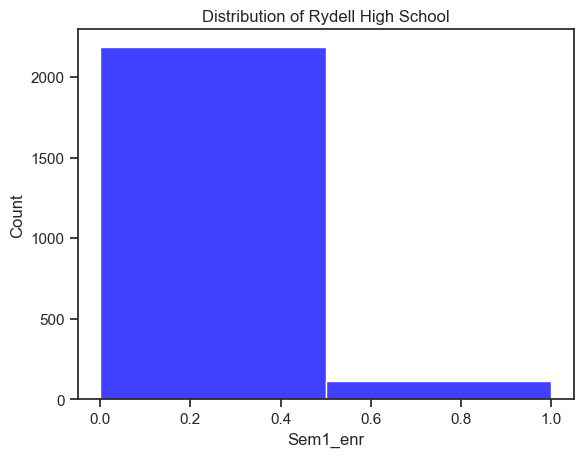

In [136]:
sns.histplot(df_cleaned['school_Rydell High School'], bins = 2, kde=False, color = 'blue')
plt.xlabel('Sem1_enr')
plt.ylabel('Count')
plt.title('Distribution of Rydell High School')

Text(0.5, 1.0, 'Distribution of Gender')

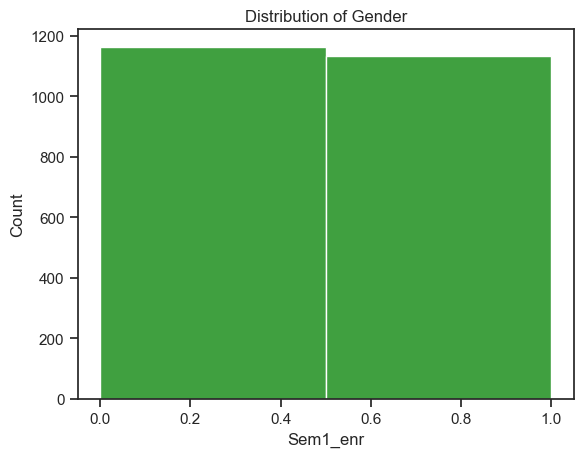

In [137]:
sns.histplot(df_cleaned['gender_Male'], bins = 2, kde=False, color = 'green')
plt.xlabel('Sem1_enr')
plt.ylabel('Count')
plt.title('Distribution of Gender')

(0.0, 2000.0)

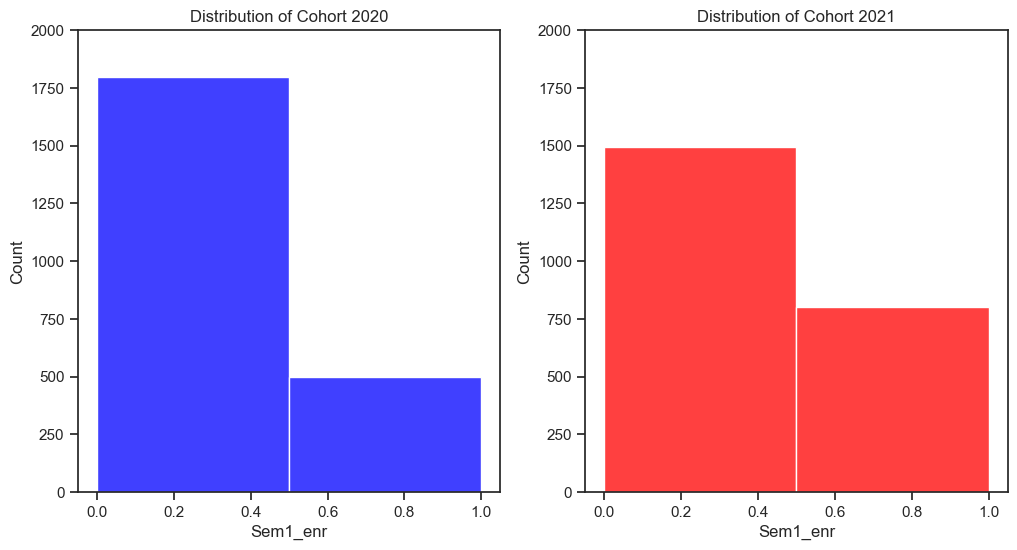

In [138]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df_cleaned['cohort_2020'], bins = 2, kde=False, color = 'blue', ax=ax[0])
ax[0].set_xlabel('Sem1_enr')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of Cohort 2020')
ax[0].set_ylim([0, 2000])

sns.histplot(df_cleaned['cohort_2021'], bins = 2, kde=False, color = 'red')
ax[1].set_xlabel('Sem1_enr')
ax[1].set_ylabel('Count')
ax[1].set_title('Distribution of Cohort 2021')
ax[1].set_ylim([0, 2000])

##### Obtain the Predicted Probabilities Using the Best Fit Logistic Regression Model with Tuned Hyperparameters, Lasso Regression...etc...etc...more here later!

### Attempt 1

In [139]:
import numpy as np

# Simulated sample size
n_simulations = 2766

# Define distributions
sim_lom = np.random.normal(df_cleaned['LOM (control matches)'].mean(), df_cleaned['LOM (control matches)'].std(), n_simulations)
sim_online_pair = np.random.normal(df_cleaned['online_pair_completion_sr_yr'].mean(), df_cleaned['online_pair_completion_sr_yr'].std(), n_simulations)
sim_pair_mtgs = np.random.poisson(df_cleaned['pair_mtgs_sr_yr'].mean(), n_simulations)

# the np.random.choice distribution chooses a random value from the given data and chooses this based on it's relative frequency of occurance within the dataset (which is why .value_counts(normaliz=Ture).values was implemented) 
sim_sel = np.random.choice(df_cleaned['SEL.GM_9'].unique(), n_simulations, p=df_cleaned['SEL.GM_9'].value_counts(normalize=True).values)

# the probability of being male is the mean, based on the mean  of the gender_Male column, 
# and the random binomial distribution chooses the probability of the gender being male based on the mean, 
# which is why the number 1 is passed in as the first parameter.
sim_gender = np.random.binomial(1, 
                                df_cleaned['gender_Male'].mean(), # represents the probability of being male
                                n_simulations)


sim_cohort_2020 = np.random.binomial(1, df_cleaned['cohort_2020'].mean(), n_simulations)
sim_cohort_2021 = np.random.binomial(1, df_cleaned['cohort_2021'].mean(), n_simulations)

# the probability of being in the Rydell High School is set to 1.0, based on the mean of the school_Rydell High School column
sim_school = np.random.binomial(1, df_cleaned['school_Rydell High School'].mean(), n_simulations)


In [140]:
# Compute probability of enrollment
logit_coeffs = log_reg_l1.coef_.flatten() # the estimated coefficeints for each predictor variable in the logistic regression model
logit_intercept = log_reg_l1.intercept_[0] # the estimated intercept for the logistic regression model
print(logit_coeffs[1:])
print(logit_intercept)

[ 0.27782897  0.21251676  0.30914027  0.10921943  0.38393117  0.38768766
 -0.46935865 -0.34260229]
-0.1368444799233194


In [141]:
def run_sim():
    try:
        sim_data = pd.DataFrame({
            'LOM (control matches)': sim_lom,
            'online_pair_completion_sr_yr': sim_online_pair,
            'pair_mtgs_sr_yr': sim_pair_mtgs,
            'SEL.GM_9': sim_sel,
            'cohort_2020': sim_cohort_2020,
            'cohort_2021': sim_cohort_2021,
            'school_Rydell High School': sim_school,
            'gender_Male': sim_gender
        })

        # Predict enrollment probability using logistic function
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))

        sim_data['enrollment_prob'] = sigmoid(np.dot(sim_data, logit_coeffs[1:]))

        # Simulate final enrollment decision (1 = enroll, 0 = not enroll)
        sim_data['sem1_enr'] = np.random.binomial(1, sim_data['enrollment_prob'])

        # Analyze results
        # Calculate and return the expected enrollment rate
        expected_enrollment_rate = sim_data['sem1_enr'].mean()
        return expected_enrollment_rate
    except Exception as e:
        print(f"Error in run_sim: {e}")
    return None

run_sim()

0.5672451193058569

Now changing some of the values for the simulation to run

In [142]:
# sim_lom = np.random.normal(df_cleaned['LOM (control matches)'].mean(), df_cleaned['LOM (control matches)'].std())
# sim_lom # generates 1 numeric value for LOM (control matches) based on the mean and standard deviation of the Normally distributed variable.

In [143]:
run_sim()

0.5585683297180043

Changing the LOM (control matches)

In [144]:
sim_lom = np.random.normal(df_cleaned['LOM (control matches)'].mean(), df_cleaned['LOM (control matches)'].std())
sim_lom # generates 1 numeric value for LOM (control matches) based on the mean and standard deviation of the Normally distributed variable.

-0.21251638505807605

In [145]:
sim_lom = .5
num_simulations = 2766
simulation_results = []
for sim in range(num_simulations):
    simulation_results.append(run_sim())

np.array(simulation_results).mean()

0.6084879716462006

In [146]:
sim_lom = np.random.normal(df_cleaned['LOM (control matches)'].mean(), df_cleaned['LOM (control matches)'].std())
sim_lom # generates 1 numeric value for LOM (control matches) based on the mean and standard deviation of the Normally distributed variable.

1.8623179763940234

In [147]:
sim_lom = 1
num_simulations = 2766
simulation_results = []
for sim in range(num_simulations):
    simulation_results.append(run_sim())

np.array(simulation_results).mean()

0.6399466928497001

In [148]:
sim_lom = 0
num_simulations = 2766
simulation_results = []
for sim in range(num_simulations):
    simulation_results.append(run_sim())

np.array(simulation_results).mean()

0.5764549281142936

In [149]:
sim_lom = np.random.normal(df_cleaned['LOM (control matches)'].mean(), df_cleaned['LOM (control matches)'].std())
sim_lom # generates 1 numeric value for LOM (control matches) based on the mean and standard deviation of the Normally distributed variable.

-1.1743150289646804

In [150]:
simulation_results

[0.5795372378886479,
 0.5806218365871294,
 0.5860448300795372,
 0.5976138828633406,
 0.5647143890093999,
 0.5835140997830802,
 0.5824295010845987,
 0.576644974692697,
 0.5820679681851049,
 0.5589298626174982,
 0.5607375271149675,
 0.5773680404916848,
 0.56941431670282,
 0.5802603036876356,
 0.574475777295734,
 0.5679681851048446,
 0.5878524945770065,
 0.5845986984815619,
 0.5712219812002892,
 0.5777295733911786,
 0.5947216196673897,
 0.5708604483007954,
 0.5730296456977585,
 0.5918293564714389,
 0.588937093275488,
 0.56941431670282,
 0.5853217642805495,
 0.5679681851048446,
 0.5795372378886479,
 0.5704989154013015,
 0.5697758496023138,
 0.5621836587129428,
 0.5939985538684021,
 0.5708604483007954,
 0.576644974692697,
 0.5780911062906724,
 0.5896601590744758,
 0.5806218365871294,
 0.5798987707881417,
 0.581706435285611,
 0.5838756326825741,
 0.5668835864063629,
 0.5647143890093999,
 0.5809833694866233,
 0.5762834417932032,
 0.5730296456977585,
 0.5683297180043384,
 0.5647143890093999,
 

Changing the online_pair_completion_sr_yr variable.

In [151]:
sim_online_pair = 1
sims = 2766
simulation_results = []

for sim in range(sims):
    simulation_results.append(run_sim())

np.array(simulation_results).mean()

0.5500619808029429

In [152]:
sim_online_pair = 0
sims = 2766
simulation_results = []

for sim in range(sims):
    simulation_results.append(run_sim())

np.array(simulation_results).mean()

0.49853138696358895

In [153]:
sim_online_pair = np.random.normal(df_cleaned['online_pair_completion_sr_yr'].mean(), df_cleaned['online_pair_completion_sr_yr'].std())
sim_online_pair


-0.2461042061219889

In [154]:
sim_school = np.random.binomial(1, df_cleaned['school_Rydell High School'].mean(), n_simulations)
sim_school.mean()

0.05350686912509038

In [155]:
sim_school = 0
sims = 2766
simulation_results = []

for sim in range(sims):
    simulation_results.append(run_sim())

np.array(simulation_results).mean()

0.49148384813213225

In [156]:
sim_school = 1
sims = 2766
simulation_results = []

for sim in range(sims):
    simulation_results.append(run_sim())

np.array(simulation_results).mean()

0.37887994336768804

Simulate Average Enrollment Rates

In [157]:
import numpy as np

# Number of simulations
n_simulations = 1000

# Number of students in each simulation (sample size)
n_students = len(df_features_engineered_non_standardized)

# Probability of enrollment (mean enrollment rate)
p_enrollment = df_features_engineered_non_standardized['sem1_enr'].mean()

# Simulate enrollment outcomes for each simulation
simulated_enrollments = np.random.binomial(n=1, p=p_enrollment, size=(n_simulations, n_students))

# Calculate the average enrollment rate for each simulation
average_enrollment_rates = simulated_enrollments.mean(axis=1)

# Print the first 10 average enrollment rates as a sample
print(average_enrollment_rates[:10])

[0.64372822 0.63501742 0.62761324 0.62369338 0.625      0.65505226
 0.63458188 0.63632404 0.65374564 0.63719512]


In [158]:
import numpy as np

# Number of simulations
n_simulations = 1000

# Number of students in each simulation (sample size)
n_students = len(df_cleaned)

# Define distributions for each parameter
sim_lom = np.random.normal(df_cleaned['LOM (control matches)'].mean(), df_cleaned['LOM (control matches)'].std(), (n_simulations, n_students))
sim_online_pair = np.random.normal(df_cleaned['online_pair_completion_sr_yr'].mean(), df_cleaned['online_pair_completion_sr_yr'].std(), (n_simulations, n_students))
sim_pair_mtgs = np.random.poisson(df_cleaned['pair_mtgs_sr_yr'].mean(), (n_simulations, n_students))
sim_sel = np.random.choice(df_cleaned['SEL.GM_9'].unique(), (n_simulations, n_students), p=df_cleaned['SEL.GM_9'].value_counts(normalize=True).values)
sim_gender = np.random.binomial(1, df_cleaned['gender_Male'].mean(), (n_simulations, n_students))
sim_cohort_2020 = np.random.binomial(1, df_cleaned['cohort_2020'].mean(), (n_simulations, n_students))
sim_cohort_2021 = np.random.binomial(1, df_cleaned['cohort_2021'].mean(), (n_simulations, n_students))
sim_school = np.random.binomial(1, df_cleaned['school_Rydell High School'].mean(), (n_simulations, n_students))

# Combine all simulated parameters into a single array
simulated_data = np.stack([sim_lom, sim_online_pair, sim_pair_mtgs, sim_sel, sim_gender, sim_cohort_2020, sim_cohort_2021, sim_school], axis=2)

# Add a constant term (intercept) to the simulated data
simulated_data = np.concatenate([np.ones((n_simulations, n_students, 1)), simulated_data], axis=2)

# Predict enrollment outcomes for each simulation
simulated_enrollments = log_reg_l1.predict_proba(simulated_data.reshape(-1, simulated_data.shape[2]))[:, 1].reshape(n_simulations, n_students)

# Calculate the average enrollment rate for each simulation
average_enrollment_rates = simulated_enrollments.mean(axis=1)

# Print the first 10 average enrollment rates as a sample
print(average_enrollment_rates[:10])

[0.52358981 0.52943539 0.52692321 0.53015191 0.52543508 0.52712821
 0.52521141 0.53097056 0.52365124 0.52517907]


In [159]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def simulate_enrollment(n_simulations, n_students, lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob):
    # Define distributions for each parameter
    sim_lom = np.random.normal(lom_mean, lom_std, (n_simulations, n_students))
    sim_online_pair = np.random.normal(online_pair_mean, online_pair_std, (n_simulations, n_students))
    sim_pair_mtgs = np.random.poisson(pair_mtgs_mean, (n_simulations, n_students))
    sim_sel = np.random.choice(df_cleaned['SEL.GM_9'].unique(), (n_simulations, n_students), p=sel_probs)
    sim_gender = np.random.binomial(1, gender_prob, (n_simulations, n_students))
    sim_cohort_2020 = np.random.binomial(1, cohort_2020_prob, (n_simulations, n_students))
    sim_cohort_2021 = np.random.binomial(1, cohort_2021_prob, (n_simulations, n_students))
    sim_school = np.random.binomial(1, school_prob, (n_simulations, n_students))

    # Combine all simulated parameters into a single array
    simulated_data = np.stack([sim_lom, sim_online_pair, sim_pair_mtgs, sim_sel, sim_gender, sim_cohort_2020, sim_cohort_2021, sim_school], axis=2)

    # Add a constant term (intercept) to the simulated data
    simulated_data = np.concatenate([np.ones((n_simulations, n_students, 1)), simulated_data], axis=2)

    # Predict enrollment outcomes for each simulation
    simulated_enrollments = log_reg_l1.predict_proba(simulated_data.reshape(-1, simulated_data.shape[2]))[:, 1].reshape(n_simulations, n_students)

    # Calculate the average enrollment rate for each simulation
    average_enrollment_rates = simulated_enrollments.mean(axis=1)

    return average_enrollment_rates

# Number of simulations
n_simulations = 1000

# Number of students in each simulation (sample size)
n_students = len(df_cleaned)

# Original parameter values
lom_mean = df_cleaned['LOM (control matches)'].mean()
lom_std = df_cleaned['LOM (control matches)'].std()
online_pair_mean = df_cleaned['online_pair_completion_sr_yr'].mean()
online_pair_std = df_cleaned['online_pair_completion_sr_yr'].std()
pair_mtgs_mean = df_cleaned['pair_mtgs_sr_yr'].mean()
sel_probs = df_cleaned['SEL.GM_9'].value_counts(normalize=True).values
gender_prob = df_cleaned['gender_Male'].mean()
cohort_2020_prob = df_cleaned['cohort_2020'].mean()
cohort_2021_prob = df_cleaned['cohort_2021'].mean()
school_prob = df_cleaned['school_Rydell High School'].mean()

# Simulate with original values
original_enrollment_rates = simulate_enrollment(n_simulations, n_students, lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Original average enrollment rates (first 10):", original_enrollment_rates[:10])

# Adjust one parameter (e.g., increase lom_mean by 10%)
adjusted_lom_mean = lom_mean * 1.10
adjusted_enrollment_rates = simulate_enrollment(n_simulations, n_students, adjusted_lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Adjusted average enrollment rates (first 10):", adjusted_enrollment_rates[:10])

Original average enrollment rates (first 10): [0.52278701 0.52647733 0.52228731 0.52279629 0.52136859 0.52338227
 0.52922473 0.52493957 0.53003649 0.52886806]
Adjusted average enrollment rates (first 10): [0.5264521  0.52760422 0.52933879 0.52718525 0.5265113  0.52997222
 0.52831077 0.52899468 0.52425372 0.52384658]


In [160]:
# Simulate with original values
original_enrollment_rates = simulate_enrollment(n_simulations, n_students, lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Original average enrollment rates (first 10):", original_enrollment_rates[:10])

# Adjust one parameter (e.g., increase lom_mean by 80%)
adjusted_lom_mean = lom_mean * 1.80
adjusted_enrollment_rates = simulate_enrollment(n_simulations, n_students, adjusted_lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Adjusted average enrollment rates (first 10):", adjusted_enrollment_rates[:10])

Original average enrollment rates (first 10): [0.52716464 0.5274407  0.52818573 0.52266484 0.52406832 0.52575936
 0.52847835 0.53058318 0.52381705 0.52750671]
Adjusted average enrollment rates (first 10): [0.5260197  0.52743526 0.52701179 0.53100322 0.52481735 0.52715862
 0.52729221 0.52453556 0.52634523 0.52971095]


In [161]:
# Number of simulations
n_simulations = 1000

# Number of students in each simulation (sample size)
n_students = len(df_cleaned)

# Original parameter values
lom_mean = df_cleaned['LOM (control matches)'].mean()
lom_std = df_cleaned['LOM (control matches)'].std()
online_pair_mean = df_cleaned['online_pair_completion_sr_yr'].mean()
online_pair_std = df_cleaned['online_pair_completion_sr_yr'].std()
pair_mtgs_mean = df_cleaned['pair_mtgs_sr_yr'].mean()
sel_probs = df_cleaned['SEL.GM_9'].value_counts(normalize=True).values
gender_prob = df_cleaned['gender_Male'].mean()
cohort_2020_prob = df_cleaned['cohort_2020'].mean()
cohort_2021_prob = df_cleaned['cohort_2021'].mean()
school_prob = df_cleaned['school_Rydell High School'].mean()

# Simulate with original values
original_enrollment_rates = simulate_enrollment(n_simulations, n_students, lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Original average enrollment rates (first 10):", original_enrollment_rates[:10])

# Adjust one parameter (e.g., increase lom_mean by 80%)
adjusted_online_pair_completion = online_pair_mean * 1.80
adjusted_enrollment_rates = simulate_enrollment(n_simulations, n_students, lom_mean, lom_std, adjusted_online_pair_completion, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Adjusted average enrollment rates (first 10):", adjusted_enrollment_rates[:10])


Original average enrollment rates (first 10): [0.52642244 0.52380767 0.5271931  0.52981211 0.52539588 0.52217401
 0.52384842 0.52708738 0.52543872 0.5249412 ]
Adjusted average enrollment rates (first 10): [0.52480924 0.52278334 0.52609521 0.52737005 0.53011021 0.52943208
 0.52574265 0.52161013 0.52758176 0.52659479]


In [162]:
# Number of simulations
n_simulations = 1000

# Number of students in each simulation (sample size)
n_students = len(df_cleaned)

# Original parameter values
lom_mean = df_cleaned['LOM (control matches)'].mean()
lom_std = df_cleaned['LOM (control matches)'].std()
online_pair_mean = df_cleaned['online_pair_completion_sr_yr'].mean()
online_pair_std = df_cleaned['online_pair_completion_sr_yr'].std()
pair_mtgs_mean = df_cleaned['pair_mtgs_sr_yr'].mean()
sel_probs = df_cleaned['SEL.GM_9'].value_counts(normalize=True).values
gender_prob = df_cleaned['gender_Male'].mean()
cohort_2020_prob = df_cleaned['cohort_2020'].mean()
cohort_2021_prob = df_cleaned['cohort_2021'].mean()
school_prob = df_cleaned['school_Rydell High School'].mean()

# Simulate with original values
original_enrollment_rates = simulate_enrollment(n_simulations, n_students, lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Original average enrollment rates (first 10):", original_enrollment_rates[:10])

# Adjust one parameter (e.g., increase lom_mean by 10%)
adjusted_lom_mean = lom_mean * 1.10
adjusted_enrollment_rates = simulate_enrollment(n_simulations, n_students, adjusted_lom_mean, lom_std, online_pair_mean, online_pair_std, pair_mtgs_mean, sel_probs, gender_prob, cohort_2020_prob, cohort_2021_prob, school_prob)
print("Adjusted average enrollment rates (first 10):", adjusted_enrollment_rates[:10])

Original average enrollment rates (first 10): [0.5231156  0.52823599 0.52579356 0.5285469  0.52320016 0.52438787
 0.52656835 0.52479704 0.52627921 0.5276893 ]
Adjusted average enrollment rates (first 10): [0.52701648 0.52876658 0.52722258 0.52891631 0.52765544 0.53116401
 0.52515926 0.52064596 0.52643378 0.52474999]


### Attempt 2

In [163]:
# only the manually created list of significant features.
selected_features = ['LOM (control matches)', 'online_pair_completion_sr_yr', 'pair_mtgs_sr_yr', 'SEL.GM_9', 'cohort_2020', 'cohort_2021', 'school_Rydell High School', 'gender_Male']

# df_cleaned is the cleaned, encoded, and standardized DataFrame and 'sem1_enr' is the binary response variable
X = df_cleaned[selected_features]
X = sm.add_constant(X)  # Add constant term
y = df_cleaned['sem1_enr']

# Initialize StratifiedKFold with 5 folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

# Lists to store evaluation metrics for each fold
accuracy_scores = []
conf_matrices = []
class_reports = []

# store all the probabilities
y_pred_prob_all = []

# Iterate through each fold
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit logistic regression model with L1 regularization (Lasso)
    log_reg_l1 = LogisticRegression(class_weight = 'balanced', C=0.05, solver='liblinear')
    log_reg_l1.fit(X_train, y_train)

    # Get non-zero coefficients (important features)
    selected_features = X_train.columns[log_reg_l1.coef_[0] != 0]
    
    # Make predictions
    y_pred_prob = log_reg_l1.predict_proba(X_test)[:, 1]
    y_pred_prob_all.extend(y_pred_prob)

In [164]:
import numpy as np
print(f'Total Predictions: {len(y_pred_prob_all)}')
print(f'mean: {np.mean(y_pred_prob_all)}')
print(f'Standard Deviation: {np.std(y_pred_prob_all)}')

Total Predictions: 2296
mean: 0.5158218276474926
Standard Deviation: 0.15144243800841573


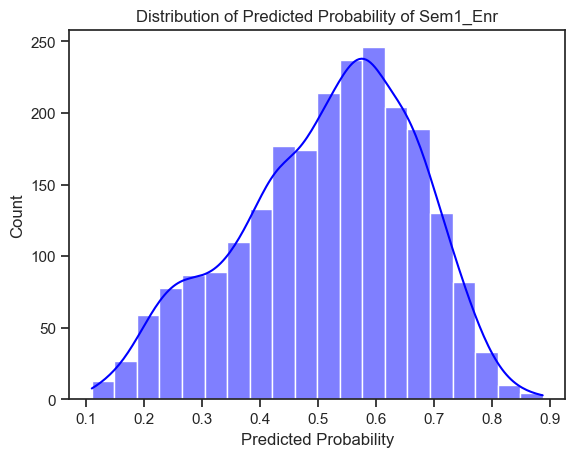

In [165]:
sns.histplot(y_pred_prob_all, bins=20, kde=True, color='blue')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribution of Predicted Probability of Sem1_Enr')
plt.show()

In [166]:
import numpy as np
from scipy.stats import skew, kurtosis

# Convert y_pred_prob_all to a numpy array
y_pred_prob_all_np = np.array(y_pred_prob_all)

# Calculate skewness and kurtosis
skewness = skew(y_pred_prob_all_np)
kurt = kurtosis(y_pred_prob_all_np)

print(f'Skewness: {skewness}')
print(f'Kurtosis: {kurt}')

Skewness: -0.3793853922060478
Kurtosis: -0.520053701920796


So the predicted probabilities are a normal distribution, which will be used for the simulation.

Input Parameters & Random Number Generation

In [167]:
num_simulations = 10000
mean = np.mean(y_pred_prob_all)
standard_deviation = np.std(y_pred_prob_all)

In [168]:
np.random.seed(100)
simulated_Sem1_enr_outputs = np.random.normal(mean, standard_deviation, num_simulations)
print(simulated_Sem1_enr_outputs)

[0.25083308 0.56771818 0.69044038 ... 0.447824   0.62678779 0.48399151]


In [169]:
print(f"Mean:\t {np.mean(simulated_Sem1_enr_outputs)}")
print(f"Std dev: {np.std(simulated_Sem1_enr_outputs)}")
print(f"Min:\t {np.min(simulated_Sem1_enr_outputs)}")
print(f"Max:\t {np.max(simulated_Sem1_enr_outputs)}")

Mean:	 0.5159961295389567
Std dev: 0.15239597329965154
Min:	 0.016049609913802533
Max:	 1.100077617490155


In [170]:
mean = np.mean(df_features_engineered_non_standardized['sem1_enr'])
standard_deviation = np.std(df_features_engineered_non_standardized['sem1_enr'])
np.random.seed(100)
simulated_Sem1_enr_outputs = np.random.normal(mean, standard_deviation, num_simulations)
print(simulated_Sem1_enr_outputs)
print(f"Mean:\t {np.mean(simulated_Sem1_enr_outputs)}")
print(f"Std dev: {np.std(simulated_Sem1_enr_outputs)}")
print(f"Min:\t {np.min(simulated_Sem1_enr_outputs)}")
print(f"Max:\t {np.max(simulated_Sem1_enr_outputs)}")

[-0.20017679  0.8043141   1.19332995 ...  0.42426274  0.99155824
  0.53890975]
Mean:	 0.6403608801724885
Std dev: 0.483078454681441
Min:	 -0.9444145367540715
Max:	 2.4918348823936927


In [171]:
mean_Sem1_enr = np.mean(df_features_engineered_non_standardized['sem1_enr']) # Average On-Time Enrollment Rate
std_dev_Sem1_enr = np.std(df_features_engineered_non_standardized['sem1_enr']) # Standard Deviation of the On-Time Enrollment Rate
num_simulations = 10000

### Attempt 3

## External Model Validation

In [2]:
# make sure to have the most up-to-date version of the kaggle package
# !pip install --upgrade kaggle
# !pip install kagglehub

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE
from sklearn.utils.validation import validate_data
import pandas as pd
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [3]:
# Download latest version
path = kagglehub.dataset_download("charleyhuang1022/college-plan")
print("Path to dataset files:", path)

# Load the dataset
df_students = pd.read_csv(path + '/college.csv')
print(type(df_students))
df_students.head()


Path to dataset files: /Users/_Preston_/.cache/kagglehub/datasets/charleyhuang1022/college-plan/versions/1
<class 'pandas.core.frame.DataFrame'>


,StudentID,Gender,Parent_income,IQ,Encourage,Plan
0,4558,male,53900,118,encourage,plan
1,4561,female,24900,87,not encourage,not plan
2,4563,female,65800,93,not encourage,not plan
3,4565,male,11440,117,encourage,plan
4,4567,female,16700,102,not encourage,not plan


## Run the External Validation Dataset through the Model

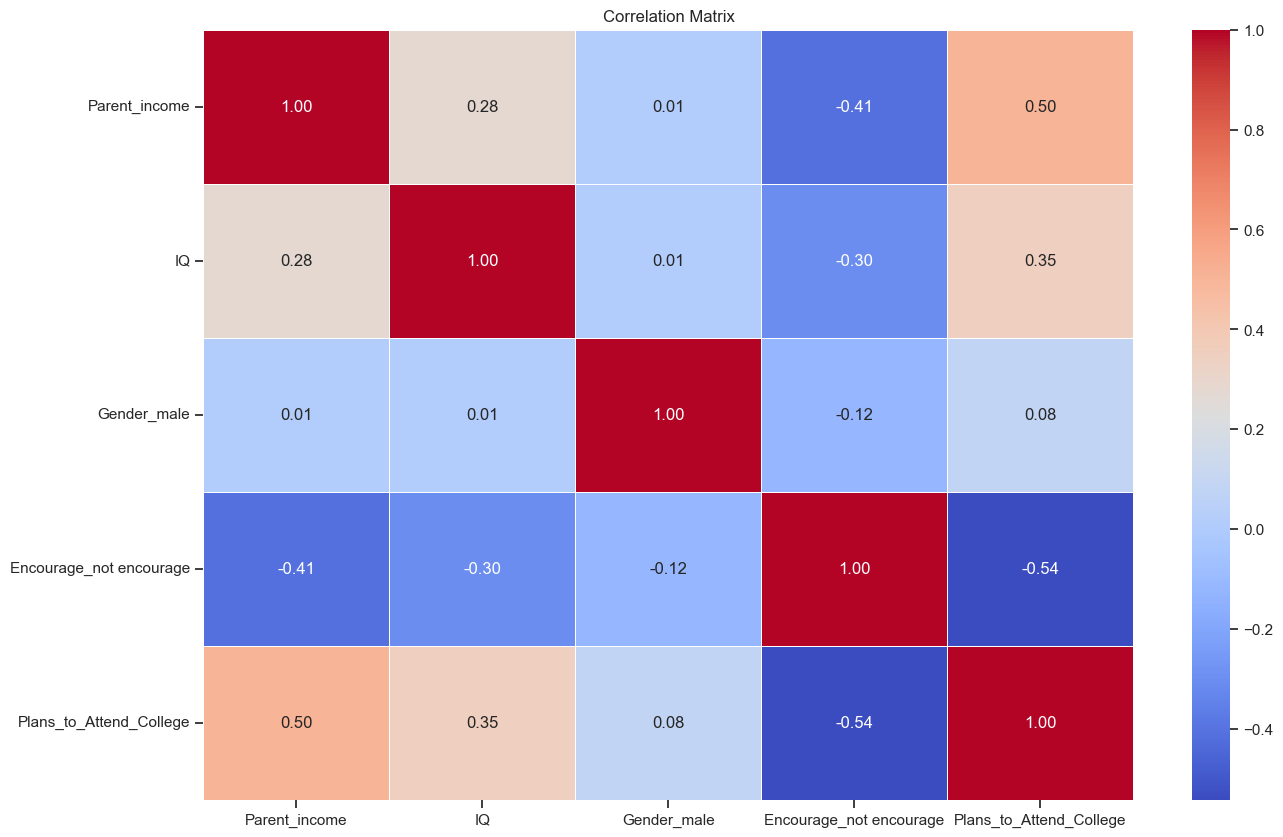

In [369]:
# Define the label column
label = 'Plans_to_Attend_College'
label

# One-hot encode categorical variables
# this gets dummy variables for the categorical columns, and drops the first column to prevent multicollinearity.
df_encoded = pd.get_dummies(df_students, columns=df_students.select_dtypes(include=['object']).columns, drop_first=True, dtype=int)
df_encoded.rename(columns={'Plan_plan': 'Plans_to_Attend_College'}, inplace=True)
df_encoded.drop(columns=['StudentID'], inplace=True)
df_encoded.head()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the correlation matrix - check to see if there is multicollinearity.
corr_matrix = df_encoded.corr()
corr_matrix

# Create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [370]:
# Initialize the scaler
scaler = StandardScaler()

# Exclude the label column from standardization
label = "Plans_to_Attend_College"
numerical_features = df_encoded.drop(columns=[label])

# Standardize only numerical features
standardized_features = pd.DataFrame(scaler.fit_transform(numerical_features), columns=numerical_features.columns)

# Add the label column back to the DataFrame
df_encoded = pd.concat([standardized_features, df_encoded[label]], axis=1)

df_encoded.head()

,Parent_income,IQ,Gender_male,Encourage_not encourage,Plans_to_Attend_College
0,0.738530,0.973565,1.032012,-0.966801,1
1,-0.869866,-0.664699,-0.968981,1.034339,0
2,1.398528,-0.347616,-0.968981,1.034339,0
3,-1.616384,0.920717,1.032012,-0.966801,1
4,-1.324654,0.128009,-0.968981,1.034339,0


In [371]:

# Calculate the VIF for each feature and remove if above 5.0
def calculate_vif(df, label):
    df_vif = pd.DataFrame(columns=['VIF'])
    for col in df.drop(columns=[label]):
        y = df[col]
        X = df.drop(columns=[col, label]).assign(const=1)
        r_squared = sm.OLS(y, X).fit().rsquared
        if r_squared < 1:
            df_vif.loc[col] = [1 / (1 - r_squared)]
        else:
            df_vif.loc[col] = [float('inf')]
    return df_vif

def iterative_vif_removal(df, label, threshold=5):
    while True:
        df_vif = calculate_vif(df, label)
        df_vif.sort_values(by=['VIF'], ascending=False, inplace=True)
        max_vif = df_vif.iloc[0]
        if max_vif['VIF'] > threshold:
            feature_to_remove = df_vif.index[0]
            print(f"Removing feature '{feature_to_remove}' with VIF = {max_vif['VIF']}")
            df = df.drop(columns=[feature_to_remove])
        else:
            break
    return df, df_vif


# Use the iterative process on your dataset
df_cleaned, final_vif = iterative_vif_removal(df_encoded, label, threshold=5)

# Display the final VIF scores
final_vif



,VIF
Encourage_not encourage,1.278649
Parent_income,1.243308
IQ,1.137260
Gender_male,1.016196


In [372]:
df_cleaned.head()

,Parent_income,IQ,Gender_male,Encourage_not encourage,Plans_to_Attend_College
0,0.738530,0.973565,1.032012,-0.966801,1
1,-0.869866,-0.664699,-0.968981,1.034339,0
2,1.398528,-0.347616,-0.968981,1.034339,0
3,-1.616384,0.920717,1.032012,-0.966801,1
4,-1.324654,0.128009,-0.968981,1.034339,0


Accuracy: 79.91%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      5404
           1       0.65      0.84      0.73      2596

    accuracy                           0.80      8000
   macro avg       0.78      0.81      0.79      8000
weighted avg       0.83      0.80      0.80      8000



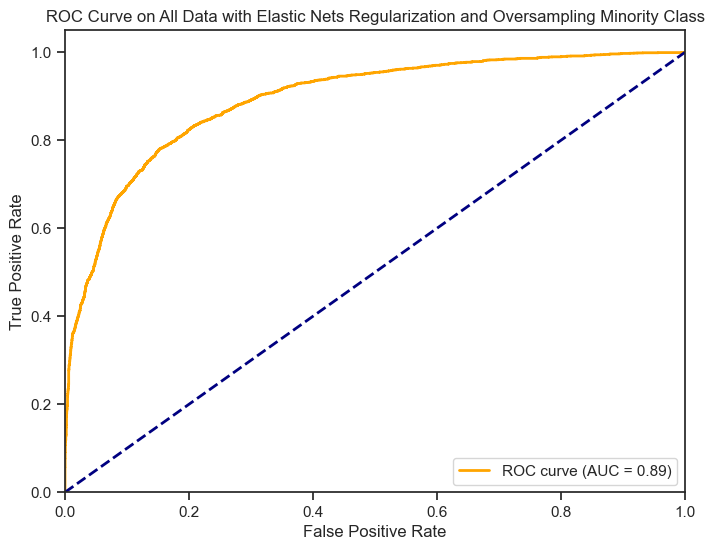

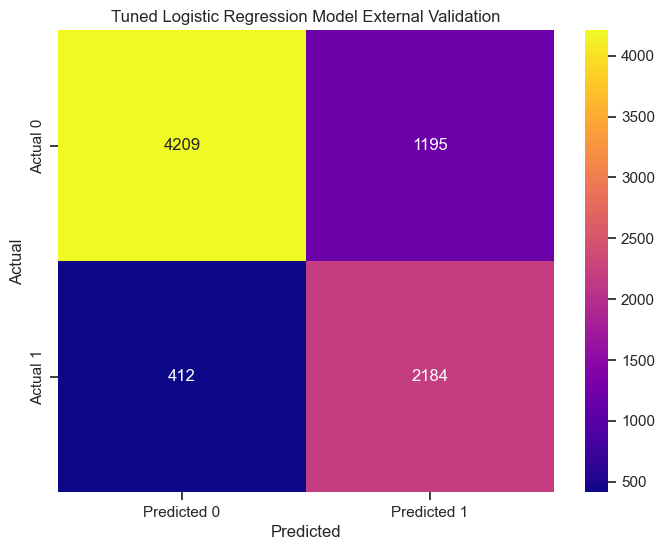

In [373]:

# Assuming df_cleaned is already defined and preprocessed
X = df_cleaned.drop(columns=label)
X = sm.add_constant(X)  # Add constant term
y = df_cleaned[label]

# Initialize SMOTE
smote = SMOTE(random_state=21)
    
# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X, y)

# Fit logistic regression model with the best parameters
log_reg_en_best = LogisticRegression(penalty='elasticnet', C= 0.1, l1_ratio = 0.25, solver='saga')
log_reg_en_best.fit(X_resampled, y_resampled)

# Make predictions
y_pred_prob = log_reg_en_best.predict_proba(X)[:, 1]
y_pred = np.where(y_pred_prob >= 0.5, 1, 0)  # Convert probabilities to binary predictions

# Create confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

# Print overall accuracy
accuracy = accuracy_score(y, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Print classification report for additional metrics
class_report = classification_report(y, y_pred)
print("\nClassification Report:")
print(class_report)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on All Data with Elastic Nets Regularization and Oversampling Minority Class')
plt.legend(loc='lower right')
plt.show()

# Visualize the confusion matrix of the last fold
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap = 'plasma', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
sns.color_palette("coolwarm", as_cmap=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Logistic Regression Model External Validation')
plt.show()

Accuracy: 79.91%
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      5404
           1       0.81      0.71      0.76      2596

    accuracy                           0.85      8000
   macro avg       0.84      0.82      0.83      8000
weighted avg       0.85      0.85      0.85      8000



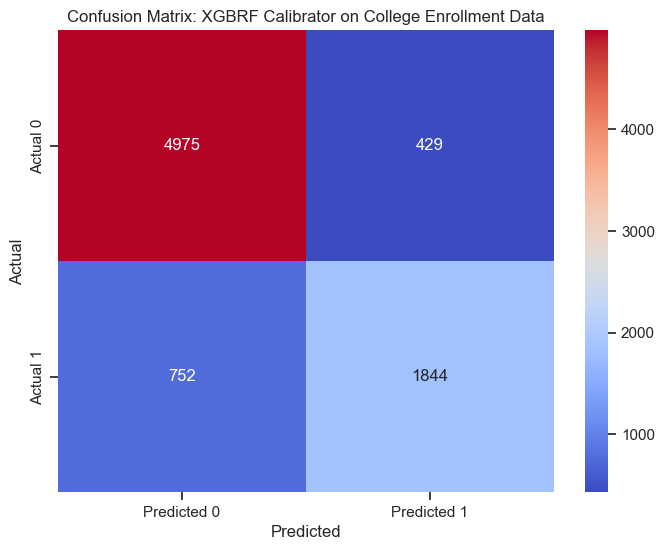

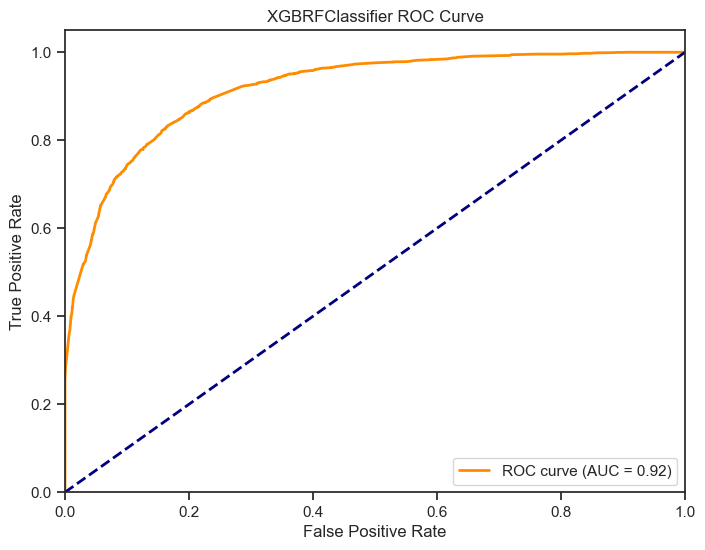

In [377]:
#  df_cleaned is already defined and preprocessed - it's ready to be used to train the entire model to see how this works with external validation.
X = df_cleaned.drop(columns=label)
y = df_cleaned[label]

# Instantiate XGBRFClassifier & fit the model
XGBRF_model = XGBRFClassifier(objective='binary:logistic', random_state=42)
XGBRF_model.fit(X, y)

# Calibrate the model using isotonic calibration and the same parameters as before in the calibrated XGBRFClassifier model.
from sklearn.calibration import CalibratedClassifierCV
calibrator = CalibratedClassifierCV(XGBRF_model, method = 'isotonic', cv = 3)
calibrator.fit(X, y)

# predict y
y_pred = calibrator.predict(X)

# Create confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

#accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Create confusion matrix
conf_matrix = confusion_matrix(y, y_pred)
# print("Confusion Matrix:")
# print(conf_matrix)

# Print classification report for additional metrics
class_report = classification_report(y, y_pred)
print("Classification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: XGBRF Calibrator on College Enrollment Data')
plt.show()

# Get the predicted probabilities for the positive class
y_pred_prob = calibrator.predict_proba(X)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBRFClassifier ROC Curve')
plt.legend(loc='lower right')
plt.show()
